# Membership Churn Analysis

## Notebook 09: Visualisation Portfolio & Dashboard Exports

---

**Author:** D. 
**Date:** March 27, 2026 
**Dataset:** churn_t_db.csv (2.1GB, 18.4M rows)

---

### Dependencies

In [0]:
%restart_python

In [0]:
# ═══════════════════════════════════════════════════════════════
# Dependencies
# ═══════════════════════════════════════════════════════════════

import sys
import os
import warnings
warnings.filterwarnings("ignore")
from datetime import datetime

# ── Spark ──────────────────────────────────────────────────────
from pyspark.sql import functions as F
from pyspark.sql.types import (
    StructType, StringType, IntegerType, LongType,
    DoubleType, DateType, FloatType, BooleanType
)

# ── Pandas / NumPy ─────────────────────────────────────────────
import numpy as np
import pandas as pd

# ── Visualisation ──────────────────────────────────────────────
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.dates as mdates
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

import plotly
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

print("Dependencies loaded successfully.")

Dependencies loaded successfully.


%md
## 1.0 Setup & Configuration
Initialise environment, load and verify Silver layer and all 12 Gold layer tables, configure the IBM accessible colour palette, Matplotlib and Plotly templates, and define project constants for all downstream figure production.

### 1.1 Environment Verification

In [0]:
# ═══════════════════════════════════════════════════════════════
# 1.1 Environment Verification
# ═══════════════════════════════════════════════════════════════

# ── Library versions ───────────────────────────────────────────
print(f"Spark      : {spark.version}")
print(f"Python     : {sys.version.split()[0]}")
print(f"Pandas     : {pd.__version__}")
print(f"NumPy      : {np.__version__}")
print(f"Matplotlib : {matplotlib.__version__}")
print(f"Plotly     : {plotly.__version__}")
print(f"Timestamp  : {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

print("-" * 60)
print("Environment verification complete.")

Spark      : 4.1.0
Python     : 3.12.3
Pandas     : 2.2.3
NumPy      : 2.1.3
Matplotlib : 3.10.0
Plotly     : 5.24.1
Timestamp  : 2026-04-05 17:18:12
------------------------------------------------------------
Environment verification complete.


### 1.2 Data Loading

In [0]:
# ═══════════════════════════════════════════════════════════════
# 1.2 Data Loading
# ═══════════════════════════════════════════════════════════════

# ── Path ──────────────────────────────────────────────────────────
SILVER_PATH = "/Volumes/workspace/rcn_churn/silver/churn_cleaned/"
GOLD_PATH = "/Volumes/workspace/rcn_churn/gold/"


# ── Silver Load and confirm ───────────────────────────────────────
silver_churn = spark.read.format("delta").load(SILVER_PATH)
silver_rows = silver_churn.count()
silver_cols = len(silver_churn.columns)

print("-" * 70)
print(f"Silver layer loaded: {silver_rows:,} rows, {silver_cols} cols")
print("-" * 70)
print(f"Path: {SILVER_PATH}")
print(f"Chapter 4 figures source from Silver to match EDA context.")
print("\n" + "-" * 60)


# ── Gold Layer 12 required tables ───────────────────────────────
TABLE_NAMES = [
    "churn_rates",          "region_churn_clean",   "churn_risk_summary",
    "feature_engineered",   "hazard_ratios",        "forecast_outputs",
    "shap_importance",      "shap_segment_level",   "risk_segmentation",
    "revenue_at_risk",      "predicted_retention",   "monthly_churn_trends",
]

# ── Tables stored as Delta (NB06 writes) ───────────────────────
DELTA_TABLES = {"churn_rates", "region_churn_clean", "feature_engineered"}

# ── Gold Load and confirm ────────────────────────────────────────
gold = {}

print("Gold Layer Loading")
print("-" * 70)
print(f"{'#':<4} {'Table':<26} {'Rows':>12} {'Cols':>6}  {'Format':<8} Status")
print("-" * 70)

for i, name in enumerate(TABLE_NAMES, 1):
    path = GOLD_PATH + name + "/"
    try:
        if name in DELTA_TABLES:
            df = spark.read.format("delta").load(path)
            fmt = "Delta"
        else:
            df = spark.read.parquet(path)
            fmt = "Parquet"
        rows = df.count()
        cols = len(df.columns)
        gold[name] = df
        print(f"{i:<4} {name:<26} {rows:>12,} {cols:>6}  {fmt:<8} ✓")
    except Exception as e:
        print(f"{i:<4} {name:<26} {'—':>12} {'—':>6}  {'—':<8} ✗ {str(e)[:50]}")

print("-" * 60)
print(f"Loaded: {len(gold)}/{len(TABLE_NAMES)}")

# ── Flag any extras in Gold ────────────────────────────────────
all_gold = [f.name.rstrip("/") for f in dbutils.fs.ls(GOLD_PATH)]
extras = [t for t in all_gold if t not in TABLE_NAMES]
if extras:
    print(f"Additional Gold tables: {', '.join(extras)}")

if len(gold) == len(TABLE_NAMES):
    print("\n All 12 Gold tables loaded.")
else:
    print("\n❌ Missing tables — resolve before proceeding.")

----------------------------------------------------------------------
Silver layer loaded: 18,461,480 rows, 14 cols
----------------------------------------------------------------------
Path: /Volumes/workspace/rcn_churn/silver/churn_cleaned/
Chapter 4 figures source from Silver to match EDA context.

------------------------------------------------------------
Gold Layer Loading
----------------------------------------------------------------------
#    Table                              Rows   Cols  Format   Status
----------------------------------------------------------------------
1    churn_rates                  17,842,006     18  Delta    ✓
2    region_churn_clean                  754      7  Delta    ✓
3    churn_risk_summary                   31      8  Parquet  ✓
4    feature_engineered           17,648,606     27  Delta    ✓
5    hazard_ratios                         8     11  Parquet  ✓
6    forecast_outputs                     96      6  Parquet  ✓
7    shap_importance

### 1.3 Schema Validation

In [0]:
# ═══════════════════════════════════════════════════════════════
# 1.3 Schema Validation
# ═══════════════════════════════════════════════════════════════


# ── Silver schema check ────────────────────────────────────────
print("-" * 60)
print("Silver Schema Validation - Column Reference for Figure Cells")
print("-" * 60)
for f in silver_churn.schema.fields:
    print(f"  {f.name:<25} {str(f.dataType)}")
print("\n" + "-" * 60)

# ── Gold schema check ────────────────────────────────────────
print("Gold Schema Validation — Column Reference for Figure Cells")
print("-" * 60)

for name in TABLE_NAMES:
    df = gold[name]
    cols = df.columns
    dtypes = {f.name: str(f.dataType).replace("Type", "") for f in df.schema.fields}
    print(f"\n{name} ({len(cols)} cols):")
    for c in cols:
        print(f"  {c:<30} {dtypes[c]}")

print("\n" + "-" * 60)
print(" Schema reference complete.")

------------------------------------------------------------
Silver Schema Validation - Column Reference for Figure Cells
------------------------------------------------------------
  _c0                       IntegerType()
  CM_snapshot_date          DateType()
  Int_nurse                 StringType()
  Region                    StringType()
  MemCategory               StringType()
  CatName                   StringType()
  Branch                    StringType()
  YoB                       IntegerType()
  MemSectorType             StringType()
  YoJ                       IntegerType()
  q_members_t               DoubleType()
  q_leavers_t               DoubleType()
  cleaning_flag             StringType()
  geo_flag                  StringType()

------------------------------------------------------------
Gold Schema Validation — Column Reference for Figure Cells
------------------------------------------------------------

churn_rates (18 cols):
  _c0                            Int

### 1.4 Configuration & Constants

In [0]:
# ═══════════════════════════════════════════════════════════════
# 1.4 Configuration & Constants
# ═══════════════════════════════════════════════════════════════

# ── IBM Accessible Colour Palette (Category) ──────────────────
IBM_BLUE   = "#648FFF"    # Nurse member
IBM_ORANGE = "#FE6100"    # Nurse Support Worker
IBM_PINK   = "#DC267F"    # Student

# ── Risk Tier Palette (WCAG AA, colour-blind tested) ──────────
RISK_RED    = "#D32F2F"   # High
RISK_CYAN   = "#00838F"   # Medium
RISK_PURPLE = "#785EF0"   # Low

# ── Neutral / Annotation ──────────────────────────────────────
IBM_GREY   = "#999999"    # Surge shading, reference lines
IBM_BLACK  = "#333333"    # Text annotations, axis labels

# ── Category Colours ───────────────────────────────────────────
CATEGORY_COLOURS = {
    "Nurse member":         IBM_BLUE,
    "Nurse Support Worker": IBM_ORANGE,
    "Student":              IBM_PINK,
}

# ── Risk Tier Colours ──────────────────────────────────────────
RISK_COLOURS = {
    "High":   RISK_RED,
    "Medium": RISK_CYAN,
    "Low":    RISK_PURPLE,
}

# ── Category Order ─────────────────────────────────────────────
CATEGORY_ORDER = ["Nurse member", "Nurse Support Worker", "Student"]

# ── Matplotlib Defaults ────────────────────────────────────────
plt.rcParams.update({
    "figure.dpi":         150,
    "savefig.dpi":        300,
    "savefig.bbox":       "tight",
    "savefig.pad_inches": 0.15,
    "figure.figsize":     (10, 6),
    "figure.facecolor":   "white",
    "figure.edgecolor":   "white",
    "font.family":        "serif",
    "font.serif":         ["DejaVu Serif", "Times New Roman", "serif"],
    "font.size":          11,
    "axes.titlesize":     13,
    "axes.labelsize":     11,
    "xtick.labelsize":    10,
    "ytick.labelsize":    10,
    "legend.fontsize":    10,
    "axes.spines.top":    False,
    "axes.spines.right":  False,
    "axes.grid":          True,
    "axes.grid.axis":     "y",
    "grid.alpha":         0.3,
    "grid.linewidth":     0.5,
    "legend.frameon":     False,
})

# ── Plotly Template ────────────────────────────────────────────
plotly.io.templates["presentation"] = go.layout.Template(
    layout=go.Layout(
        font=dict(family="DejaVu Serif, Times New Roman, serif", size=12),
        title_font_size=14,
        plot_bgcolor="white",
        paper_bgcolor="white",
        xaxis=dict(showgrid=True, gridcolor="rgba(0,0,0,0.1)"),
        yaxis=dict(showgrid=True, gridcolor="rgba(0,0,0,0.1)"),
    )
)
plotly.io.templates.default = "presentation"

# ── Surge Period Boundaries ────────────────────────────────────
SURGE_START      = "2022-10-01"
SURGE_END        = "2023-06-01"
POST_SURGE_START = "2023-07-01"

# ── Excluded Snapshots (already removed in Gold) ───────────────
EXCLUDED_SNAPSHOTS = ["2022-04-01", "2025-12-01"]

# ── Regional Groupings ────────────────────────────────────────
HIGH_UPLIFT_REGIONS = [
    "Northern Ireland", "Yorkshire & The Humber",
    "Wales", "North West", "London",
]
NORTH_REGIONS = ["Northern", "North West", "Scotland"]
SOUTH_REGIONS = ["South East", "South West", "Eastern"]

# ── Annual Fees ────────────────────────────────────────────────
ANNUAL_FEES = {
    "Nurse member":         102.36,
    "Nurse Support Worker":  51.24,
    "Student":               10.08,
}

# ── Confirmed Figures (cited, not recomputed) ──────────────────
CONFIRMED = {
    "overall_churn_rate":      0.006614,
    "nurse_national_rate":     0.0051,
    "nsw_national_rate":       0.0102,
    "student_national_rate":   0.0180,
    "post_surge_nurse_uplift": 0.07,
    "ni_uplift":               0.26,
    "yorkshire_uplift":        0.21,
    "wales_uplift":            0.18,
    "nw_uplift":               0.13,
    "london_uplift":           0.11,
    "nurse_55_64_uplift":      0.2004,
    "student_jan_premium":     2.96,
    "nurse_jan_premium":       1.15,
    "nsw_jan_premium":         1.05,
    "north_nurse_mean":        0.00552,
    "south_nurse_mean":        0.00486,
    "north_south_ratio":       1.135,
    "spearman_r":              0.9879,
    "cox_c_index":             0.787,
    "nb_aic":                  427666,
    "poisson_aic":             635250,
    "poisson_dispersion":      4.89,
    "nb_dispersion":           2.33,
    "gbm_surrogate_r2":       0.687,
    "revenue_at_risk_base":    526285,
    "revenue_at_risk_15x":     789428,
}

print("Configuration loaded successfully.")
print("✓ Category palette: Blue / Orange / Pink")
print("✓ Risk tier palette: Red / Cyan / Purple (WCAG AA, colour-blind safe)")
print("✓ Surge shading: IBM Grey with transparency")
print("✓ Matplotlib: 300 DPI, serif, clean spines")
print("✓ Plotly: visualisation template active")
print(f"✓ {len(CONFIRMED)} confirmed annotation values loaded")

Configuration loaded successfully.
✓ Category palette: Blue / Orange / Pink
✓ Risk tier palette: Red / Cyan / Purple (WCAG AA, colour-blind safe)
✓ Surge shading: IBM Grey with transparency
✓ Matplotlib: 300 DPI, serif, clean spines
✓ Plotly: visualisation template active
✓ 26 confirmed annotation values loaded


### 1.5 Output Paths

In [0]:
# ═══════════════════════════════════════════════════════════════
# 1.5 Output Paths
# ═══════════════════════════════════════════════════════════════

FIG_DIR    = "/tmp/presentation_figures/"
TABLE_DIR  = "/tmp/presentation_figures/tables/"
EXPORT_DIR = GOLD_PATH + "exports_powerbi/"

# ── Create local directories ───────────────────────────────────
for d in [FIG_DIR, TABLE_DIR]:
    os.makedirs(d, exist_ok=True)

print(f"Presentation figures → {FIG_DIR}")
print(f"Table CSVs           → {TABLE_DIR}")
print(f"Power BI Parquet     → {EXPORT_DIR}")

Presentation figures → /tmp/presentation_figures/
Table CSVs           → /tmp/presentation_figures/tables/
Power BI Parquet     → /Volumes/workspace/rcn_churn/gold/exports_powerbi/


### 1.6 Reusable Utilities

In [0]:
# ═══════════════════════════════════════════════════════════════
# 1.6 Reusable Utilities
# ═══════════════════════════════════════════════════════════════

def save_fig(fig, filename, dpi=300):
    """Save figure to presentation output directory."""
    path = os.path.join(FIG_DIR, filename)
    fig.savefig(path, dpi=dpi, bbox_inches="tight", facecolor="white")
    size_kb = os.path.getsize(path) / 1024
    print(f"  ✓ {filename} ({size_kb:.0f} KB, {dpi} DPI)")
    plt.close(fig)
    return path


def add_surge_shading(ax, alpha=0.12, label="Surge period"):
    """Add grey vertical span for Oct 2022 – Jun 2023."""
    ax.axvspan(
        pd.Timestamp(SURGE_START), pd.Timestamp(SURGE_END),
        color=IBM_GREY, alpha=alpha, label=label, zorder=0
    )


def format_pct_axis(ax, axis="y", decimals=2):
    """Format axis as percentage (0.006 → 0.60%)."""
    formatter = mticker.FuncFormatter(
        lambda x, _: f"{x * 100:.{decimals}f}%"
    )
    if axis == "y":
        ax.yaxis.set_major_formatter(formatter)
    else:
        ax.xaxis.set_major_formatter(formatter)


def annotate_value(ax, x, y, text, fontsize=9, ha="center",
                   va="bottom", offset=(0, 5)):
    """Place a text annotation with offset in points."""
    ax.annotate(
        text, xy=(x, y), fontsize=fontsize, ha=ha, va=va,
        color=IBM_BLACK, xytext=offset, textcoords="offset points",
    )


def category_colour(cat):
    """Return IBM colour for a membership category."""
    return CATEGORY_COLOURS.get(cat, IBM_GREY)


def risk_colour(tier):
    """Return colour for a risk tier."""
    return RISK_COLOURS.get(tier, IBM_GREY)


print(" Utilities: save_fig, add_surge_shading, format_pct_axis,")
print("  annotate_value, category_colour, risk_colour")

 Utilities: save_fig, add_surge_shading, format_pct_axis,
  annotate_value, category_colour, risk_colour


## 2.0 Dashboard Data Validation
Verify baseline churn rate integrity and referential consistency across Gold layer tables before producing any figures or exports.

### 2.1 Baseline Churn Rate Verification

In [0]:
# ═══════════════════════════════════════════════════════════════
# 2.1 Baseline Churn Rate Verification
# ═══════════════════════════════════════════════════════════════

# ── Compute weighted churn rate from Gold layer ────────────────
baseline_agg = (
    gold["churn_rates"]
    .agg(
        F.sum("q_leavers_t").alias("total_leavers"),
        F.sum("q_members_t").alias("total_members"),
    )
    .collect()[0]
)

computed_rate = baseline_agg["total_leavers"] / baseline_agg["total_members"]
expected_rate = CONFIRMED["overall_churn_rate"]
diff_pct_pts = abs(computed_rate - expected_rate) * 100

# ── Compare against confirmed value ───────────────────────────
print("Baseline Churn Rate Verification")
print("-" * 60)
print(f"  Computed from Gold : {computed_rate:.6f}  ({computed_rate*100:.4f}%)")
print(f"  Confirmed value    : {expected_rate:.6f}  ({expected_rate*100:.4f}%)")
print(f"  Difference         : {diff_pct_pts:.6f} percentage points")
print("-" * 60)

if diff_pct_pts < 0.001:
    print("  Status: ✓ Pass — baseline confirmed. Safe to proceed.")
else:
    print("  Status: ❌ Fail — baseline has drifted. Do not produce figures.")

Baseline Churn Rate Verification
------------------------------------------------------------
  Computed from Gold : 0.006614  (0.6614%)
  Confirmed value    : 0.006614  (0.6614%)
  Difference         : 0.000005 percentage points
------------------------------------------------------------
  Status: ✓ Pass — baseline confirmed. Safe to proceed.


### 2.2 Referential Integrity Checks

In [0]:
# ═══════════════════════════════════════════════════════════════
# 2.2 Referential Integrity Checks
# ═══════════════════════════════════════════════════════════════

# ── Category values across tables ──────────────────────────────
cat_tables = ["churn_rates", "feature_engineered", "risk_segmentation", "revenue_at_risk"]
print("Category values by table")
print("-" * 60)

for name in cat_tables:
    cats = sorted(gold[name].select("MemCategory").distinct().toPandas()["MemCategory"].tolist())
    mapped = all(c in CATEGORY_COLOURS for c in cats)
    status = "all mapped" if mapped else "UNMAPPED VALUES"
    print(f"  {name:<26} {cats}  ({status})")

# ── Region values in key tables ────────────────────────────────
print()
print("High-uplift regions present in region_churn_clean")
print("-" * 60)

regions = gold["region_churn_clean"].select("Region").distinct().toPandas()["Region"].tolist()
for r in HIGH_UPLIFT_REGIONS:
    status = "found" if r in regions else "MISSING"
    print(f"  {r:<30} {status}")

# ── Date range consistency ─────────────────────────────────────
print()
print("Snapshot date ranges")
print("-" * 60)

date_tables = {
    "churn_rates":          "CM_snapshot_date",
    "feature_engineered":   "CM_snapshot_date",
    "region_churn_clean":   "CM_snapshot_date",
    "monthly_churn_trends": "snapshot_date",
}

for name, col in date_tables.items():
    rng = gold[name].agg(F.min(col), F.max(col)).collect()[0]
    print(f"  {name:<26} {rng[0]}  →  {rng[1]}")

# ── Risk tier coverage ─────────────────────────────────────────
print()
print("Risk tier values in risk_segmentation")
print("-" * 60)

tiers = sorted(gold["risk_segmentation"].select("risk_tier").distinct().toPandas()["risk_tier"].tolist())
mapped = all(t in RISK_COLOURS for t in tiers)
status = "all mapped" if mapped else "UNMAPPED VALUES"
print(f"  {tiers}  ({status})")

print("-" * 60)
print("Validation complete.")

Category values by table
------------------------------------------------------------
  churn_rates                ['Nurse Support Worker', 'Nurse member', 'Student']  (all mapped)
  feature_engineered         ['Nurse Support Worker', 'Nurse member', 'Student']  (all mapped)
  risk_segmentation          ['Nurse Support Worker', 'Nurse member', 'Student']  (all mapped)
  revenue_at_risk            ['Nurse Support Worker', 'Nurse member', 'Student']  (all mapped)

High-uplift regions present in region_churn_clean
------------------------------------------------------------
  Northern Ireland               found
  Yorkshire & The Humber         found
  Wales                          found
  North West                     found
  London                         found

Snapshot date ranges
------------------------------------------------------------
  churn_rates                2021-01-01  →  2025-11-01
  feature_engineered         2021-01-01  →  2025-11-01
  region_churn_clean         2021-

## 3.0 Chapter 4 Figures — Data Understanding & Exploratory Analysis
Three data-driven figures covering membership volume, cohort acquisition trajectories, and joiner counts with surge annotation.

### 3.1 Fig 4.2 | Chapter 4, Section 4.5

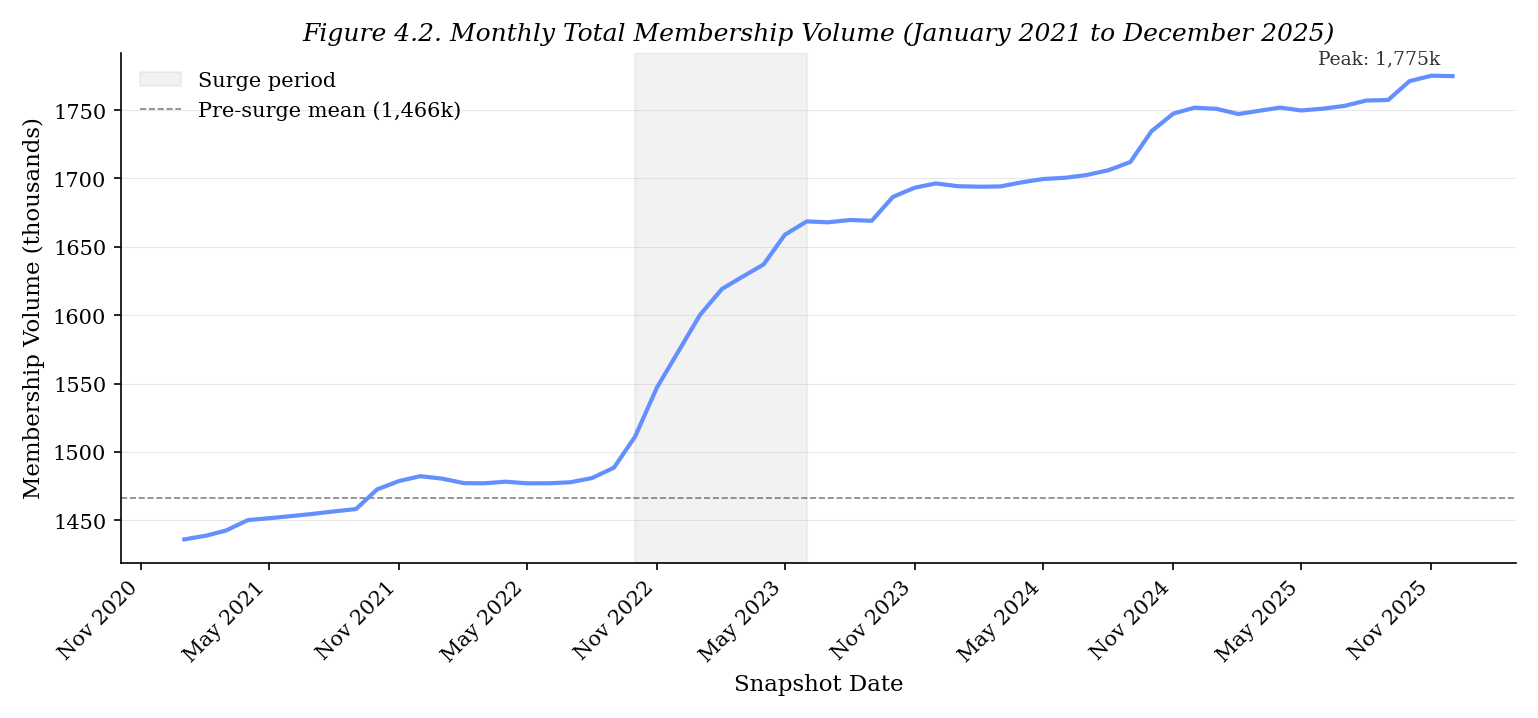

  ✓ Fig_4_2_monthly_member_volume.png (223 KB, 300 DPI)


'/tmp/presentation_figures/Fig_4_2_monthly_member_volume.png'

In [0]:
# ═══════════════════════════════════════════════════════════════
# 3.1 Fig 4.2 | Chapter 4, Section 4.5 | Source: silver_churn
# Monthly Total Membership Volume (January 2021 to December 2025)
# ═══════════════════════════════════════════════════════════════

# ── Aggregate total members by snapshot ────────────────────────
df_vol = (
    silver_churn
    .groupBy("CM_snapshot_date")
    .agg(F.sum("q_members_t").alias("total_members"))
    .orderBy("CM_snapshot_date")
    .toPandas()
)

df_vol["CM_snapshot_date"] = pd.to_datetime(df_vol["CM_snapshot_date"])
df_vol["members_k"] = df_vol["total_members"] / 1_000

# ── Pre-surge baseline ─────────────────────────────────────────
pre_surge = df_vol[df_vol["CM_snapshot_date"] < SURGE_START]
baseline_k = pre_surge["members_k"].mean()

# ── Peak identification ────────────────────────────────────────
peak_row = df_vol.loc[df_vol["members_k"].idxmax()]
peak_date = peak_row["CM_snapshot_date"]
peak_val = peak_row["members_k"]

# ── Plot ───────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(
    df_vol["CM_snapshot_date"], df_vol["members_k"],
    color=IBM_BLUE, linewidth=2, zorder=3
)

add_surge_shading(ax)

ax.axhline(
    baseline_k, color=IBM_BLACK, linestyle="--",
    linewidth=0.8, alpha=0.6, label=f"Pre-surge mean ({baseline_k:,.0f}k)"
)

annotate_value(
    ax, peak_date, peak_val,
    f"Peak: {peak_val:,.0f}k", fontsize=9, va="bottom", offset=(-25, 4)
)

ax.set_xlabel("Snapshot Date")
ax.set_ylabel("Membership Volume (thousands)")
ax.set_title(
    "Figure 4.2. Monthly Total Membership Volume "
    "(January 2021 to December 2025)",
    fontsize=12, style="italic"
)
ax.legend(loc="upper left")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
fig.autofmt_xdate(rotation=45)

plt.show()
save_fig(fig, "Fig_4_2_monthly_member_volume.png")

### 3.2 Fig 4.3 | Chapter 4, Section 4.5

Pre-surge mean  : 2,619/month  (NB04: 2,619)
Surge mean      : 20,016/month  (NB04: 20,016)
Multiplier      : 7.6x  (NB04: 7.6x)


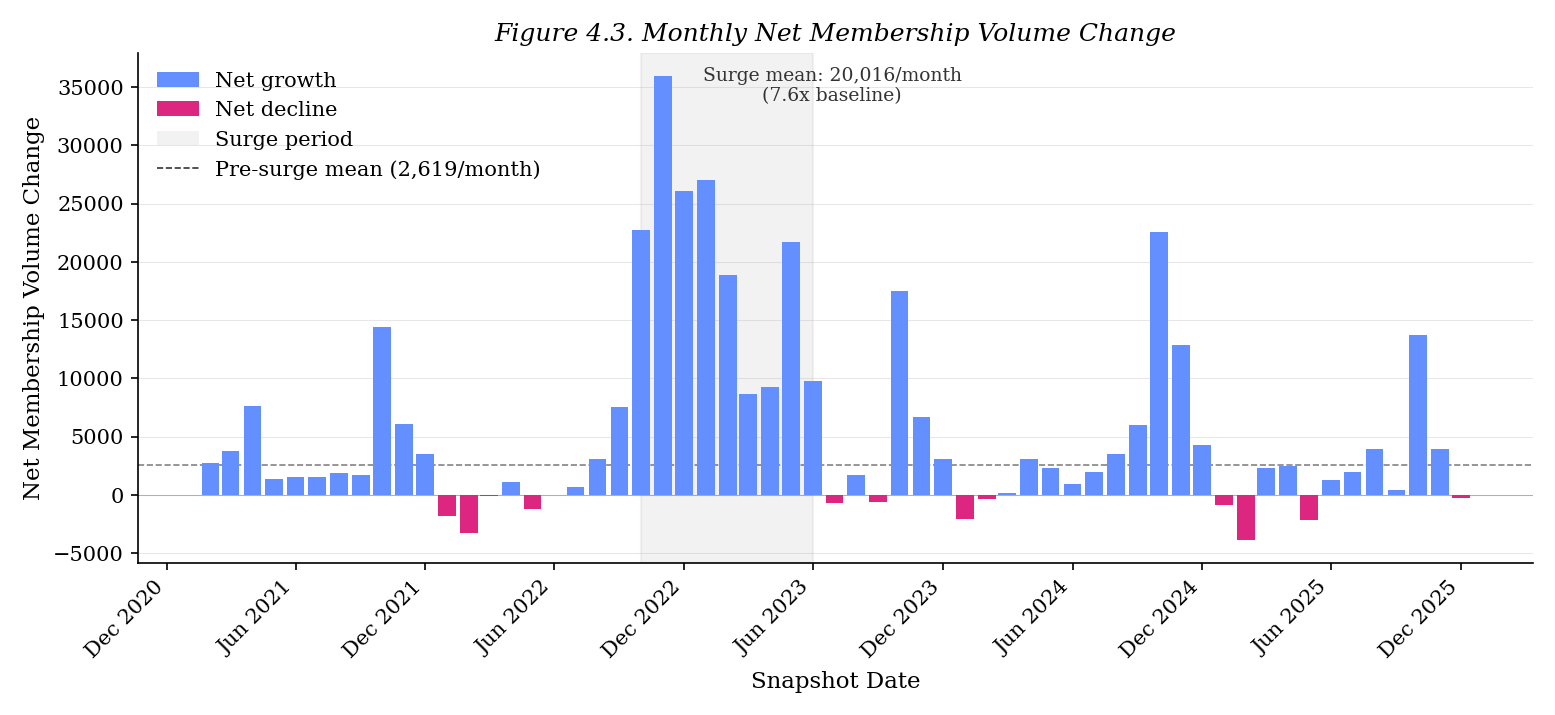

  ✓ Fig_4_3_monthly_net_volume_change.png (208 KB, 300 DPI)


'/tmp/presentation_figures/Fig_4_3_monthly_net_volume_change.png'

In [0]:
# ═══════════════════════════════════════════════════════════════
# 3.3 Fig 4.3 | Chapter 4, Section 4.5 | Source: silver_churn
# Monthly Net Membership Volume Change with Surge Period Annotation
# ═══════════════════════════════════════════════════════════════

# ── Aggregate total members by snapshot ────────────────────────
df_net = (
    silver_churn
    .groupBy("CM_snapshot_date")
    .agg(F.sum("q_members_t").alias("total_members"))
    .orderBy("CM_snapshot_date")
    .toPandas()
)

df_net["CM_snapshot_date"] = pd.to_datetime(df_net["CM_snapshot_date"])
df_net = df_net.sort_values("CM_snapshot_date").reset_index(drop=True)

# ── Compute month-on-month net change ──────────────────────────
df_net["net_change"] = df_net["total_members"].diff()
df_net = df_net.dropna(subset=["net_change"])

# ── Period means ───────────────────────────────────────────────
pre_mask   = df_net["CM_snapshot_date"] < SURGE_START
surge_mask = (
    (df_net["CM_snapshot_date"] >= SURGE_START) &
    (df_net["CM_snapshot_date"] <= SURGE_END)
)

pre_mean   = df_net.loc[pre_mask, "net_change"].mean()
surge_mean = df_net.loc[surge_mask, "net_change"].mean()
multiplier = surge_mean / pre_mean

# ── Cross-check against NB04 ──────────────────────────────────
print(f"Pre-surge mean  : {pre_mean:,.0f}/month  (NB04: 2,619)")
print(f"Surge mean      : {surge_mean:,.0f}/month  (NB04: 20,016)")
print(f"Multiplier      : {multiplier:.1f}x  (NB04: 7.6x)")

# ── Bar colour: positive = blue, negative = pink ───────────────
df_net["colour"] = df_net["net_change"].apply(
    lambda x: IBM_BLUE if x >= 0 else IBM_PINK
)

# ── Plot ───────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 5))

ax.bar(
    df_net["CM_snapshot_date"], df_net["net_change"],
    width=25, color=df_net["colour"], edgecolor="none", zorder=3
)

add_surge_shading(ax)

# ── Pre-surge baseline ─────────────────────────────────────────
ax.axhline(
    pre_mean, color=IBM_BLACK, linestyle="--",
    linewidth=0.8, alpha=0.6,
    label=f"Pre-surge mean ({pre_mean:,.0f}/month)"
)

# ── Zero line ──────────────────────────────────────────────────
ax.axhline(0, color=IBM_BLACK, linewidth=0.5, alpha=0.3)

# ── Annotate surge mean ────────────────────────────────────────
surge_mid = pd.Timestamp("2023-02-01")
annotate_value(
    ax, surge_mid, surge_mean,
    f"Surge mean: {surge_mean:,.0f}/month\n({multiplier:.1f}x baseline)",
    fontsize=9, va="bottom", offset=(50, 75)
)

# ── Custom legend ──────────────────────────────────────────────
legend_elements = [
    Patch(facecolor=IBM_BLUE, label="Net growth"),
    Patch(facecolor=IBM_PINK, label="Net decline"),
    Patch(facecolor=IBM_GREY, alpha=0.12, label="Surge period"),
    Line2D([0], [0], color=IBM_BLACK, linestyle="--",
           linewidth=0.8, label=f"Pre-surge mean ({pre_mean:,.0f}/month)"),
]
ax.legend(handles=legend_elements, loc="upper left")

ax.set_xlabel("Snapshot Date")
ax.set_ylabel("Net Membership Volume Change")
ax.set_title(
    "Figure 4.3. Monthly Net Membership Volume Change",
    fontsize=12, style="italic"
)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
fig.autofmt_xdate(rotation=45)

plt.show()
save_fig(fig, "Fig_4_3_monthly_net_volume_change.png")

### 3.3 Fig 4.4 | Chapter 4, Section 4.5

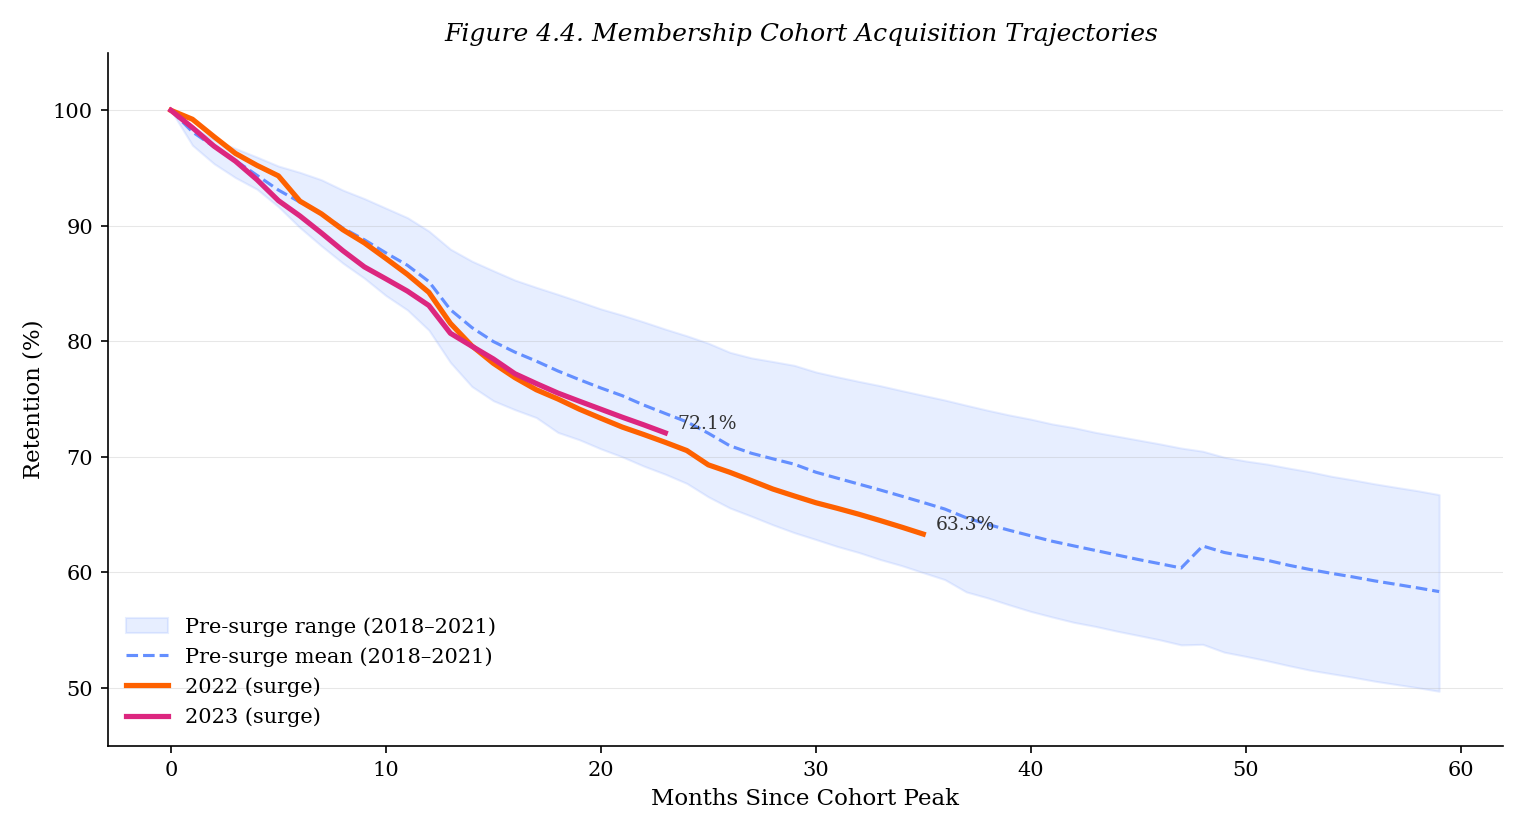

  ✓ Fig_4_4_cohort_trajectories.png (281 KB, 300 DPI)


'/tmp/presentation_figures/Fig_4_4_cohort_trajectories.png'

In [0]:
# ═══════════════════════════════════════════════════════════════
# 3.2 Fig 4.4 | Chapter 4, Section 4.5 | Source: silver_churn
# Membership Cohort Acquisition Trajectories by Calendar Year
# ═══════════════════════════════════════════════════════════════

# ── Aggregate members by YoJ and snapshot ──────────────────────
df_cohort = (
    silver_churn
    .filter(F.col("YoJ").between(2018, 2023))
    .groupBy("YoJ", "CM_snapshot_date")
    .agg(F.sum("q_members_t").alias("total_members"))
    .orderBy("YoJ", "CM_snapshot_date")
    .toPandas()
)

df_cohort["CM_snapshot_date"] = pd.to_datetime(df_cohort["CM_snapshot_date"])

# ── Track from each cohort's peak ──────────────────────────────
cohort_lines = {}
for yoj, grp in df_cohort.groupby("YoJ"):
    grp = grp.sort_values("CM_snapshot_date")
    peak_idx = grp["total_members"].idxmax()
    from_peak = grp.loc[peak_idx:].copy()
    from_peak["months_since_peak"] = range(len(from_peak))
    from_peak["retention_pct"] = (
        from_peak["total_members"] / from_peak["total_members"].iloc[0] * 100
    )
    cohort_lines[yoj] = from_peak

# ── Build pre-surge envelope (2018-2021) ───────────────────────
pre_surge_years = [2018, 2019, 2020, 2021]
max_months = max(len(cohort_lines[y]) for y in pre_surge_years)

pre_surge_matrix = pd.DataFrame({"months_since_peak": range(max_months)})
for yoj in pre_surge_years:
    data = cohort_lines[yoj].set_index("months_since_peak")["retention_pct"]
    pre_surge_matrix[yoj] = pre_surge_matrix["months_since_peak"].map(data)

pre_surge_matrix["mean"] = pre_surge_matrix[pre_surge_years].mean(axis=1)
pre_surge_matrix["min"]  = pre_surge_matrix[pre_surge_years].min(axis=1)
pre_surge_matrix["max"]  = pre_surge_matrix[pre_surge_years].max(axis=1)

# ── Plot ───────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 6))

# ── Pre-surge band ─────────────────────────────────────────────
valid = pre_surge_matrix.dropna(subset=["mean"])
ax.fill_between(
    valid["months_since_peak"], valid["min"], valid["max"],
    color=IBM_BLUE, alpha=0.15, label="Pre-surge range (2018–2021)"
)
ax.plot(
    valid["months_since_peak"], valid["mean"],
    color=IBM_BLUE, linewidth=1.5, linestyle="--",
    label="Pre-surge mean (2018–2021)"
)

# ── Surge cohorts ──────────────────────────────────────────────
surge_styles = {
    2022: {"color": IBM_ORANGE, "linewidth": 2.5, "label": "2022 (surge)"},
    2023: {"color": IBM_PINK,   "linewidth": 2.5, "label": "2023 (surge)"},
}

for yoj, style in surge_styles.items():
    data = cohort_lines[yoj]
    ax.plot(
        data["months_since_peak"], data["retention_pct"],
        zorder=4, **style
    )
    # ── Annotate endpoint ──────────────────────────────────────
    last = data.iloc[-1]
    annotate_value(
        ax, last["months_since_peak"], last["retention_pct"],
        f"{last['retention_pct']:.1f}%",
        fontsize=9, ha="left", offset=(6, 0)
    )

ax.set_xlabel("Months Since Cohort Peak")
ax.set_ylabel("Retention (%)")
ax.set_title(
    "Figure 4.4. Membership Cohort Acquisition Trajectories ",
    fontsize=12, style="italic"
)
ax.legend(loc="lower left")
ax.set_ylim(45, 105)

plt.show()
save_fig(fig, "Fig_4_4_cohort_trajectories.png")

## 4.0 Chapter 5 Figures — Churn Analysis & Statistical Findings
Data-driven figures covering national churn trends, seasonal patterns, regional uplift, survival curves, and age band deterioration. All figures source from Gold layer tables.

###4.1 Fig 5.1 | Chapter 5, Section 5.4

Pre-surge weighted rate  : 0.6344%
Post-surge weighted rate : 0.6801%
Uplift                   : 7.2%


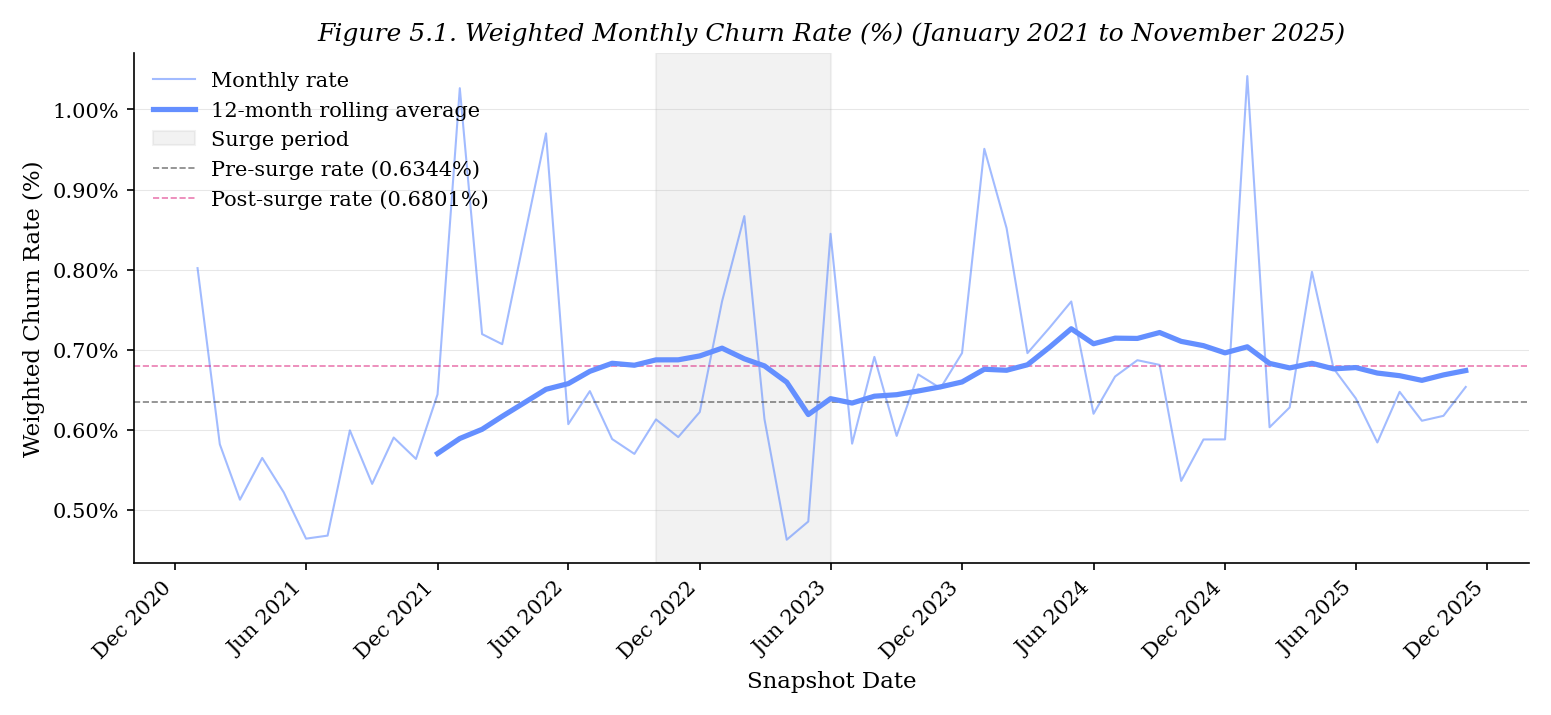

  ✓ Fig_5_1_monthly_churn_timeseries.png (341 KB, 300 DPI)


'/tmp/presentation_figures/Fig_5_1_monthly_churn_timeseries.png'

In [0]:
# ═══════════════════════════════════════════════════════════════
# 4.1 Fig 5.1 | Chapter 5, Section 5.4 | Source: gold churn_rates
# Weighted Monthly Churn Rate (%) (January 2021 to November 2025)
# ═══════════════════════════════════════════════════════════════

# ── National weighted churn rate by snapshot ───────────────────
df_national = (
    gold["churn_rates"]
    .groupBy("CM_snapshot_date")
    .agg(
        F.sum("q_leavers_t").alias("total_leavers"),
        F.sum("q_members_t").alias("total_members"),
    )
    .withColumn("churn_rate", F.col("total_leavers") / F.col("total_members"))
    .orderBy("CM_snapshot_date")
    .toPandas()
)

df_national["CM_snapshot_date"] = pd.to_datetime(df_national["CM_snapshot_date"])

# ── 12-month rolling average ──────────────────────────────────
df_national["rolling_12m"] = df_national["churn_rate"].rolling(12).mean()

# ── Period means (weighted, not .mean() on rates) ──────────────
pre_mask  = df_national["CM_snapshot_date"] < SURGE_START
post_mask = df_national["CM_snapshot_date"] >= POST_SURGE_START

pre_rate  = (df_national.loc[pre_mask, "total_leavers"].sum() /
             df_national.loc[pre_mask, "total_members"].sum())
post_rate = (df_national.loc[post_mask, "total_leavers"].sum() /
             df_national.loc[post_mask, "total_members"].sum())

print(f"Pre-surge weighted rate  : {pre_rate*100:.4f}%")
print(f"Post-surge weighted rate : {post_rate*100:.4f}%")
print(f"Uplift                   : {((post_rate - pre_rate) / pre_rate)*100:.1f}%")

# ── Plot ───────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 5))

# ── Monthly rate ───────────────────────────────────────────────
ax.plot(
    df_national["CM_snapshot_date"], df_national["churn_rate"],
    color=IBM_BLUE, linewidth=1, alpha=0.6, label="Monthly rate", zorder=2
)

# ── 12-month rolling average ──────────────────────────────────
ax.plot(
    df_national["CM_snapshot_date"], df_national["rolling_12m"],
    color=IBM_BLUE, linewidth=2.5, label="12-month rolling average", zorder=3
)

add_surge_shading(ax)

# ── Pre-surge and post-surge means ─────────────────────────────
ax.axhline(
    pre_rate, color=IBM_BLACK, linestyle="--", linewidth=0.8, alpha=0.6,
    label=f"Pre-surge rate ({pre_rate*100:.4f}%)"
)
ax.axhline(
    post_rate, color=IBM_PINK, linestyle="--", linewidth=0.8, alpha=0.6,
    label=f"Post-surge rate ({post_rate*100:.4f}%)"
)

format_pct_axis(ax, axis="y", decimals=2)

ax.set_xlabel("Snapshot Date")
ax.set_ylabel("Weighted Churn Rate (%)")
ax.set_title(
    "Figure 5.1. Weighted Monthly Churn Rate (%) "
    "(January 2021 to November 2025)",
    fontsize=12, style="italic"
)
ax.legend(loc="upper left")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
fig.autofmt_xdate(rotation=45)

plt.show()
save_fig(fig, "Fig_5_1_monthly_churn_timeseries.png")

### 4.2 Fig 5.2 | Chapter 5, Section 5.4

Nurse member pre-surge  : 0.4822%
Nurse member post-surge : 0.5357%
Nurse member uplift     : +11.1%


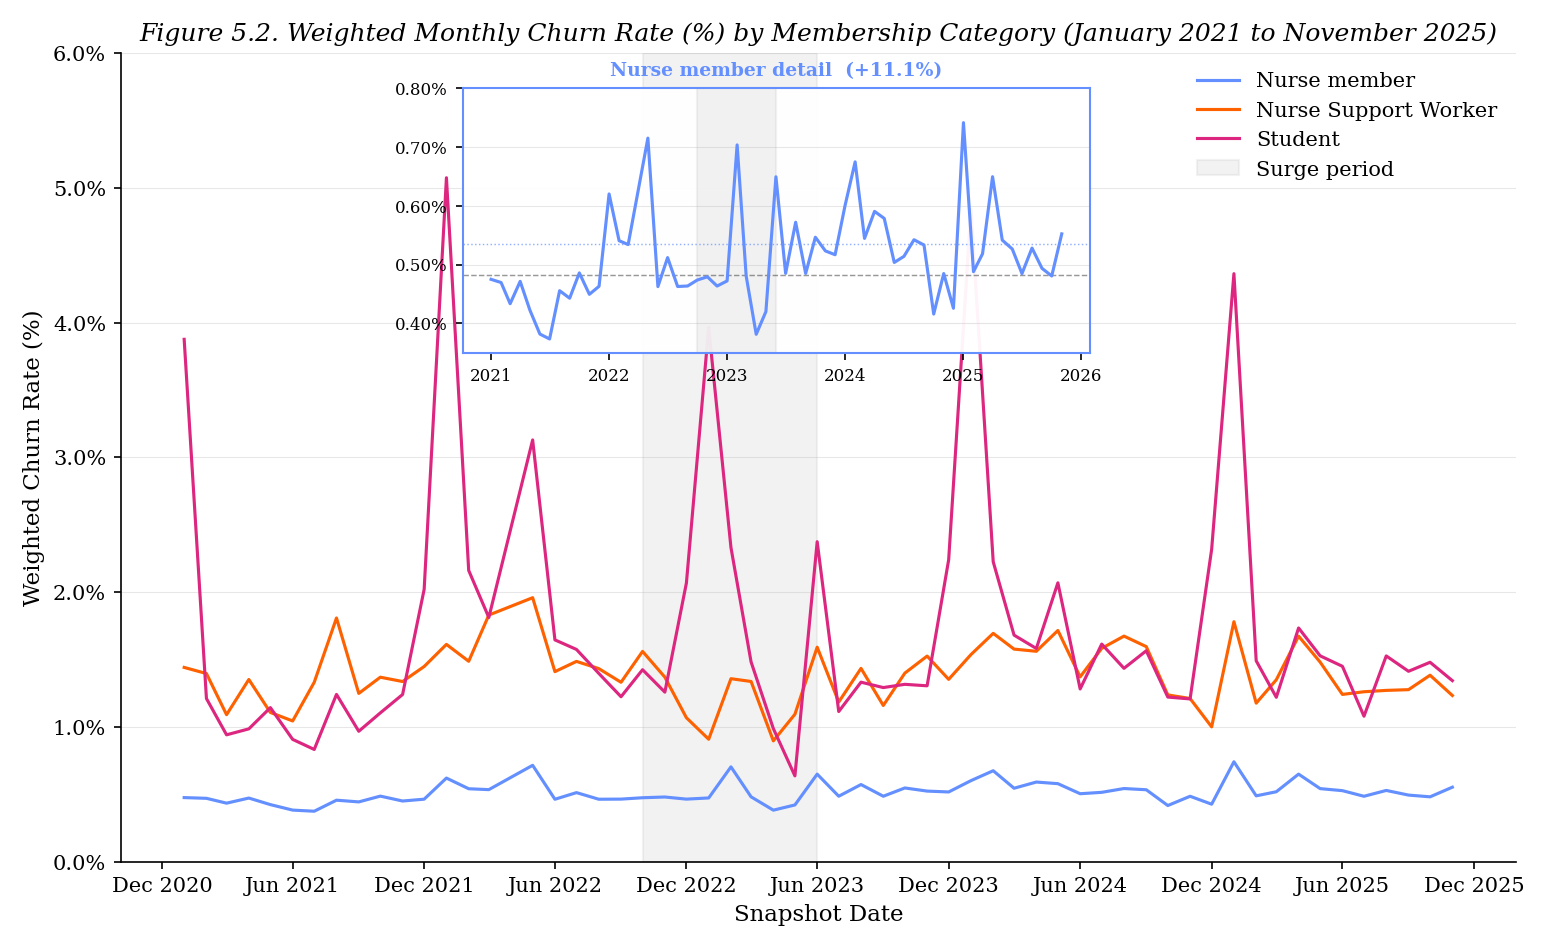

  ✓ Fig_5_2_churn_by_category.png (475 KB, 300 DPI)


'/tmp/presentation_figures/Fig_5_2_churn_by_category.png'

In [0]:
# ═══════════════════════════════════════════════════════════════
# 4.2 Fig 5.2 | Chapter 5, Section 5.4 | Source: gold churn_rates
# Weighted Monthly Churn Rate by Membership Category (with inset)
# ═══════════════════════════════════════════════════════════════

# ── Weighted churn rate by category and snapshot ───────────────
df_cat = (
    gold["churn_rates"]
    .groupBy("CM_snapshot_date", "MemCategory")
    .agg(
        F.sum("q_leavers_t").alias("total_leavers"),
        F.sum("q_members_t").alias("total_members"),
    )
    .withColumn("churn_rate", F.col("total_leavers") / F.col("total_members"))
    .orderBy("CM_snapshot_date", "MemCategory")
    .toPandas()
)

df_cat["CM_snapshot_date"] = pd.to_datetime(df_cat["CM_snapshot_date"])

# ── Pre/post rates for Nurse member ────────────────────────────
nurse = df_cat[df_cat["MemCategory"] == "Nurse member"]
nurse_pre = nurse[nurse["CM_snapshot_date"] < SURGE_START]
nurse_post = nurse[nurse["CM_snapshot_date"] >= POST_SURGE_START]
nurse_pre_rate = nurse_pre["total_leavers"].sum() / nurse_pre["total_members"].sum()
nurse_post_rate = nurse_post["total_leavers"].sum() / nurse_post["total_members"].sum()
nurse_uplift = ((nurse_post_rate - nurse_pre_rate) / nurse_pre_rate) * 100

print(f"Nurse member pre-surge  : {nurse_pre_rate*100:.4f}%")
print(f"Nurse member post-surge : {nurse_post_rate*100:.4f}%")
print(f"Nurse member uplift     : {nurse_uplift:+.1f}%")

# ── Main plot ──────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 7))

for cat in CATEGORY_ORDER:
    subset = df_cat[df_cat["MemCategory"] == cat].sort_values("CM_snapshot_date")
    ax.plot(
        subset["CM_snapshot_date"], subset["churn_rate"],
        color=category_colour(cat), linewidth=1.5, label=cat, zorder=3
    )

add_surge_shading(ax)
format_pct_axis(ax, axis="y", decimals=1)

ax.set_ylim(0, 0.06)
ax.set_xlabel("Snapshot Date")
ax.set_ylabel("Weighted Churn Rate (%)")
ax.set_title(
    "Figure 5.2. Weighted Monthly Churn Rate (%) by Membership Category "
    "(January 2021 to November 2025)",
    fontsize=12, style="italic"
)
ax.legend(loc="upper right")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=6))

# ── Inset: Nurse member detail ─────────────────────────────────
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

ax_inset = inset_axes(ax, width="45%", height="40%",
                       bbox_to_anchor=(-0.03, 0.15, 1, 0.82),
                       bbox_transform=ax.transAxes, loc="upper center")

nurse_sorted = nurse.sort_values("CM_snapshot_date")
ax_inset.plot(
    nurse_sorted["CM_snapshot_date"], nurse_sorted["churn_rate"],
    color=IBM_BLUE, linewidth=1.5, zorder=3
)

# ── Surge shading in inset ─────────────────────────────────────
ax_inset.axvspan(
    pd.Timestamp(SURGE_START), pd.Timestamp(SURGE_END),
    color=IBM_GREY, alpha=0.12, zorder=0
)

# ── Pre/post reference lines in inset ──────────────────────────
ax_inset.axhline(
    nurse_pre_rate, color=IBM_BLACK, linestyle="--",
    linewidth=0.7, alpha=0.5
)
ax_inset.axhline(
    nurse_post_rate, color=IBM_BLUE, linestyle=":",
    linewidth=0.7, alpha=0.7
)

# ── Inset formatting ───────────────────────────────────────────
ax_inset.set_ylim(0.0035, 0.008)
format_pct_axis(ax_inset, axis="y", decimals=2)
ax_inset.set_title(
    f"Nurse member detail  (+{nurse_uplift:.1f}%)",
    fontsize=9, color=IBM_BLUE, fontweight="bold"
)
ax_inset.tick_params(labelsize=8)
ax_inset.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax_inset.xaxis.set_major_locator(mdates.YearLocator())
ax_inset.set_facecolor("white")
ax_inset.patch.set_alpha(0.95)


# ── Border around inset ────────────────────────────────────────
for spine in ax_inset.spines.values():
    spine.set_edgecolor(IBM_BLUE)
    spine.set_linewidth(1)
    spine.set_visible(True)

fig.autofmt_xdate(rotation=45)

plt.show()
save_fig(fig, "Fig_5_2_churn_by_category.png")

###4.3 Fig 5.3 | Chapter 5, Section 5.5

January average     : 0.9162%
Non-January average : 0.6356%
January premium     : 1.44x


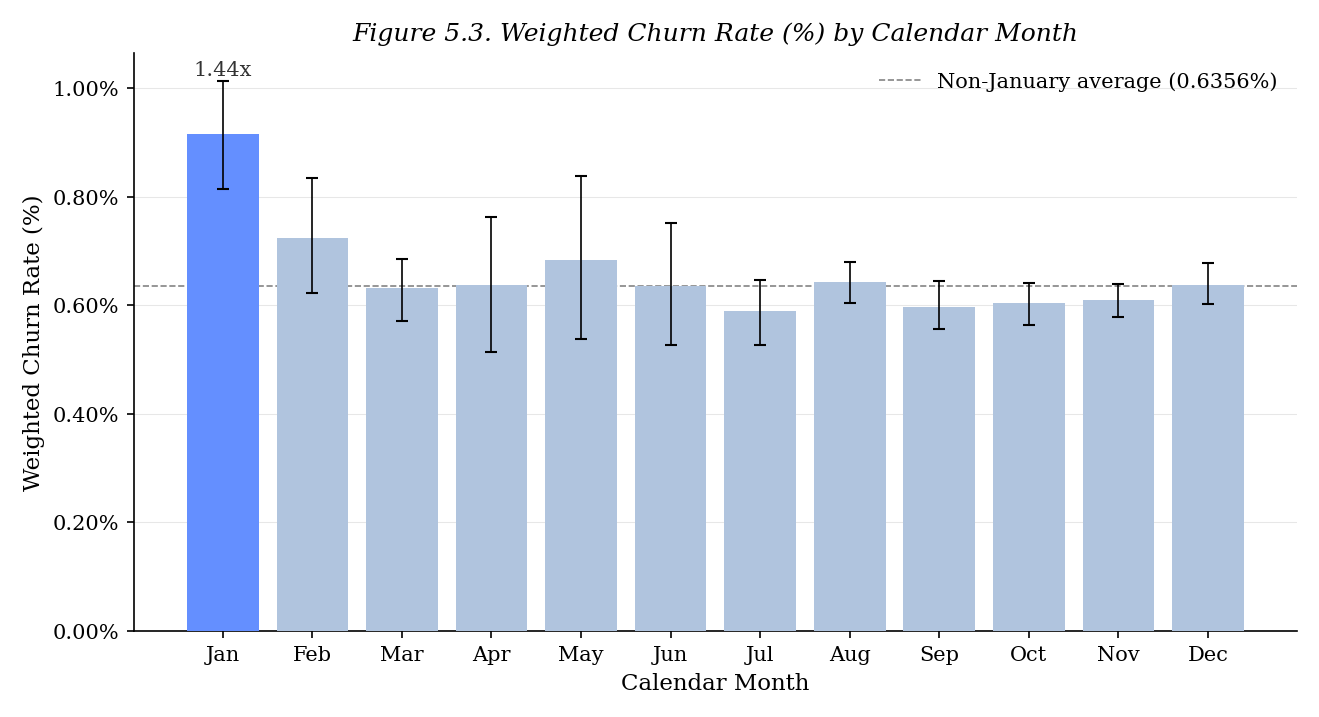

  ✓ Fig_5_3_churn_by_month.png (143 KB, 300 DPI)


'/tmp/presentation_figures/Fig_5_3_churn_by_month.png'

In [0]:
# ═══════════════════════════════════════════════════════════════
# 4.3 Fig 5.3 | Chapter 5, Section 5.5 | Source: gold churn_rates
# Weighted Churn Rate (%) by Calendar Month
# ═══════════════════════════════════════════════════════════════

# ── National weighted rate per snapshot ─────────────────────────
df_monthly = (
    gold["churn_rates"]
    .groupBy("CM_snapshot_date")
    .agg(
        F.sum("q_leavers_t").alias("total_leavers"),
        F.sum("q_members_t").alias("total_members"),
    )
    .withColumn("churn_rate", F.col("total_leavers") / F.col("total_members"))
    .toPandas()
)

df_monthly["CM_snapshot_date"] = pd.to_datetime(df_monthly["CM_snapshot_date"])
df_monthly["calendar_month"] = df_monthly["CM_snapshot_date"].dt.month

# ── Average rate by calendar month ─────────────────────────────
monthly_avg = df_monthly.groupby("calendar_month")["churn_rate"].mean()
non_jan_avg = df_monthly[df_monthly["calendar_month"] != 1]["churn_rate"].mean()
jan_avg = monthly_avg[1]
jan_premium = jan_avg / non_jan_avg

print(f"January average     : {jan_avg*100:.4f}%")
print(f"Non-January average : {non_jan_avg*100:.4f}%")
print(f"January premium     : {jan_premium:.2f}x")

# ── Bootstrap 95% CIs ─────────────────────────────────────────
np.random.seed(42)
n_boot = 1000
ci_low, ci_high = [], []

for m in range(1, 13):
    rates = df_monthly[df_monthly["calendar_month"] == m]["churn_rate"].values
    boot_means = [np.random.choice(rates, size=len(rates), replace=True).mean()
                  for _ in range(n_boot)]
    ci_low.append(np.percentile(boot_means, 2.5))
    ci_high.append(np.percentile(boot_means, 97.5))

# ── Bar colours ────────────────────────────────────────────────
bar_colours = [IBM_BLUE if m == 1 else "#B0C4DE" for m in range(1, 13)]

# ── Plot ───────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))

month_labels = ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
                "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
x = np.arange(12)
values = [monthly_avg[m] for m in range(1, 13)]
errors_low = [values[i] - ci_low[i] for i in range(12)]
errors_high = [ci_high[i] - values[i] for i in range(12)]

ax.bar(
    x, values, color=bar_colours, edgecolor="none",
    yerr=[errors_low, errors_high], capsize=3,
    error_kw={"linewidth": 0.8, "color": IBM_BLACK}, zorder=3
)

# ── Non-January baseline ───────────────────────────────────────
ax.axhline(
    non_jan_avg, color=IBM_BLACK, linestyle="--",
    linewidth=0.8, alpha=0.6,
    label=f"Non-January average ({non_jan_avg*100:.4f}%)"
)

# ── Annotate January premium ───────────────────────────────────
annotate_value(
    ax, 0, jan_avg, f"{jan_premium:.2f}x",
    fontsize=10, va="top", offset=(0, 35)
)

format_pct_axis(ax, axis="y", decimals=2)
ax.set_xticks(x)
ax.set_xticklabels(month_labels)
ax.set_xlabel("Calendar Month")
ax.set_ylabel("Weighted Churn Rate (%)")
ax.set_title(
    "Figure 5.3. Weighted Churn Rate (%) by Calendar Month",
    fontsize=12, style="italic"
)
ax.legend(loc="upper right")

plt.show()
save_fig(fig, "Fig_5_3_churn_by_month.png")

### 4.4 Fig 5.4 | Chapter 5, Section 5.6

National Nurse member uplift: 12.0%


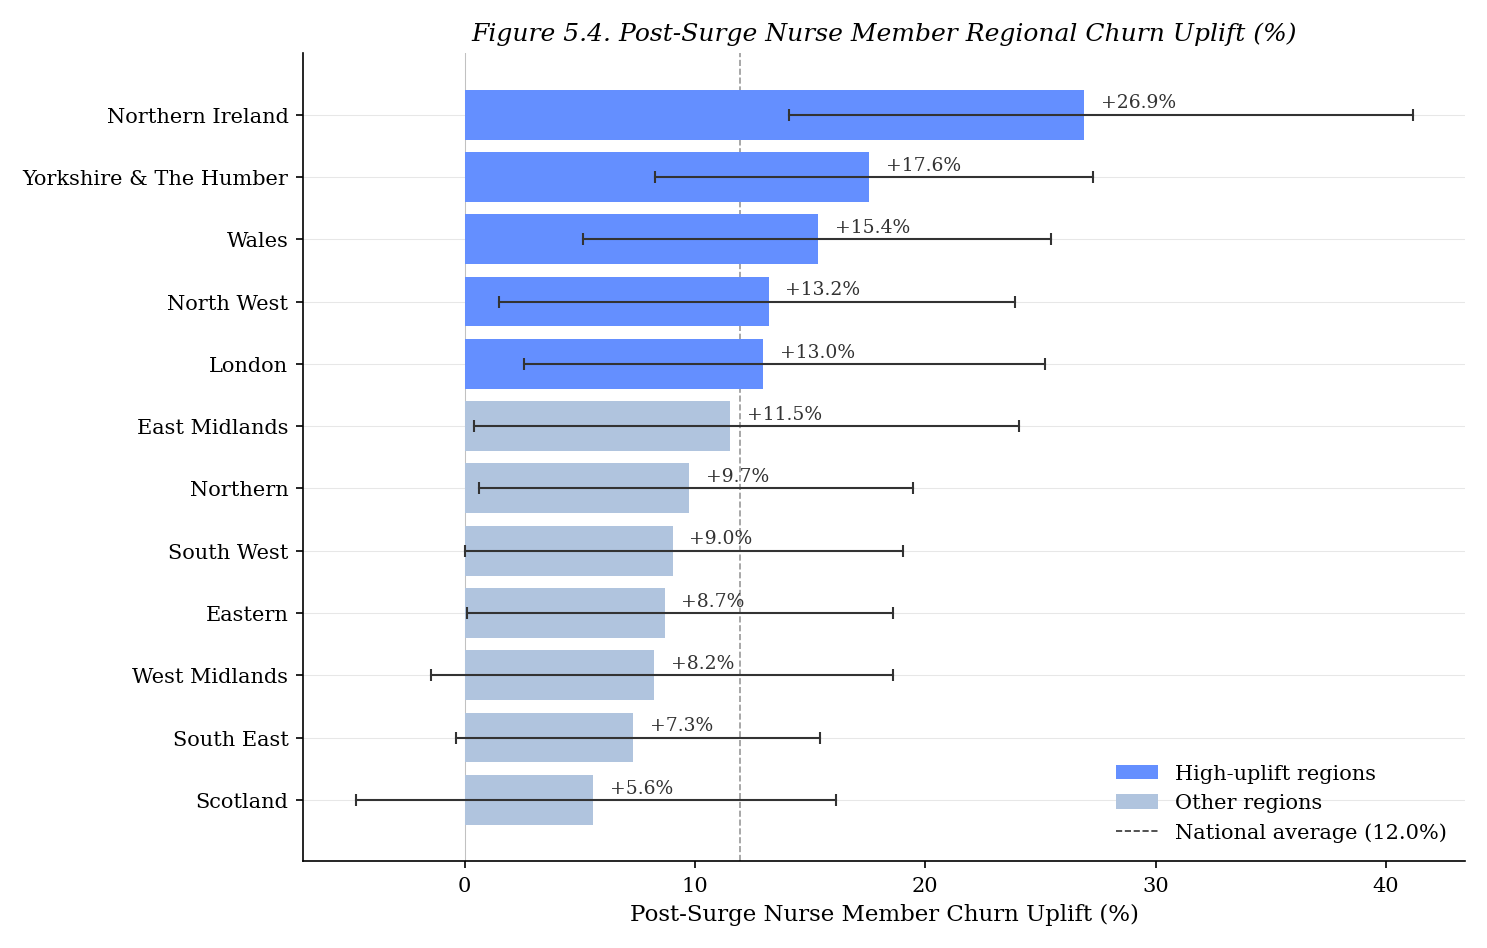

  ✓ Fig_5_4_regional_uplift.png (238 KB, 300 DPI)


'/tmp/presentation_figures/Fig_5_4_regional_uplift.png'

In [0]:
# ═══════════════════════════════════════════════════════════════
# 4.4 Fig 5.4 | Chapter 5, Section 5.6 | Source: gold churn_rates
# Post-Surge Nurse Member Regional Churn Uplift (%)
# Method: Mean of monthly weighted rates (consistent with NB07)
# ═══════════════════════════════════════════════════════════════

# ── Compute using NB07 method ──────────────────────────────────
EXCLUDE_REGIONS = ["Non Members", "Unknown", "H Q (Overseas)"]

df_nurse_monthly = (
    gold["churn_rates"]
    .filter(
        (F.col("MemCategory") == "Nurse member") &
        (~F.col("Region").isin(EXCLUDE_REGIONS))
    )
    .groupBy("CM_snapshot_date", "Region")
    .agg(
        F.sum("q_leavers_t").alias("total_leavers"),
        F.sum("q_members_t").alias("total_members"),
    )
    .withColumn("churn_rate", F.col("total_leavers") / F.col("total_members"))
    .toPandas()
)

df_nurse_monthly["CM_snapshot_date"] = pd.to_datetime(df_nurse_monthly["CM_snapshot_date"])
df_nurse_monthly["period"] = df_nurse_monthly["CM_snapshot_date"].apply(
    lambda d: "Pre-surge" if d < pd.Timestamp(SURGE_START)
    else "Surge" if d <= pd.Timestamp(SURGE_END)
    else "Post-surge"
)

# ── Mean of monthly rates per region per period ────────────────
region_period = (
    df_nurse_monthly[df_nurse_monthly["period"].isin(["Pre-surge", "Post-surge"])]
    .groupby(["Region", "period"])["churn_rate"]
    .mean()
    .unstack()
)

region_period["uplift_pct"] = (
    (region_period["Post-surge"] - region_period["Pre-surge"])
    / region_period["Pre-surge"] * 100
)

df_uplift = region_period.reset_index().sort_values("uplift_pct", ascending=True)

# ── Bootstrap 95% CIs on uplift ────────────────────────────────
np.random.seed(42)
n_boot = 1000

ci_results = {}
for region in df_uplift["Region"]:
    subset = df_nurse_monthly[df_nurse_monthly["Region"] == region]
    pre_rates = subset[subset["period"] == "Pre-surge"]["churn_rate"].values
    post_rates = subset[subset["period"] == "Post-surge"]["churn_rate"].values

    boot_uplifts = []
    for _ in range(n_boot):
        b_pre = np.random.choice(pre_rates, size=len(pre_rates), replace=True).mean()
        b_post = np.random.choice(post_rates, size=len(post_rates), replace=True).mean()
        boot_uplifts.append(((b_post - b_pre) / b_pre) * 100)

    ci_results[region] = (np.percentile(boot_uplifts, 2.5),
                          np.percentile(boot_uplifts, 97.5))

df_uplift["ci_low"] = df_uplift["Region"].map(lambda r: ci_results[r][0])
df_uplift["ci_high"] = df_uplift["Region"].map(lambda r: ci_results[r][1])

# ── National Nurse member average uplift ───────────────────────
national_pre = df_nurse_monthly[df_nurse_monthly["period"] == "Pre-surge"]["churn_rate"].mean()
national_post = df_nurse_monthly[df_nurse_monthly["period"] == "Post-surge"]["churn_rate"].mean()
national_uplift = ((national_post - national_pre) / national_pre) * 100

print(f"National Nurse member uplift: {national_uplift:.1f}%")

# ── Plot ───────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 7))

y = np.arange(len(df_uplift))

for i, (_, row) in enumerate(df_uplift.iterrows()):
    is_highlight = row["Region"] in HIGH_UPLIFT_REGIONS
    colour = IBM_BLUE if is_highlight else "#B0C4DE"

    ax.barh(i, row["uplift_pct"], color=colour, edgecolor="none", zorder=3)

    # ── Error bars ─────────────────────────────────────────────
    ax.plot(
        [row["ci_low"], row["ci_high"]], [i, i],
        color=IBM_BLACK, linewidth=1, zorder=4
    )
    ax.plot(row["ci_low"], i, "|", color=IBM_BLACK, markersize=6, zorder=4)
    ax.plot(row["ci_high"], i, "|", color=IBM_BLACK, markersize=6, zorder=4)

    # ── Annotate value ─────────────────────────────────────────
    annotate_value(
        ax, row["uplift_pct"], i,
        f"{row['uplift_pct']:+.1f}%",
        fontsize=9, ha="left", va="top", offset=(8, 10)
    )

# ── Zero line ──────────────────────────────────────────────────
ax.axvline(0, color=IBM_BLACK, linewidth=0.5, alpha=0.3)

# ── National average line ──────────────────────────────────────
ax.axvline(
    national_uplift, color=IBM_BLACK, linestyle="--",
    linewidth=0.8, alpha=0.5,
    label=f"National Nurse member average ({national_uplift:.1f}%)"
)

ax.set_yticks(y)
ax.set_yticklabels(df_uplift["Region"])
ax.set_xlabel("Post-Surge Nurse Member Churn Uplift (%)")
ax.set_title(
    "Figure 5.4. Post-Surge Nurse Member Regional Churn Uplift (%)",
    fontsize=12, style="italic"
)

legend_elements = [
    Patch(facecolor=IBM_BLUE, label="High-uplift regions"),
    Patch(facecolor="#B0C4DE", label="Other regions"),
    Line2D([0], [0], color=IBM_BLACK, linestyle="--",
           linewidth=0.8, label=f"National average ({national_uplift:.1f}%)"),
]
ax.legend(handles=legend_elements, loc="lower right")

plt.show()
save_fig(fig, "Fig_5_4_regional_uplift.png")

### 4.5 Fig 5.5 | Chapter 5, Section 5.7

Nurse Member Post-Surge Uplift by Age Band (NB07 method)
----------------------------------------------------------------------
Age Band             Pre     Post   Uplift      r    p(Bonf) Sig
----------------------------------------------------------------------
2. 25-34        0.6463% 0.6520%    +0.9% 0.072     1.0000  No
3. 35-44        0.4833% 0.5187%    +7.3% 0.176     1.0000  No
4. 45-54        0.3140% 0.3599%   +14.6% 0.521     0.0110  Yes
5. 55-64        0.4164% 0.4998%   +20.0% 0.676     0.0003  Yes
6. 65 and over  0.7956% 0.9105%   +14.4% 0.659     0.0005  Yes


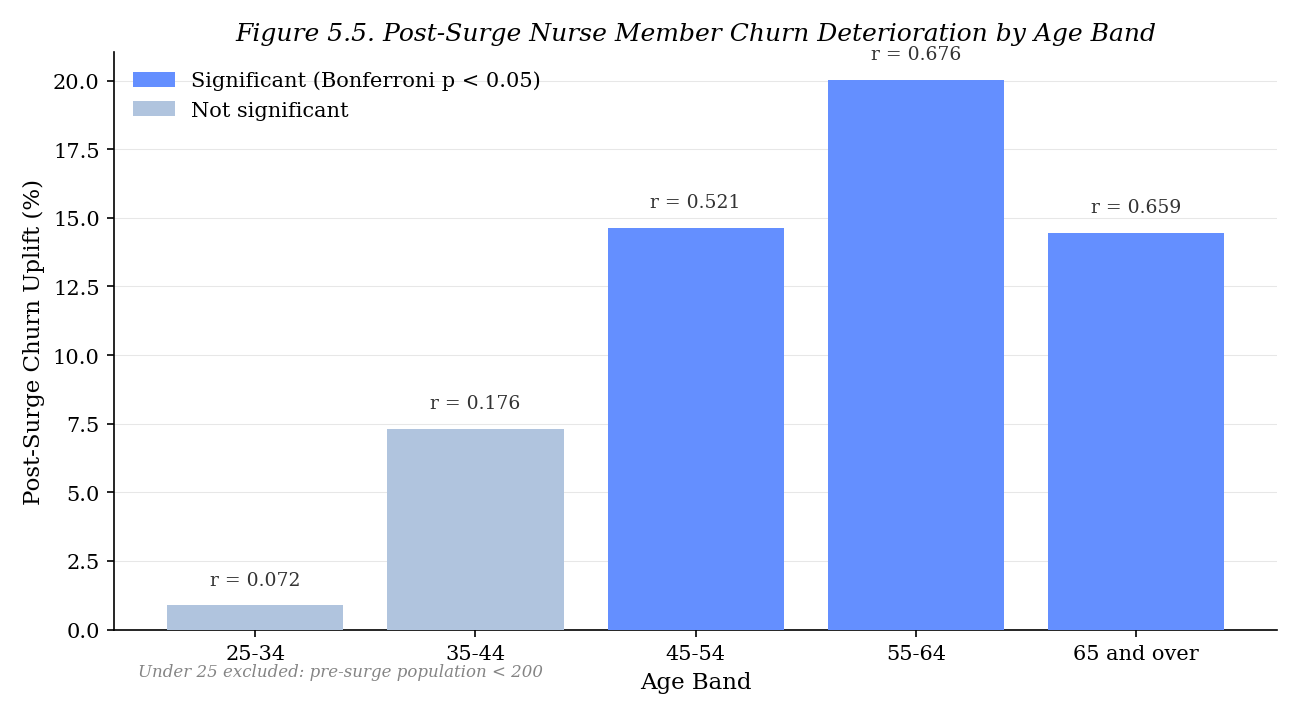

  ✓ Fig_5_5_age_band_deterioration.png (169 KB, 300 DPI)


'/tmp/presentation_figures/Fig_5_5_age_band_deterioration.png'

In [0]:
# ═══════════════════════════════════════════════════════════════
# 4.5 Fig 5.5 | Chapter 5, Section 5.7 | Source: gold feature_engineered
# Post-Surge Nurse Member Churn Deterioration by Age Band
# Method: Mean of monthly weighted rates (consistent with NB07)
# ═══════════════════════════════════════════════════════════════

from scipy.stats import mannwhitneyu

# ── Nurse member monthly rates by age band ─────────────────────
df_age = (
    gold["feature_engineered"]
.filter(
        (F.col("MemCategory") == "Nurse member") &
        (F.col("age_band") != "Unknown")
    )
    .groupBy("CM_snapshot_date", "age_band")
    .agg(
        F.sum("q_leavers_t").alias("total_leavers"),
        F.sum("q_members_t").alias("total_members"),
    )
    .withColumn("churn_rate", F.col("total_leavers") / F.col("total_members"))
    .toPandas()
)

df_age["CM_snapshot_date"] = pd.to_datetime(df_age["CM_snapshot_date"])
df_age["period"] = df_age["CM_snapshot_date"].apply(
    lambda d: "Pre-surge" if d < pd.Timestamp(SURGE_START)
    else "Surge" if d <= pd.Timestamp(SURGE_END)
    else "Post-surge"
)

# ── Uplift + Mann-Whitney per age band ─────────────────────────
AGE_ORDER = ["2. 25-34", "3. 35-44", "4. 45-54", "5. 55-64", "6. 65 and over"]
n_tests = len(AGE_ORDER)
results = []

for band in AGE_ORDER:
    subset = df_age[df_age["age_band"] == band]
    pre_rates = subset[subset["period"] == "Pre-surge"]["churn_rate"].values
    post_rates = subset[subset["period"] == "Post-surge"]["churn_rate"].values

    pre_mean = pre_rates.mean()
    post_mean = post_rates.mean()
    uplift = ((post_mean - pre_mean) / pre_mean) * 100

    # ── Mann-Whitney U with rank-biserial r ────────────────────
    stat, p_val = mannwhitneyu(pre_rates, post_rates, alternative="two-sided")
    n1, n2 = len(pre_rates), len(post_rates)
    r_rb = 1 - (2 * stat) / (n1 * n2)

    # ── Bonferroni correction ──────────────────────────────────
    p_bonf = min(p_val * n_tests, 1.0)
    sig = p_bonf < 0.05

    results.append({
        "age_band": band, "pre": pre_mean, "post": post_mean,
        "uplift_pct": uplift, "r_rb": abs(r_rb), "p_bonf": p_bonf,
        "significant": sig,
    })

df_results = pd.DataFrame(results)

# ── Print cross-check against NB07 ────────────────────────────
print("Nurse Member Post-Surge Uplift by Age Band (NB07 method)")
print("-" * 70)
print(f"{'Age Band':<15} {'Pre':>8} {'Post':>8} {'Uplift':>8} {'r':>6} {'p(Bonf)':>10} {'Sig'}")
print("-" * 70)
for _, row in df_results.iterrows():
    sig_label = "Yes" if row["significant"] else "No"
    print(f"{row['age_band']:<15} {row['pre']*100:.4f}% {row['post']*100:.4f}% "
          f"{row['uplift_pct']:>+7.1f}% {row['r_rb']:>5.3f} {row['p_bonf']:>10.4f}  {sig_label}")

# ── Clean labels for display ───────────────────────────────────
display_labels = [b.split(". ", 1)[1] if ". " in b else b for b in AGE_ORDER]

# ── Plot ───────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))

x = np.arange(len(df_results))

for i, (_, row) in enumerate(df_results.iterrows()):
    colour = IBM_BLUE if row["significant"] else "#B0C4DE"
    ax.bar(i, row["uplift_pct"], color=colour, edgecolor="none", zorder=3)

    # ── Annotate effect size above bar ─────────────────────────
    annotate_value(
        ax, i, row["uplift_pct"],
        f"r = {row['r_rb']:.3f}",
        fontsize=9, ha="center", va="bottom", offset=(0, 8)
    )

ax.set_xticks(x)
ax.set_xticklabels(display_labels)
ax.set_xlabel("Age Band")
ax.set_ylabel("Post-Surge Churn Uplift (%)")
ax.set_title(
    "Figure 5.5. Post-Surge Nurse Member Churn Deterioration by Age Band",
    fontsize=12, style="italic"
)

# ── Under 25 exclusion note ────────────────────────────────────
ax.annotate(
    "Under 25 excluded: pre-surge population < 200",
    xy=(0.02, -0.08), xycoords="axes fraction",
    fontsize=8, color=IBM_BLACK, alpha=0.6, style="italic"
)

# ── Legend ──────────────────────────────────────────────────────
legend_elements = [
    Patch(facecolor=IBM_BLUE, label="Significant (Bonferroni p < 0.05)"),
    Patch(facecolor="#B0C4DE", label="Not significant"),
]
ax.legend(handles=legend_elements, loc="upper left")

plt.show()
save_fig(fig, "Fig_5_5_age_band_deterioration.png")

## 5.0 Chapter 6 Figures — Predictive Modelling & Risk Segmentation
Data-driven figures covering model comparison, feature importance, forecasts, risk tiers, and revenue impact. All figures source from Gold layer tables produced by Notebook 08.

### 5.1 Fig 6.1 | Chapter 6, Section 6.3

Poisson AIC          : 635,250
Negative Binomial AIC: 427,666
AIC reduction        : 207,584
Poisson dispersion   : 4.89
NB dispersion        : 2.33


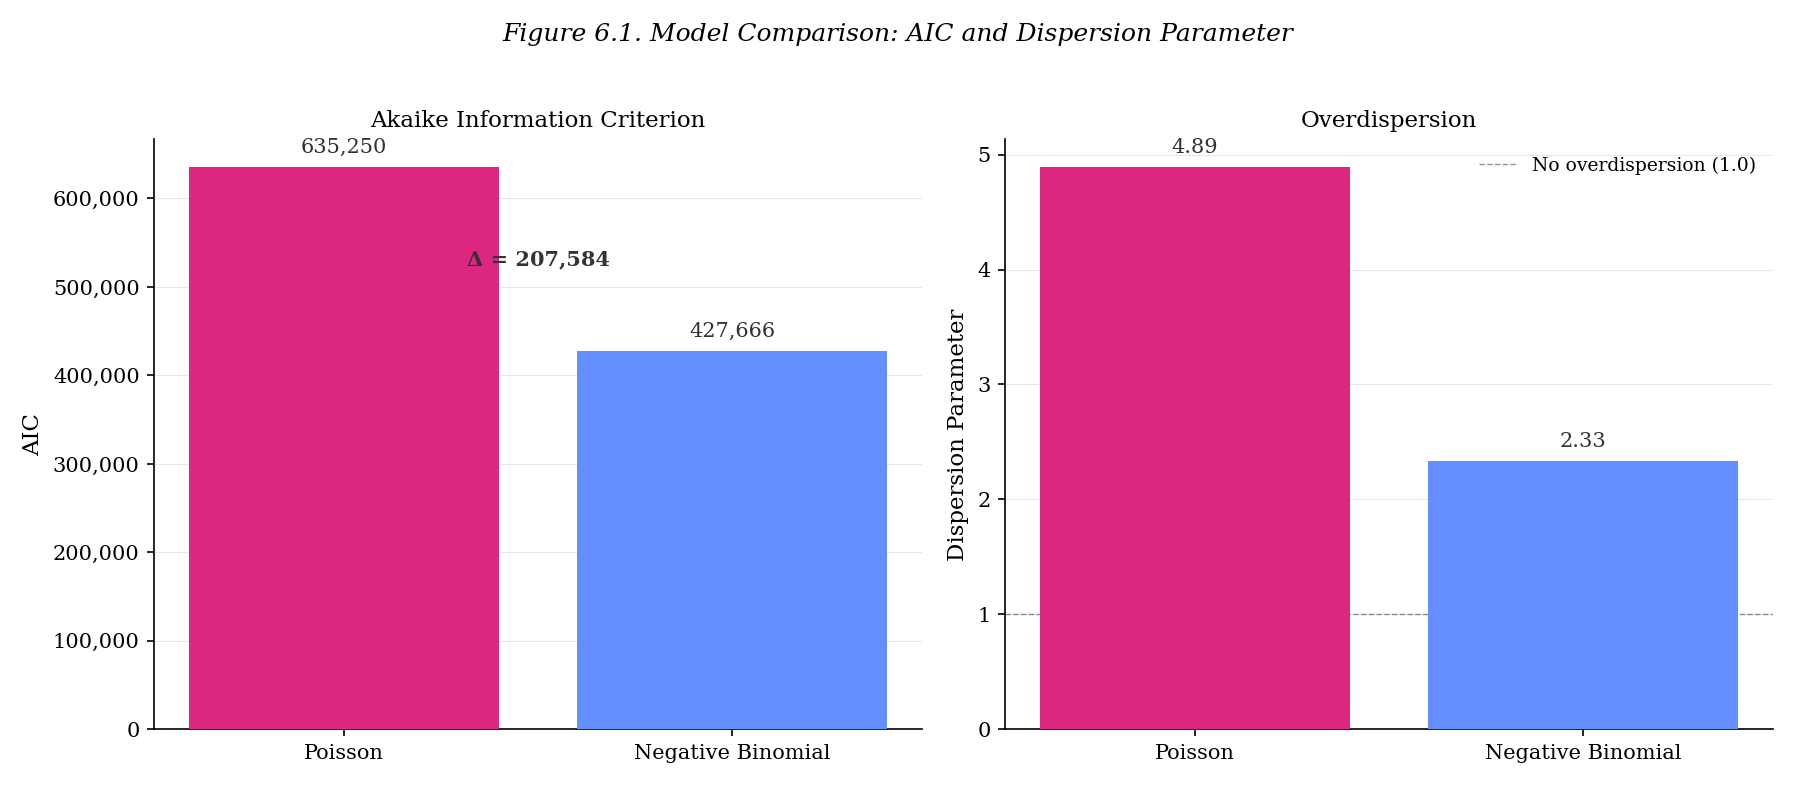

  ✓ Fig_6_1_model_comparison.png (180 KB, 300 DPI)


'/tmp/presentation_figures/Fig_6_1_model_comparison.png'

In [0]:
# ═══════════════════════════════════════════════════════════════
# 5.1 Fig 6.1 | Chapter 6, Section 6.3 | Source: CONFIRMED values
# Model Comparison: AIC and Dispersion Parameter
# ═══════════════════════════════════════════════════════════════

# ── Confirmed values from NB08 ─────────────────────────────────
models = ["Poisson", "Negative Binomial"]
aic_values = [CONFIRMED["poisson_aic"], CONFIRMED["nb_aic"]]
disp_values = [CONFIRMED["poisson_dispersion"], CONFIRMED["nb_dispersion"]]
aic_delta = aic_values[0] - aic_values[1]

print(f"Poisson AIC          : {aic_values[0]:,}")
print(f"Negative Binomial AIC: {aic_values[1]:,}")
print(f"AIC reduction        : {aic_delta:,}")
print(f"Poisson dispersion   : {disp_values[0]}")
print(f"NB dispersion        : {disp_values[1]}")

# ── Plot ───────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# ── Left panel: AIC ───────────────────────────────────────────
bars1 = ax1.bar(models, aic_values,
                color=[IBM_PINK, IBM_BLUE], edgecolor="none", zorder=3)

for bar, val in zip(bars1, aic_values):
    ax1.annotate(
        f"{val:,}", xy=(bar.get_x() + bar.get_width() / 2, val),
        fontsize=10, ha="center", va="bottom", color=IBM_BLACK,
        xytext=(0, 5), textcoords="offset points"
    )

# ── AIC delta bracket ─────────────────────────────────────────
ax1.annotate(
    f"Δ = {aic_delta:,}",
    xy=(0.5, (aic_values[0] + aic_values[1]) / 2),
    fontsize=10, ha="center", va="center", color=IBM_BLACK,
    fontweight="bold"
)

ax1.set_ylabel("AIC")
ax1.set_title("Akaike Information Criterion", fontsize=11)
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))

# ── Right panel: Dispersion ────────────────────────────────────
bars2 = ax2.bar(models, disp_values,
                color=[IBM_PINK, IBM_BLUE], edgecolor="none", zorder=3)

for bar, val in zip(bars2, disp_values):
    ax2.annotate(
        f"{val:.2f}", xy=(bar.get_x() + bar.get_width() / 2, val),
        fontsize=10, ha="center", va="bottom", color=IBM_BLACK,
        xytext=(0, 5), textcoords="offset points"
    )

ax2.axhline(1.0, color=IBM_BLACK, linestyle="--", linewidth=0.7, alpha=0.5,
            label="No overdispersion (1.0)")
ax2.set_ylabel("Dispersion Parameter")
ax2.set_title("Overdispersion", fontsize=11)
ax2.legend(loc="upper right", fontsize=9)

fig.suptitle(
    "Figure 6.1. Model Comparison: AIC and Dispersion Parameter",
    fontsize=12, style="italic", y=1.02
)

plt.tight_layout()
plt.show()
save_fig(fig, "Fig_6_1_model_comparison.png")

### 5.2 Fig 6.2 | Chapter 6, Section 6.4

Paired Hazard Ratios (Period excluded — encoding artefact)
---------------------------------------------------------------------------
Covariate             Cox HR           Cox CI   NB RR            NB CI Match
---------------------------------------------------------------------------
MemSectorType          0.522   [0.520, 0.524]   0.583   [0.578, 0.589]   Yes
MemCategory            0.660   [0.656, 0.664]   0.691   [0.679, 0.704]   Yes
North-South            1.069   [1.065, 1.073]   1.045   [1.032, 1.058]   Yes
age_band               1.178   [1.175, 1.180]   1.129   [1.121, 1.136]   Yes
tenure_band            1.304   [1.300, 1.307]   1.446   [1.432, 1.460]   Yes
Surge cohort           1.429   [1.419, 1.439]   1.071   [1.047, 1.097]   Yes
January flag           2.547   [2.525, 2.568]   1.450   [1.398, 1.503]   Yes


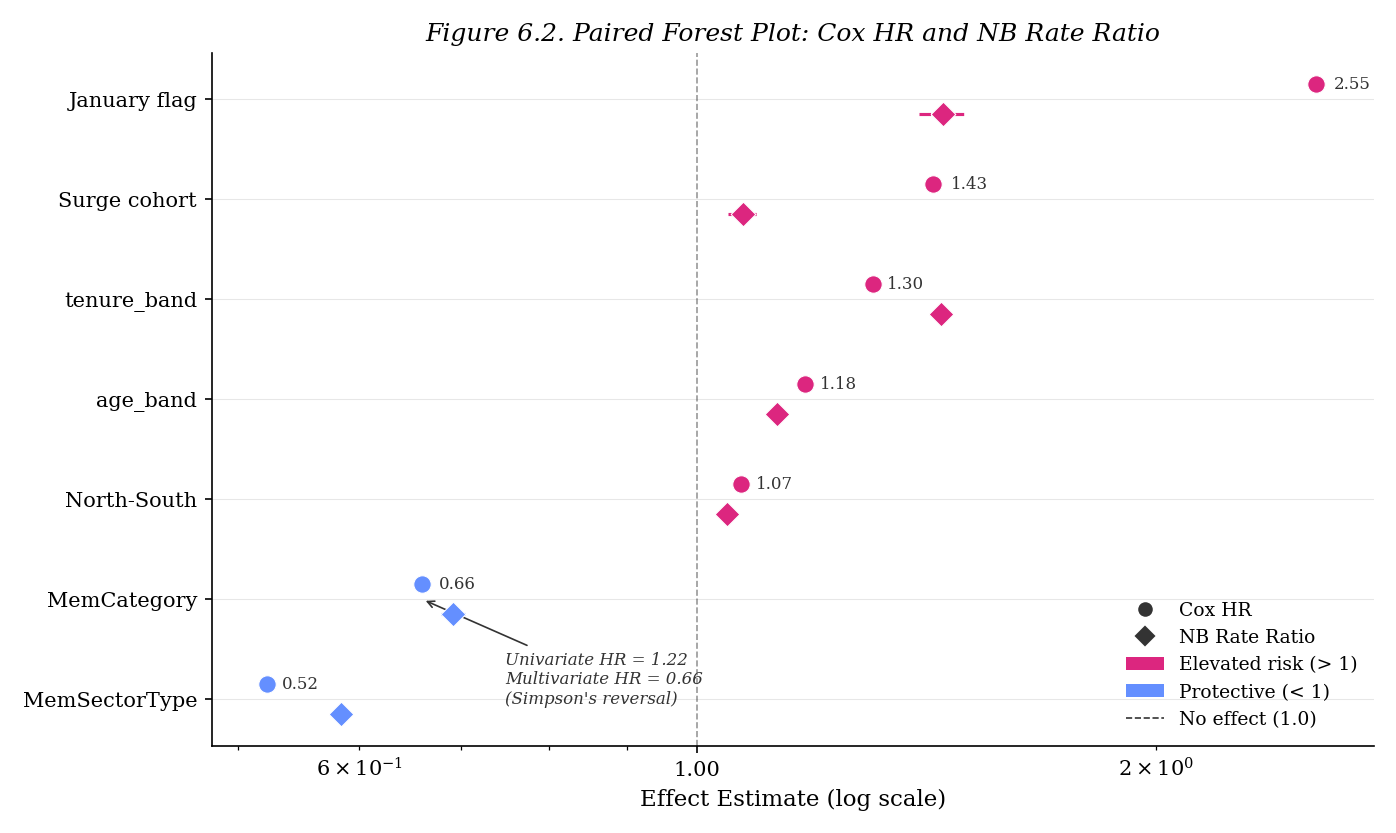

  ✓ Fig_6_2_hazard_forest_plot.png (211 KB, 300 DPI)


'/tmp/presentation_figures/Fig_6_2_hazard_forest_plot.png'

In [0]:
# ═══════════════════════════════════════════════════════════════
# 5.2 Fig 6.2 | Chapter 6, Section 6.4 | Source: gold hazard_ratios
# Paired Forest Plot: Cox HR vs NB Rate Ratio (7 Covariates)
# ═══════════════════════════════════════════════════════════════

# ── Load and filter ────────────────────────────────────────────
df_hr = gold["hazard_ratios"].toPandas()
df_hr = df_hr[df_hr["covariate"] != "Period"].copy()
df_hr = df_hr.sort_values("cox_hr", ascending=True).reset_index(drop=True)

# ── Print cross-check ─────────────────────────────────────────
print("Paired Hazard Ratios (Period excluded — encoding artefact)")
print("-" * 75)
print(f"{'Covariate':<20} {'Cox HR':>7} {'Cox CI':>16} {'NB RR':>7} {'NB CI':>16} {'Match'}")
print("-" * 75)
for _, row in df_hr.iterrows():
    cox_ci = f"[{row['cox_ci_lower']:.3f}, {row['cox_ci_upper']:.3f}]"
    nb_ci = f"[{row['nb_ci_lower']:.3f}, {row['nb_ci_upper']:.3f}]"
    match = "Yes" if row["direction_match"] else "NO"
    print(f"{row['covariate']:<20} {row['cox_hr']:>7.3f} {cox_ci:>16} "
          f"{row['nb_rr']:>7.3f} {nb_ci:>16} {match:>5}")

# ── Plot ───────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 6))

y = np.arange(len(df_hr))
offset = 0.15  # vertical offset between Cox and NB points

for i, (_, row) in enumerate(df_hr.iterrows()):

    # ── Cox HR ─────────────────────────────────────────────────
    cox_colour = IBM_PINK if row["cox_hr"] > 1 else IBM_BLUE
    ax.scatter(row["cox_hr"], i + offset, color=cox_colour, s=70,
               marker="o", zorder=4, edgecolors="white", linewidth=0.5)
    ax.plot([row["cox_ci_lower"], row["cox_ci_upper"]],
            [i + offset, i + offset],
            color=cox_colour, linewidth=1.5, zorder=3)

    # ── NB Rate Ratio ──────────────────────────────────────────
    nb_colour = IBM_PINK if row["nb_rr"] > 1 else IBM_BLUE
    ax.scatter(row["nb_rr"], i - offset, color=nb_colour, s=70,
               marker="D", zorder=4, edgecolors="white", linewidth=0.5)
    ax.plot([row["nb_ci_lower"], row["nb_ci_upper"]],
            [i - offset, i - offset],
            color=nb_colour, linewidth=1.5, zorder=3, linestyle="--")

    # ── Annotate Cox HR ────────────────────────────────────────
    ax.annotate(
        f"{row['cox_hr']:.2f}", xy=(row["cox_ci_upper"], i + offset),
        fontsize=8, ha="left", va="center", color=IBM_BLACK,
        xytext=(6, 0), textcoords="offset points"
    )

# ── Reference line ─────────────────────────────────────────────
ax.axvline(1.0, color=IBM_BLACK, linestyle="--", linewidth=0.8,
           alpha=0.5, label="No effect (1.0)")

# ── MemCategory reversal annotation ────────────────────────────
mem_row = df_hr[df_hr["covariate"] == "MemCategory"]
if len(mem_row) > 0:
    mem_idx = mem_row.index[0]
    mem_hr = mem_row["cox_hr"].values[0]
    ax.annotate(
        f"Univariate HR = 1.22\nMultivariate HR = {mem_hr:.2f}\n(Simpson's reversal)",
        xy=(mem_hr, mem_idx),
        fontsize=8, ha="left", va="top", color=IBM_BLACK,
        xytext=(40, -25), textcoords="offset points",
        arrowprops=dict(arrowstyle="->", color=IBM_BLACK, lw=0.8),
        style="italic"
    )

# ── Log scale ──────────────────────────────────────────────────
ax.set_xscale("log")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.2f}"))

# ── Labels ─────────────────────────────────────────────────────
ax.set_yticks(y)
ax.set_yticklabels(df_hr["covariate"])
ax.set_xlabel("Effect Estimate (log scale)")
ax.set_title(
    "Figure 6.2. Paired Forest Plot: Cox HR and NB Rate Ratio",
    fontsize=12, style="italic"
)

# ── Legend ──────────────────────────────────────────────────────
legend_elements = [
    Line2D([0], [0], marker="o", color="w", markerfacecolor=IBM_BLACK,
           markersize=8, label="Cox HR"),
    Line2D([0], [0], marker="D", color="w", markerfacecolor=IBM_BLACK,
           markersize=8, label="NB Rate Ratio"),
    Patch(facecolor=IBM_PINK, label="Elevated risk (> 1)"),
    Patch(facecolor=IBM_BLUE, label="Protective (< 1)"),
    Line2D([0], [0], color=IBM_BLACK, linestyle="--",
           linewidth=0.8, label="No effect (1.0)"),
]
ax.legend(handles=legend_elements, loc="lower right", fontsize=9)

plt.show()
save_fig(fig, "Fig_6_2_hazard_forest_plot.png")

### 5.3 Fig 6.3 | Chapter 6, Section 6.5

SHAP Global Feature Importance
------------------------------------------------------------
Covariate                  Mean |SHAP|  % Total  Cumul %
------------------------------------------------------------
January flag                  0.272672     2.7%   100.0%
Surge cohort                  0.325844     3.2%    97.3%
North-South                   0.412568     4.0%    94.2%
Period                        0.425284     4.1%    90.2%
tenure_band                   0.856775     8.3%    86.0%
age_band                      1.815782    17.7%    77.7%
MemCategory                   2.921071    28.4%    60.0%
MemSectorType                 3.241476    31.6%    31.6%

Top 3: MemSectorType, MemCategory, age_band (77.7% of total)
Surrogate model R-squared: 0.687


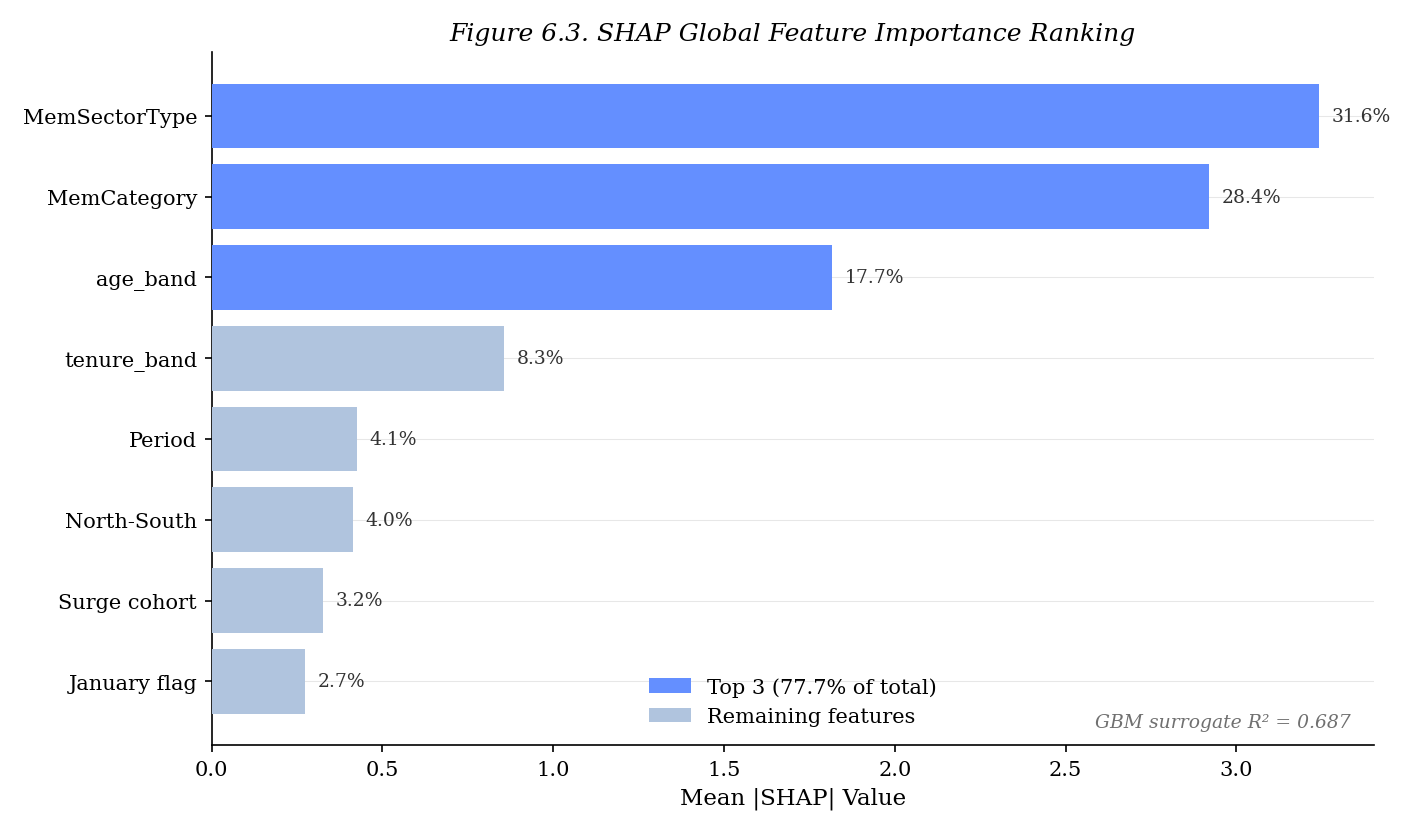

  ✓ Fig_6_3_shap_importance.png (180 KB, 300 DPI)


'/tmp/presentation_figures/Fig_6_3_shap_importance.png'

In [0]:
# ═══════════════════════════════════════════════════════════════
# 5.3 Fig 6.3 | Chapter 6, Section 6.5 | Source: gold shap_importance
# SHAP Global Feature Importance Ranking
# ═══════════════════════════════════════════════════════════════

# ── Load and sort ──────────────────────────────────────────────
df_shap = gold["shap_importance"].toPandas()
df_shap = df_shap.sort_values("Mean_Abs_SHAP", ascending=True).reset_index(drop=True)

# ── Print cross-check ──────────────────────────────────────────
print("SHAP Global Feature Importance")
print("-" * 60)
print(f"{'Covariate':<25} {'Mean |SHAP|':>12} {'% Total':>8} {'Cumul %':>8}")
print("-" * 60)
for _, row in df_shap.iterrows():
    print(f"{row['Covariate']:<25} {row['Mean_Abs_SHAP']:>12.6f} "
          f"{row['Pct_Total']:>7.1f}% {row['Cumulative']:>7.1f}%")

# ── Top 3 identification ──────────────────────────────────────
top3 = df_shap.nlargest(3, "Mean_Abs_SHAP")["Covariate"].tolist()
top3_cumul = df_shap.nlargest(3, "Mean_Abs_SHAP")["Cumulative"].max()

print(f"\nTop 3: {', '.join(top3)} ({top3_cumul:.1f}% of total)")
print(f"Surrogate model R-squared: {CONFIRMED['gbm_surrogate_r2']}")

# ── Bar colours: top 3 dark, rest light ────────────────────────
colours = [IBM_BLUE if row["Covariate"] in top3 else "#B0C4DE"
           for _, row in df_shap.iterrows()]

# ── Plot ───────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 6))

y = np.arange(len(df_shap))

ax.barh(y, df_shap["Mean_Abs_SHAP"], color=colours, edgecolor="none", zorder=3)

# ── Annotate cumulative % ──────────────────────────────────────
for i, (_, row) in enumerate(df_shap.iterrows()):
    ax.annotate(
        f"{row['Pct_Total']:.1f}%",
        xy=(row["Mean_Abs_SHAP"], i),
        fontsize=9, ha="left", va="center", color=IBM_BLACK,
        xytext=(6, 0), textcoords="offset points"
    )

ax.set_yticks(y)
ax.set_yticklabels(df_shap["Covariate"])
ax.set_xlabel("Mean |SHAP| Value")
ax.set_title(
    "Figure 6.3. SHAP Global Feature Importance Ranking",
    fontsize=12, style="italic"
)

# ── Subtitle with surrogate R² ─────────────────────────────────
ax.text(
    0.98, 0.02, f"GBM surrogate R² = {CONFIRMED['gbm_surrogate_r2']}",
    transform=ax.transAxes, fontsize=9, ha="right", va="bottom",
    color=IBM_BLACK, style="italic", alpha=0.7
)

# ── Legend ──────────────────────────────────────────────────────
legend_elements = [
    Patch(facecolor=IBM_BLUE, label=f"Top 3 ({top3_cumul:.1f}% of total)"),
    Patch(facecolor="#B0C4DE", label="Remaining features"),
]
ax.legend(handles=legend_elements, loc="lower center")

plt.show()
save_fig(fig, "Fig_6_3_shap_importance.png")

### 5.4 Fig 6.4 | Chapter 6, Section 6.6

Forecast segments (8):
  Nurse Support Worker (National)          Prophet
  Nurse member (London)                    Prophet
  Nurse member (National)                  Prophet
  Nurse member (North West)                Prophet
  Nurse member (Northern Ireland)          SARIMAX
  Nurse member (Wales)                     Prophet
  Nurse member (Yorkshire & The Humber)    Prophet
  Student (National)                       Prophet


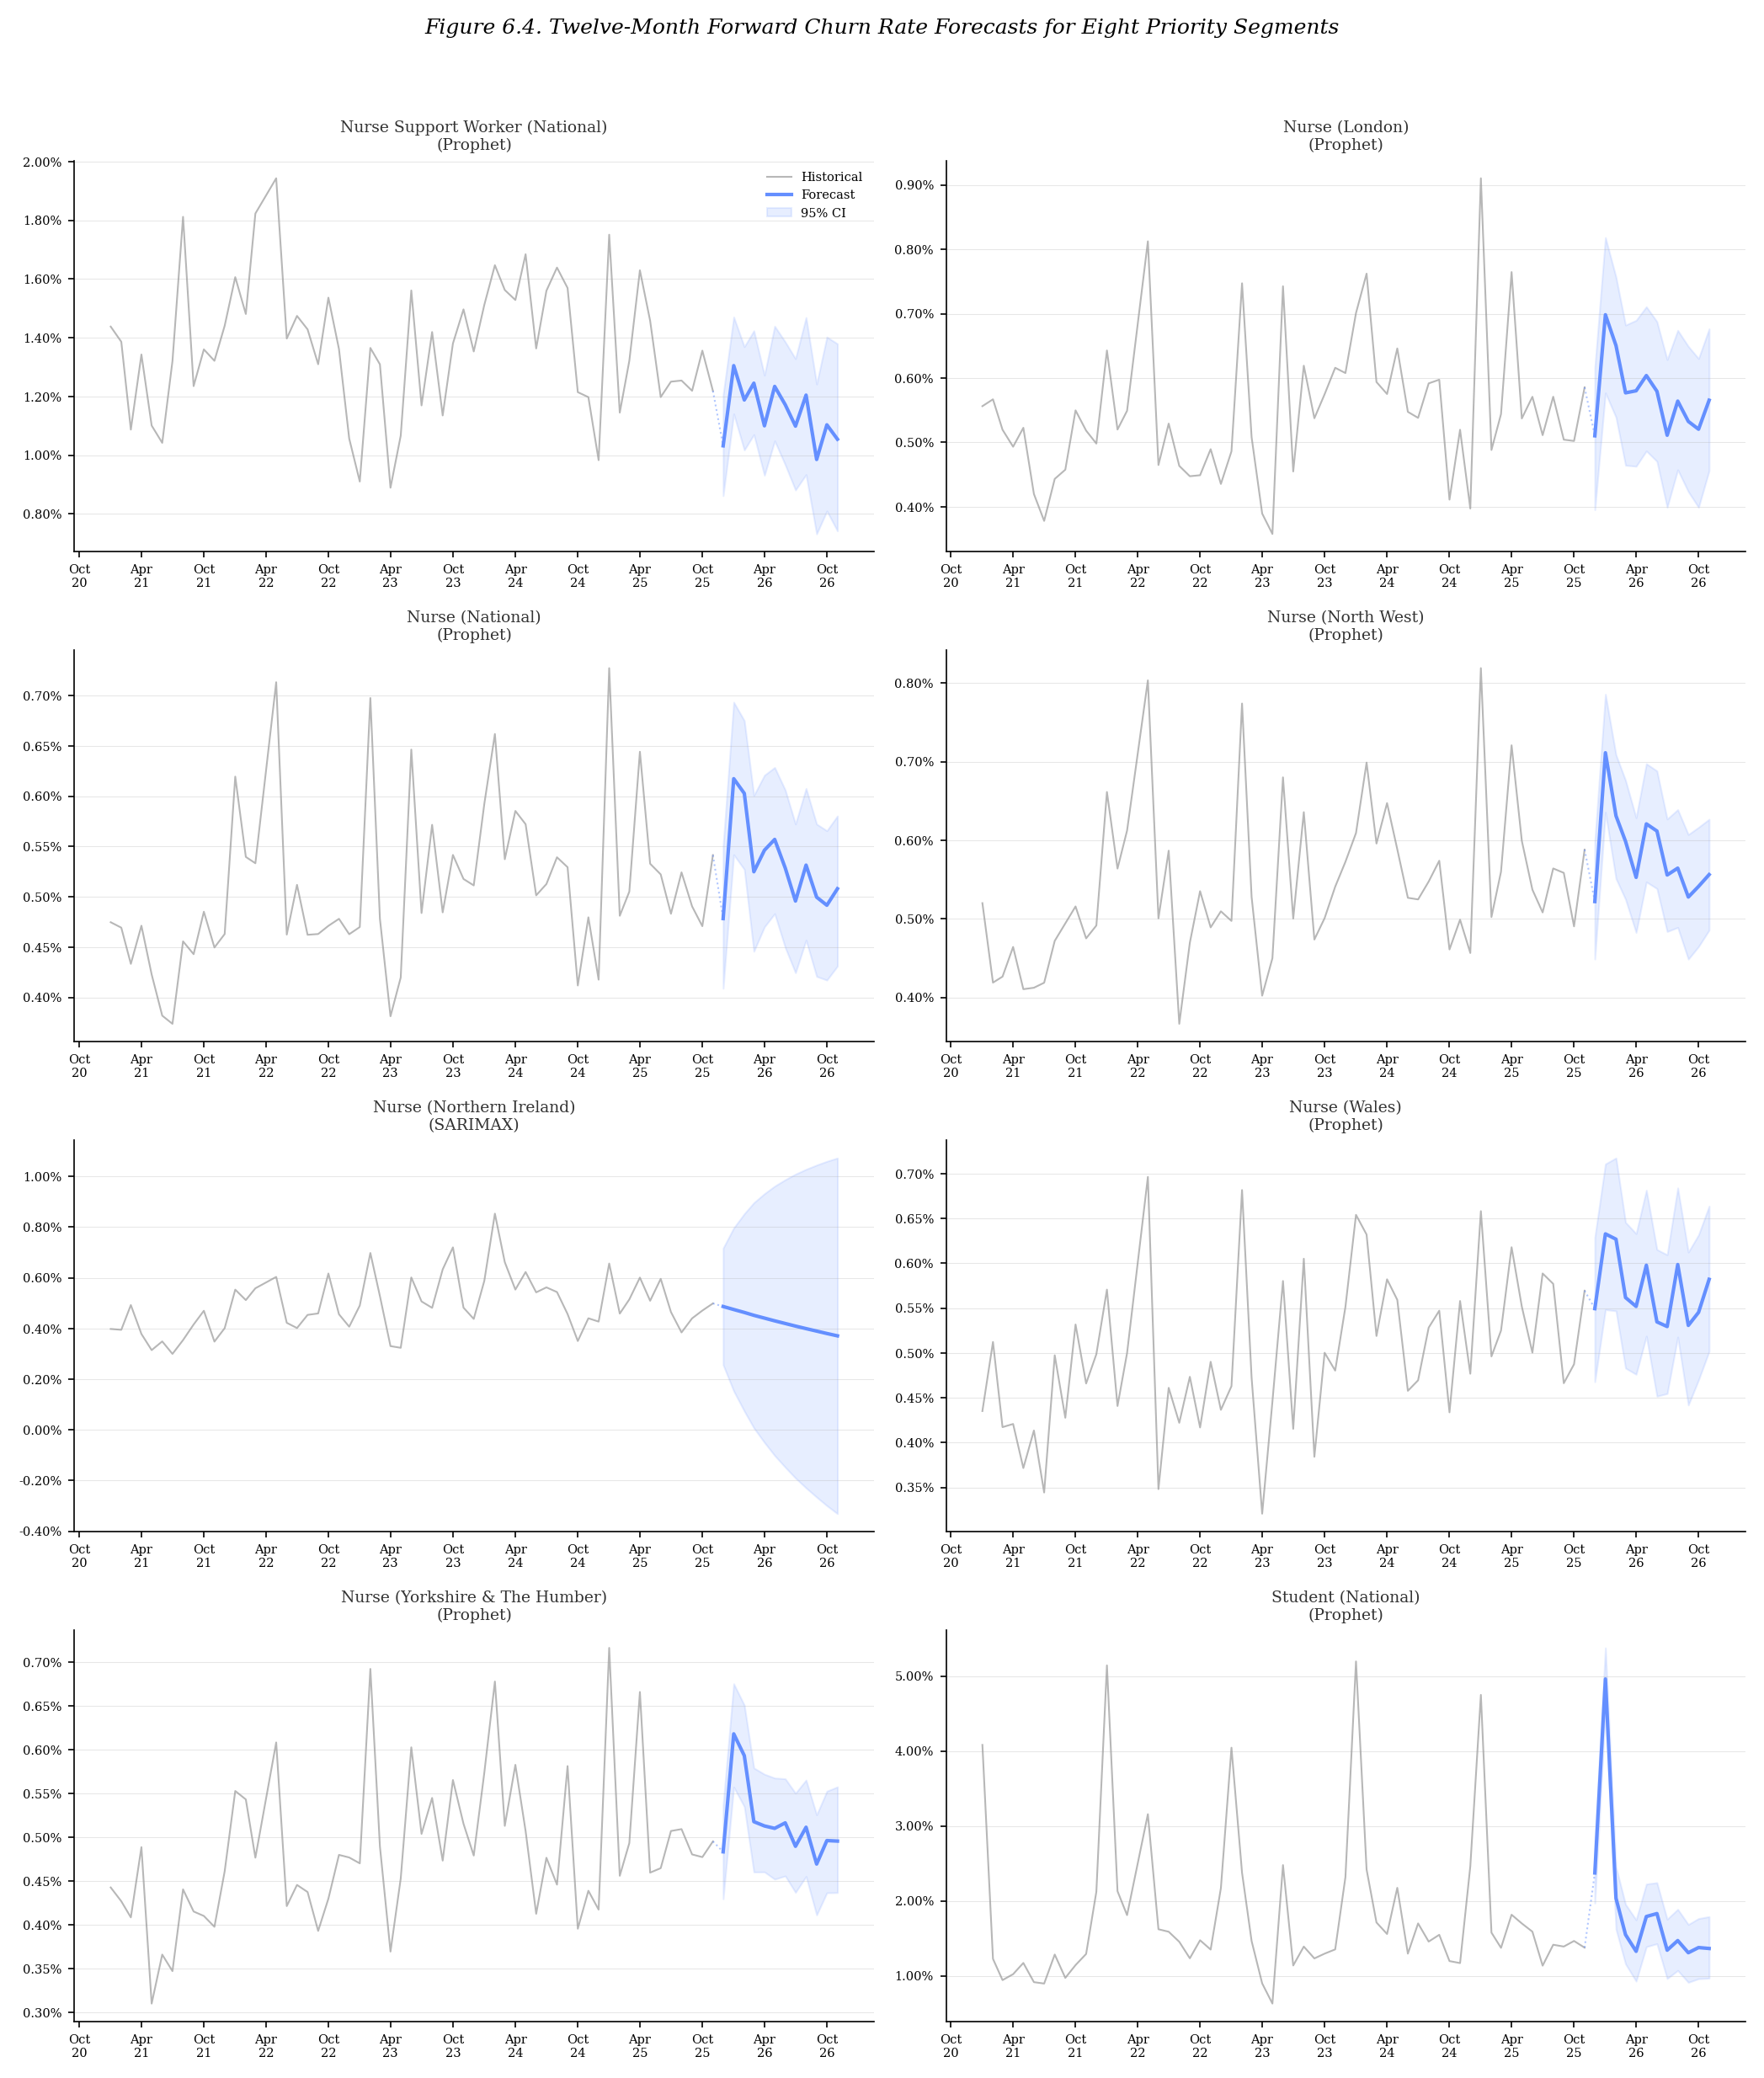

  ✓ Fig_6_4_forecast_panels.png (1228 KB, 300 DPI)


'/tmp/presentation_figures/Fig_6_4_forecast_panels.png'

In [0]:
# ═══════════════════════════════════════════════════════════════
# 5.4 Fig 6.4 | Chapter 6, Section 6.6 | Source: gold forecast_outputs
#                                         + gold monthly_churn_trends
# Prophet 12-Month Forward Forecasts for 8 Priority Segments
# ═══════════════════════════════════════════════════════════════

# ── Load forecast and historical data ──────────────────────────
df_forecast = gold["forecast_outputs"].toPandas()
df_trends = gold["monthly_churn_trends"].toPandas()

df_forecast["ds"] = pd.to_datetime(df_forecast["ds"])
df_trends["snapshot_date"] = pd.to_datetime(df_trends["snapshot_date"])

# ── Print segment inventory ────────────────────────────────────
segments = sorted(df_forecast["segment"].unique())
print(f"Forecast segments ({len(segments)}):")
for s in segments:
    method = df_forecast[df_forecast["segment"] == s]["method"].iloc[0]
    print(f"  {s:<40} {method}")

# ── Plot: 4x2 grid ────────────────────────────────────────────
fig, axes = plt.subplots(4, 2, figsize=(14, 16), sharex=False)
axes_flat = axes.flatten()

for i, segment in enumerate(segments):
    ax = axes_flat[i]

    # ── Historical ─────────────────────────────────────────────
    hist = df_trends[df_trends["segment"] == segment].sort_values("snapshot_date")
    ax.plot(
        hist["snapshot_date"], hist["churn_rate"],
        color=IBM_GREY, linewidth=1, alpha=0.7, label="Historical"
    )

    # ── Forecast ───────────────────────────────────────────────
    fcast = df_forecast[df_forecast["segment"] == segment].sort_values("ds")
    method = fcast["method"].iloc[0]

    ax.plot(
        fcast["ds"], fcast["predicted"],
        color=IBM_BLUE, linewidth=2, label="Forecast", zorder=3
    )

    # ── Prediction interval ────────────────────────────────────
    ax.fill_between(
        fcast["ds"], fcast["ci_lower"], fcast["ci_upper"],
        color=IBM_BLUE, alpha=0.15, label="95% CI"
    )

    # ── Connect historical to forecast ─────────────────────────
    if len(hist) > 0 and len(fcast) > 0:
        last_hist = hist.iloc[-1]
        first_fcast = fcast.iloc[0]
        ax.plot(
            [last_hist["snapshot_date"], first_fcast["ds"]],
            [last_hist["churn_rate"], first_fcast["predicted"]],
            color=IBM_BLUE, linewidth=1, linestyle=":", alpha=0.5
        )

    # ── Panel formatting ───────────────────────────────────────
    short_name = segment.replace("_", " ").replace("Nurse member", "Nurse")
    ax.set_title(f"{short_name}\n({method})", fontsize=9, color=IBM_BLACK)
    format_pct_axis(ax, axis="y", decimals=2)
    ax.tick_params(labelsize=7)
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b\n%y"))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=6))

    if i == 0:
        ax.legend(fontsize=7, loc="upper right")

fig.suptitle(
    "Figure 6.4. Twelve-Month Forward Churn Rate Forecasts "
    "for Eight Priority Segments",
    fontsize=12, style="italic", y=1.02
)

plt.tight_layout()
plt.show()
save_fig(fig, "Fig_6_4_forecast_panels.png")

### 5.5 Fig 6.5 | Chapter 6, Section 6.8

Revenue at Risk by Category
------------------------------------------------------------
Category                        Base       1.5x  % Total
------------------------------------------------------------
Nurse member              £ 439,583 £ 659,375   83.5%
Nurse Support Worker      £  66,435 £  99,652   12.6%
Student                   £  20,268 £  30,401    3.9%
------------------------------------------------------------
Total                     £ 526,285 £ 789,428

Top 5 segments by revenue at risk:
  London Nurse member 2. 25-34                  £  18,753
  London Nurse member 3. 35-44                  £  17,660
  North West Nurse member 2. 25-34              £  13,377
  North West Nurse member 3. 35-44              £  12,535
  South East Nurse member 3. 35-44              £  12,386


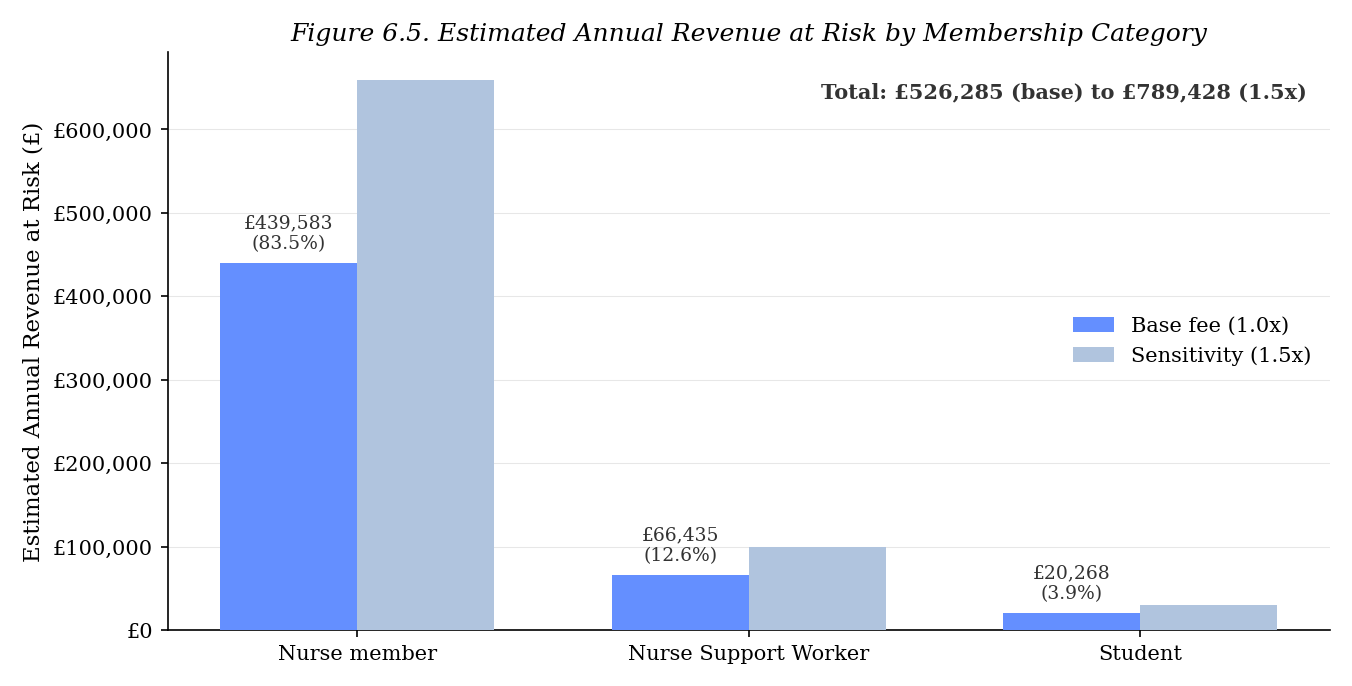

  ✓ Fig_6_5_revenue_at_risk.png (194 KB, 300 DPI)


'/tmp/presentation_figures/Fig_6_5_revenue_at_risk.png'

In [0]:
# ═══════════════════════════════════════════════════════════════
# 5.5 Fig 6.5 | Chapter 6, Section 6.8 | Source: gold revenue_at_risk
# Estimated Annual Revenue at Risk by Membership Category
# ═══════════════════════════════════════════════════════════════

# ── Aggregate revenue at risk by category ──────────────────────
df_rev = gold["revenue_at_risk"].toPandas()

cat_rev = (
    df_rev.groupby("MemCategory")
    .agg(
        est_annual_leavers=("est_annual_leavers", "sum"),
        revenue_base=("revenue_at_risk", "sum"),
    )
    .reindex(CATEGORY_ORDER)
)

cat_rev["annual_fee"] = cat_rev.index.map(ANNUAL_FEES)
cat_rev["revenue_15x"] = cat_rev["revenue_base"] * 1.5
cat_rev["pct_total"] = cat_rev["revenue_base"] / cat_rev["revenue_base"].sum() * 100

# ── Print cross-check ──────────────────────────────────────────
total_base = cat_rev["revenue_base"].sum()
total_15x = cat_rev["revenue_15x"].sum()

print("Revenue at Risk by Category")
print("-" * 60)
print(f"{'Category':<25} {'Base':>10} {'1.5x':>10} {'% Total':>8}")
print("-" * 60)
for cat in CATEGORY_ORDER:
    row = cat_rev.loc[cat]
    print(f"{cat:<25} £{row['revenue_base']:>8,.0f} £{row['revenue_15x']:>8,.0f} "
          f"{row['pct_total']:>6.1f}%")
print("-" * 60)
print(f"{'Total':<25} £{total_base:>8,.0f} £{total_15x:>8,.0f}")

# ── Top 5 segments ─────────────────────────────────────────────
top5 = df_rev.nlargest(5, "revenue_at_risk")
print(f"\nTop 5 segments by revenue at risk:")
for _, row in top5.iterrows():
    label = f"{row['Region']} {row['MemCategory']} {row['age_band']}"
    print(f"  {label:<45} £{row['revenue_at_risk']:>8,.0f}")

# ── Plot: grouped bar (base vs 1.5x) ──────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))

x = np.arange(len(CATEGORY_ORDER))
width = 0.35

bars_base = ax.bar(
    x - width/2, cat_rev["revenue_base"],
    width, color=IBM_BLUE, edgecolor="none", label="Base fee (1.0x)", zorder=3
)
bars_15x = ax.bar(
    x + width/2, cat_rev["revenue_15x"],
    width, color="#B0C4DE", edgecolor="none", label="Sensitivity (1.5x)", zorder=3
)

# ── Annotate base values ───────────────────────────────────────
for bar, cat in zip(bars_base, CATEGORY_ORDER):
    val = cat_rev.loc[cat, "revenue_base"]
    pct = cat_rev.loc[cat, "pct_total"]
    ax.annotate(
        f"£{val:,.0f}\n({pct:.1f}%)",
        xy=(bar.get_x() + bar.get_width() / 2, val),
        fontsize=9, ha="center", va="bottom", color=IBM_BLACK,
        xytext=(0, 5), textcoords="offset points"
    )

# ── Total annotation ───────────────────────────────────────────
ax.annotate(
    f"Total: £{total_base:,.0f} (base) to £{total_15x:,.0f} (1.5x)",
    xy=(0.98, 0.95), xycoords="axes fraction",
    fontsize=10, ha="right", va="top", color=IBM_BLACK,
    fontweight="bold"
)

ax.set_xticks(x)
ax.set_xticklabels(CATEGORY_ORDER)
ax.set_ylabel("Estimated Annual Revenue at Risk (£)")
ax.set_title(
    "Figure 6.5. Estimated Annual Revenue at Risk "
    "by Membership Category",
    fontsize=12, style="italic"
)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"£{v:,.0f}"))
ax.legend(loc="center right")

plt.show()
save_fig(fig, "Fig_6_5_revenue_at_risk.png")

### 5.6 Fig 6.6 | Chapter 6, Section 6.8

Total segments: 188
Categories: ['Nurse Support Worker', 'Nurse member', 'Student']

Top 5 by impact score:
Segment                                                Rate   Impact  Rate Rank
--------------------------------------------------------------------------------
London Nurse member 2. 25-34                       0.836%    15.27        120
London Nurse member 3. 35-44                       0.609%    14.38        133
Scotland Student 2. 25-34                          1.816%    11.86         23
North West Nurse member 2. 25-34                   0.673%    10.89        124
North West Student 2. 25-34                        1.978%    10.43         12


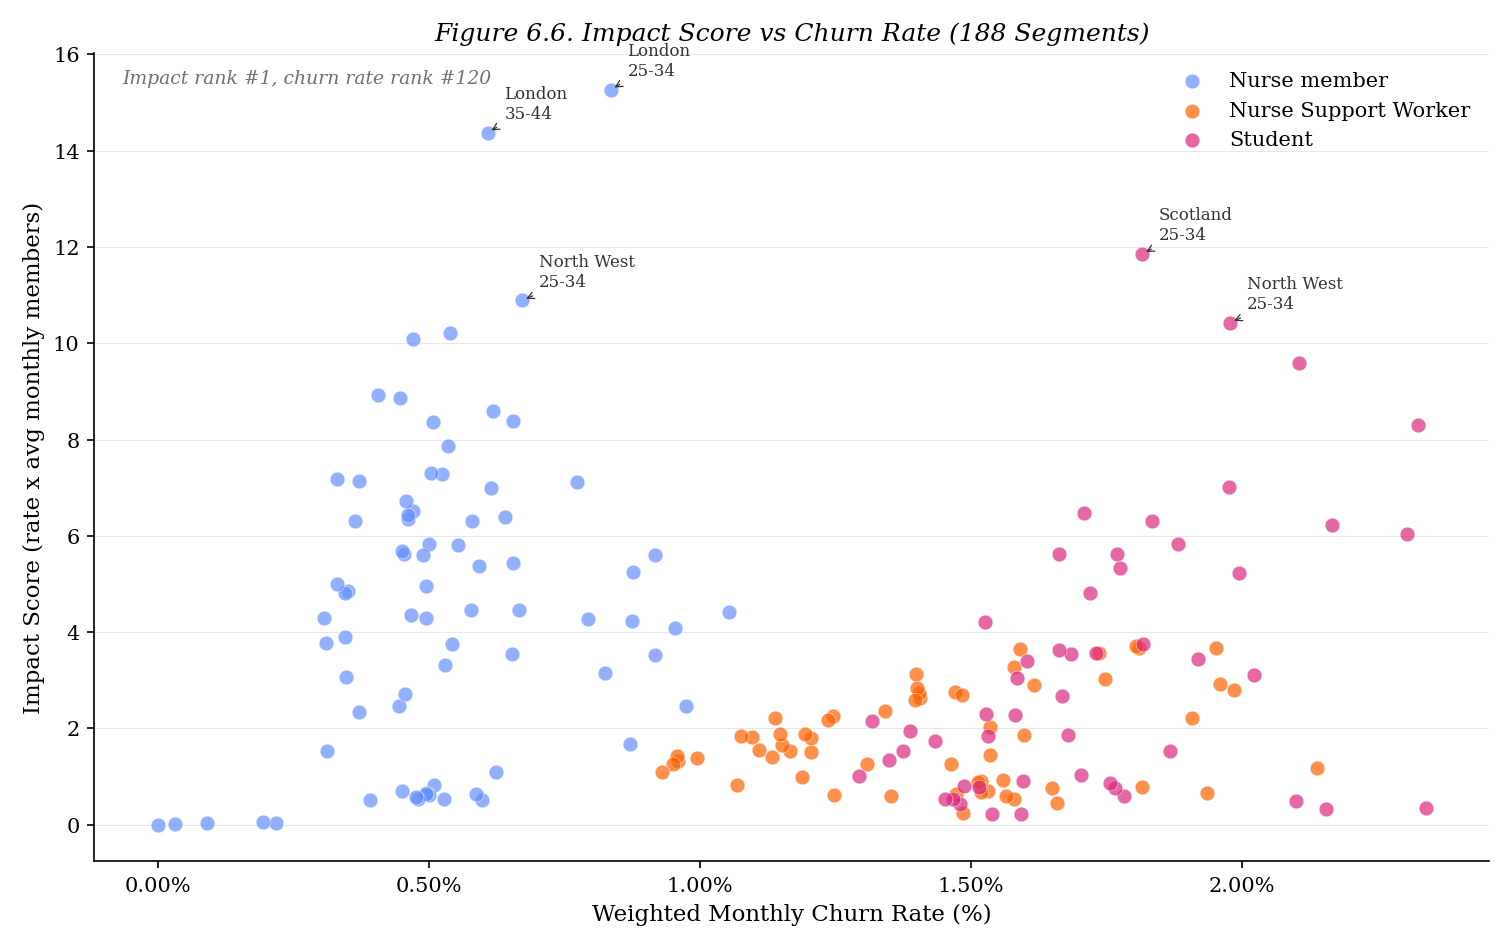

  ✓ Fig_6_6_impact_vs_rate.png (315 KB, 300 DPI)


'/tmp/presentation_figures/Fig_6_6_impact_vs_rate.png'

In [0]:
# ═══════════════════════════════════════════════════════════════
# 5.6 Fig 6.6 | Chapter 6, Section 6.8 | Source: gold risk_segmentation
# Impact Score vs Churn Rate for 188 Segments
# ═══════════════════════════════════════════════════════════════

# ── Load risk segmentation ─────────────────────────────────────
df_risk = gold["risk_segmentation"].toPandas()

# ── Print summary ──────────────────────────────────────────────
print(f"Total segments: {len(df_risk)}")
print(f"Categories: {sorted(df_risk['MemCategory'].unique())}")

# ── Top 5 by impact score ──────────────────────────────────────
top5 = df_risk.nlargest(5, "impact_score")
print(f"\nTop 5 by impact score:")
print(f"{'Segment':<50} {'Rate':>8} {'Impact':>8} {'Rate Rank':>10}")
print("-" * 80)
for _, row in top5.iterrows():
    label = f"{row['Region']} {row['MemCategory']} {row['age_band']}"
    print(f"{label:<50} {row['churn_rate']*100:.3f}% {row['impact_score']:>8.2f} "
          f"{row['rate_rank']:>10}")

# ── Plot ───────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 7))

# ── Scatter by category ────────────────────────────────────────
for cat in CATEGORY_ORDER:
    subset = df_risk[df_risk["MemCategory"] == cat]
    ax.scatter(
        subset["churn_rate"], subset["impact_score"],
        color=category_colour(cat), s=50, alpha=0.7,
        label=cat, edgecolors="white", linewidth=0.3, zorder=3
    )

# ── Label top 5 ────────────────────────────────────────────────
for _, row in top5.iterrows():
    # ── Clean age band label ───────────────────────────────────
    age = row["age_band"].split(". ", 1)[1] if ". " in str(row["age_band"]) else row["age_band"]
    label = f"{row['Region']}\n{age}"

    ax.annotate(
        label, xy=(row["churn_rate"], row["impact_score"]),
        fontsize=8, ha="left", va="bottom", color=IBM_BLACK,
        xytext=(8, 5), textcoords="offset points",
        arrowprops=dict(arrowstyle="->", color=IBM_BLACK, lw=0.6),
    )

# ── Annotate the key insight ───────────────────────────────────
top1 = top5.iloc[0]
ax.annotate(
    f"Impact rank #1, churn rate rank #{int(top1['rate_rank'])}",
    xy=(0.02, 0.98), xycoords="axes fraction",
    fontsize=9, ha="left", va="top", color=IBM_BLACK,
    style="italic", alpha=0.7
)

format_pct_axis(ax, axis="x", decimals=2)
ax.set_xlabel("Weighted Monthly Churn Rate (%)")
ax.set_ylabel("Impact Score (rate x avg monthly members)")
ax.set_title(
    "Figure 6.6. Impact Score vs Churn Rate (188 Segments)",
    fontsize=12, style="italic"
)
ax.legend(loc="upper right")

plt.show()
save_fig(fig, "Fig_6_6_impact_vs_rate.png")

## 6.0 Appendix Figures
Supporting figures that provide methodological evidence, diagnostic detail, or extended analysis referenced in the main body. Each figure is assessed for inclusion based on whether it adds information not already conveyed by the main body figures.

### 6.1 App A.1

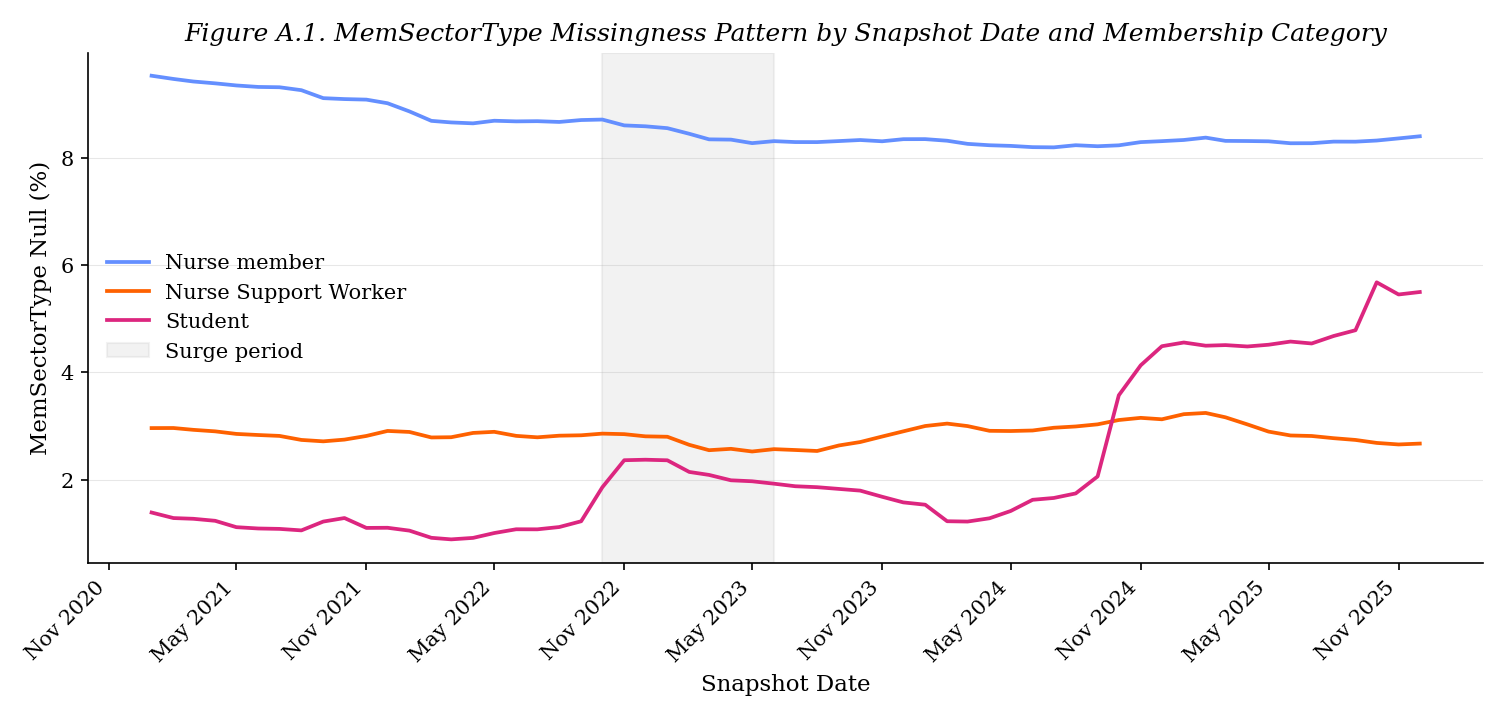

  ✓ App_A1_missingness_pattern.png (236 KB, 300 DPI)


'/tmp/presentation_figures/App_A1_missingness_pattern.png'

In [0]:
# ═══════════════════════════════════════════════════════════════
# 6.1 App A.1 | Appendix | Source: silver_churn
# Missingness Pattern by Snapshot Date and Category
# ═══════════════════════════════════════════════════════════════

# ── Compute missingness by snapshot and category ───────────────
df_miss = (
    silver_churn
    .groupBy("CM_snapshot_date", "MemCategory")
    .agg(
        F.count("*").alias("total_rows"),
        F.sum(F.isnull("MemSectorType").cast("int")).alias("sector_null"),
    )
    .withColumn("sector_pct", F.col("sector_null") / F.col("total_rows") * 100)
    .orderBy("CM_snapshot_date", "MemCategory")
    .toPandas()
)

df_miss["CM_snapshot_date"] = pd.to_datetime(df_miss["CM_snapshot_date"])

# ── Plot ───────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 5))

for cat in CATEGORY_ORDER:
    subset = df_miss[df_miss["MemCategory"] == cat].sort_values("CM_snapshot_date")
    ax.plot(
        subset["CM_snapshot_date"], subset["sector_pct"],
        color=category_colour(cat), linewidth=1.8, label=cat, zorder=3
    )

add_surge_shading(ax)

ax.set_xlabel("Snapshot Date")
ax.set_ylabel("MemSectorType Null (%)")
ax.set_title(
    "Figure A.1. MemSectorType Missingness Pattern "
    "by Snapshot Date and Membership Category",
    fontsize=12, style="italic"
)
ax.legend(loc="center left")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
fig.autofmt_xdate(rotation=45)

plt.show()
save_fig(fig, "App_A1_missingness_pattern.png")

### 6.2 App A.2 

Rows: 64
Segments: ['Age 55-64', 'Age 65+', 'North regions', 'Nurse member', 'Post-surge period', 'South regions', 'Student', 'Surge joiners']
Covariates: ['January flag', 'MemCategory', 'MemSectorType', 'North-South', 'Period', 'Surge cohort', 'age_band', 'tenure_band']


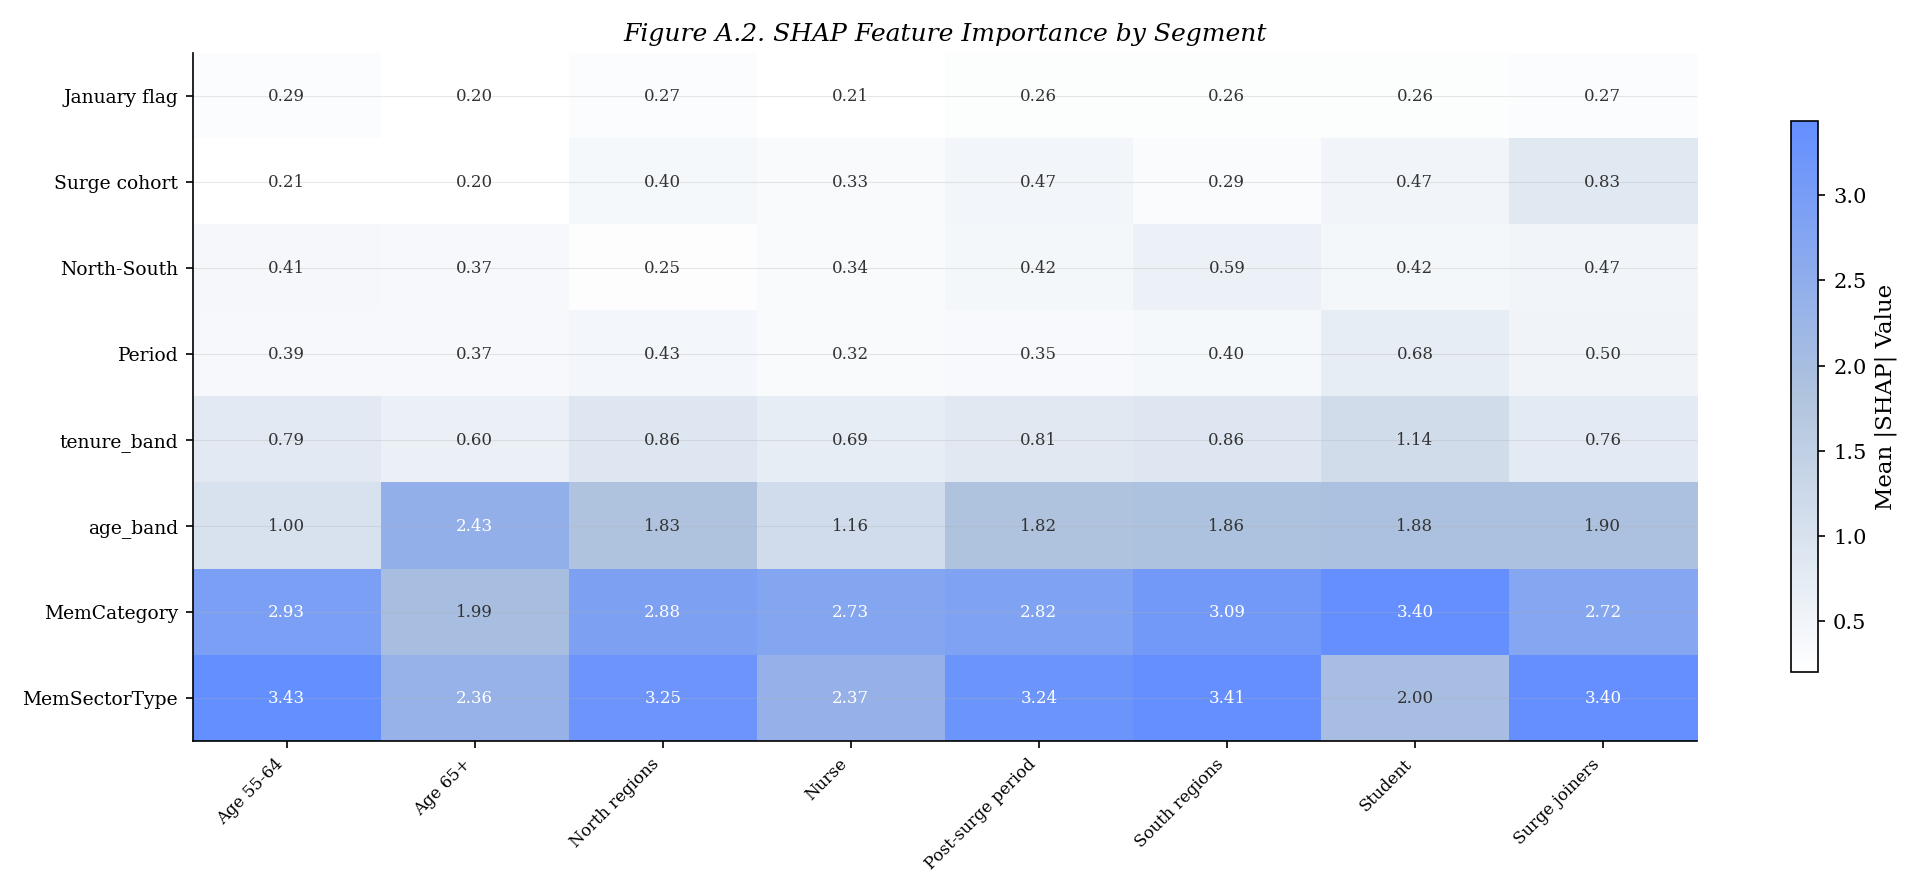

  ✓ App_A2_shap_segment_heatmap.png (313 KB, 300 DPI)


'/tmp/presentation_figures/App_A2_shap_segment_heatmap.png'

In [0]:
# ═══════════════════════════════════════════════════════════════
# 6.2 App A.2 | Appendix | Source: gold shap_segment_level
# SHAP Segment-Level Importance Heatmap
# ═══════════════════════════════════════════════════════════════

# ── Load segment-level SHAP ────────────────────────────────────
df_shap_seg = gold["shap_segment_level"].toPandas()

print(f"Rows: {len(df_shap_seg)}")
print(f"Segments: {sorted(df_shap_seg['Segment'].unique())}")
print(f"Covariates: {sorted(df_shap_seg['Covariate'].unique())}")

# ── Pivot: rows = covariates, cols = segments ──────────────────
pivot = df_shap_seg.pivot(
    index="Covariate", columns="Segment", values="Mean_Abs_SHAP"
)

# ── Sort covariates by overall importance (match Fig 6.3) ──────
covariate_order = (
    df_shap_seg.groupby("Covariate")["Mean_Abs_SHAP"]
    .mean()
    .sort_values(ascending=True)
    .index.tolist()
)
pivot = pivot.reindex(covariate_order)

# ── Clean segment labels ───────────────────────────────────────
clean_cols = [c.replace("Nurse member", "Nurse").replace("_", " ") 
              for c in pivot.columns]

# ── Plot ───────────────────────────────────────────────────────
import matplotlib.colors as mcolors

fig, ax = plt.subplots(figsize=(14, 6))

cmap = mcolors.LinearSegmentedColormap.from_list(
    "shap", ["white", "#B0C4DE", IBM_BLUE], N=256
)

im = ax.imshow(pivot.values, aspect="auto", cmap=cmap, interpolation="nearest")

# ── Annotate cell values ───────────────────────────────────────
for i in range(pivot.shape[0]):
    for j in range(pivot.shape[1]):
        val = pivot.values[i, j]
        text_colour = "white" if val > pivot.values.max() * 0.6 else IBM_BLACK
        ax.text(j, i, f"{val:.2f}", ha="center", va="center",
                fontsize=8, color=text_colour)

# ── Axes ───────────────────────────────────────────────────────
ax.set_xticks(np.arange(len(clean_cols)))
ax.set_xticklabels(clean_cols, fontsize=8, rotation=45, ha="right")
ax.set_yticks(np.arange(len(covariate_order)))
ax.set_yticklabels(covariate_order, fontsize=9)

# ── Colorbar ───────────────────────────────────────────────────
cbar = fig.colorbar(im, ax=ax, shrink=0.8, label="Mean |SHAP| Value")

ax.set_title(
    "Figure A.2. SHAP Feature Importance by Segment",
    fontsize=12, style="italic"
)

plt.tight_layout()
plt.show()
save_fig(fig, "App_A2_shap_segment_heatmap.png")

### 6.3 App A.3

Prophet vs SARIMAX RMSE Comparison
----------------------------------------------------------------------
Segment                                        Prophet  SARIMAX Winner  
----------------------------------------------------------------------
Nurse member (National)                       0.000221 0.000687 Prophet
Nurse member (Yorkshire & The Humber)         0.000232 0.000569 Prophet
Nurse member (London)                         0.000258 0.000732 Prophet
Nurse member (North West)                     0.000351 0.000995 Prophet
Nurse member (Wales)                          0.000511 0.000690 Prophet
Nurse member (Northern Ireland)               0.000682 0.000614 SARIMAX
Nurse Support Worker (National)               0.001254 0.001952 Prophet
Student (National)                            0.001418 0.006966 Prophet

Prophet wins: 7/8  |  SARIMAX wins: 1/8


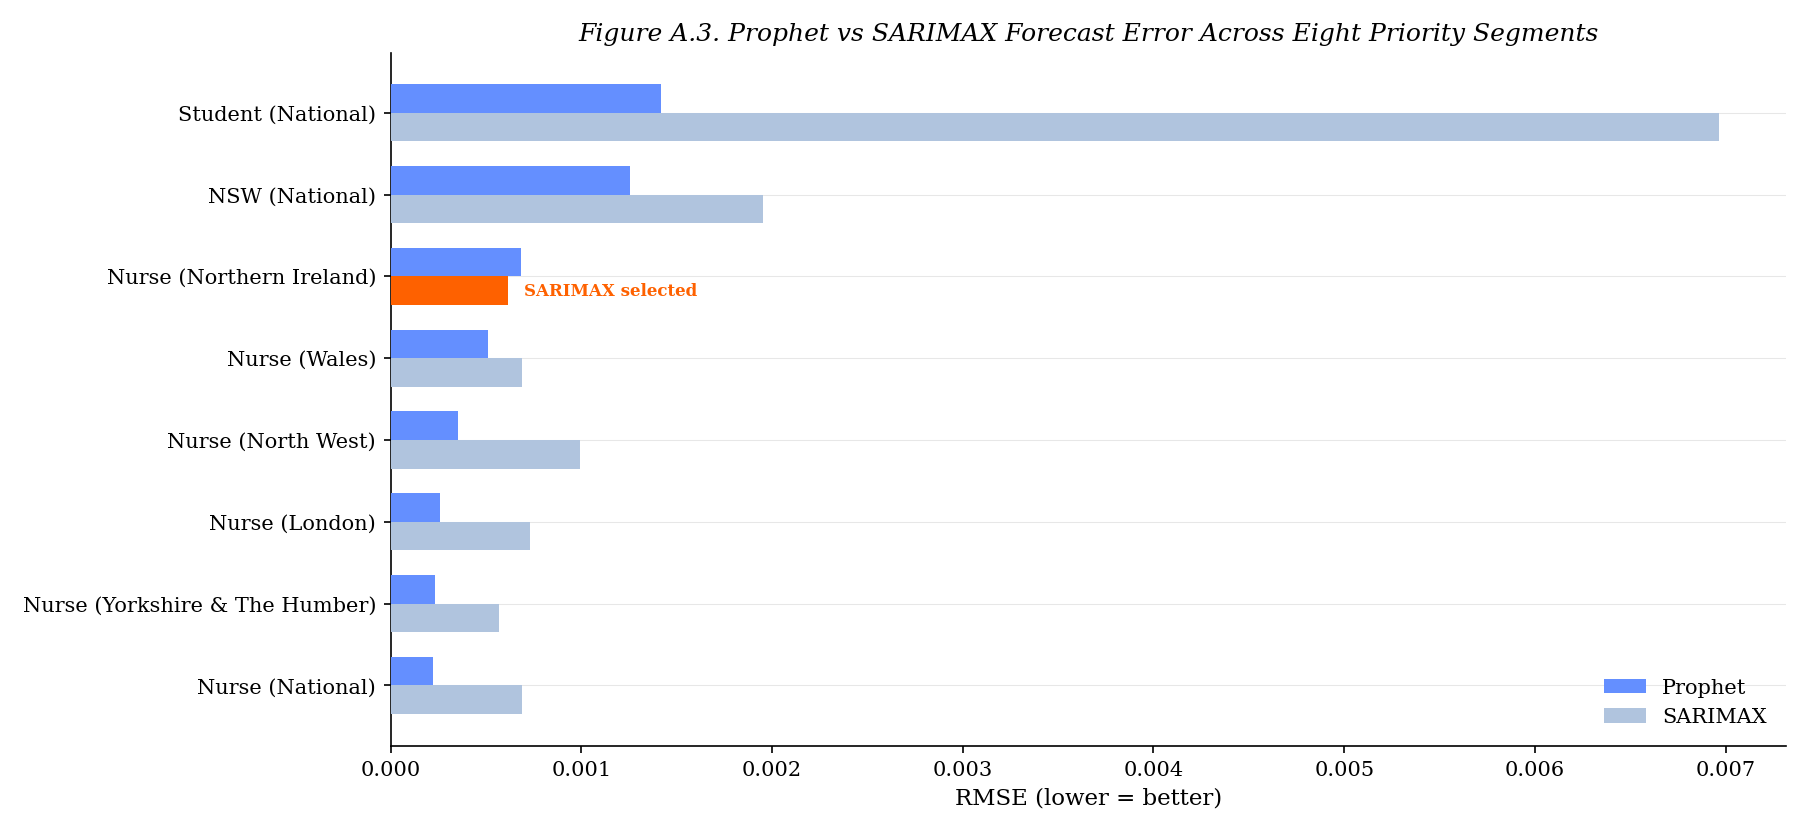

  ✓ App_A3_prophet_vs_sarimax.png (180 KB, 300 DPI)


'/tmp/presentation_figures/App_A3_prophet_vs_sarimax.png'

In [0]:
# ═══════════════════════════════════════════════════════════════
# 6.3 App A.3 | Appendix | Source: gold validation_metrics
# SARIMAX vs Prophet MAPE Comparison Across 8 Segments
# ═══════════════════════════════════════════════════════════════

# ── Load validation metrics ────────────────────────────────────
df_val = spark.read.parquet(GOLD_PATH + "validation_metrics/").toPandas()

# ── Sort by Prophet RMSE for visual ordering ───────────────────
df_val = df_val.sort_values("prophet_rmse", ascending=True).reset_index(drop=True)

# ── Clean segment labels ───────────────────────────────────────
df_val["label"] = (
    df_val["segment"]
    .str.replace("Nurse member", "Nurse", regex=False)
    .str.replace("Nurse Support Worker", "NSW", regex=False)
)

# ── Print comparison ───────────────────────────────────────────
print("Prophet vs SARIMAX RMSE Comparison")
print("-" * 70)
print(f"{'Segment':<45} {'Prophet':>8} {'SARIMAX':>8} {'Winner':<8}")
print("-" * 70)
for _, row in df_val.iterrows():
    print(f"{row['segment']:<45} {row['prophet_rmse']:.6f} "
          f"{row['sarimax_rmse']:.6f} {row['selected_method']}")

prophet_wins = (df_val["selected_method"] == "Prophet").sum()
sarimax_wins = (df_val["selected_method"] == "SARIMAX").sum()
print(f"\nProphet wins: {prophet_wins}/8  |  SARIMAX wins: {sarimax_wins}/8")

# ── Plot ───────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 6))

y = np.arange(len(df_val))
height = 0.35

bars_prophet = ax.barh(
    y + height/2, df_val["prophet_rmse"],
    height, color=IBM_BLUE, edgecolor="none", label="Prophet", zorder=3
)
bars_sarimax = ax.barh(
    y - height/2, df_val["sarimax_rmse"],
    height, color="#B0C4DE", edgecolor="none", label="SARIMAX", zorder=3
)

# ── Highlight Northern Ireland (SARIMAX winner) ────────────────
ni_idx = df_val[df_val["segment"].str.contains("Northern Ireland")].index
if len(ni_idx) > 0:
    ni = ni_idx[0]
    ax.barh(ni - height/2, df_val.loc[ni, "sarimax_rmse"],
            height, color=IBM_ORANGE, edgecolor="none", zorder=4)
    ax.annotate(
        "SARIMAX selected",
        xy=(df_val.loc[ni, "sarimax_rmse"], ni - height/2),
        fontsize=8, ha="left", va="center", color=IBM_ORANGE,
        xytext=(8, 0), textcoords="offset points",
        fontweight="bold"
    )

ax.set_yticks(y)
ax.set_yticklabels(df_val["label"])
ax.set_xlabel("RMSE (lower = better)")
ax.set_title(
    "Figure A.3. Prophet vs SARIMAX Forecast Error "
    "Across Eight Priority Segments",
    fontsize=12, style="italic"
)
ax.legend(loc="lower right")

plt.show()
save_fig(fig, "App_A3_prophet_vs_sarimax.png")

### 6.4 App A.4

Nurse Member Churn Rate by Age Band and Period
------------------------------------------------------------
  25-34           Pre: 0.6463%  Surge: 0.6268%  Post: 0.6520%
  35-44           Pre: 0.4833%  Surge: 0.4961%  Post: 0.5187%
  45-54           Pre: 0.3140%  Surge: 0.3509%  Post: 0.3599%
  55-64           Pre: 0.4164%  Surge: 0.4599%  Post: 0.4998%
  65 and over     Pre: 0.7956%  Surge: 0.7641%  Post: 0.9105%


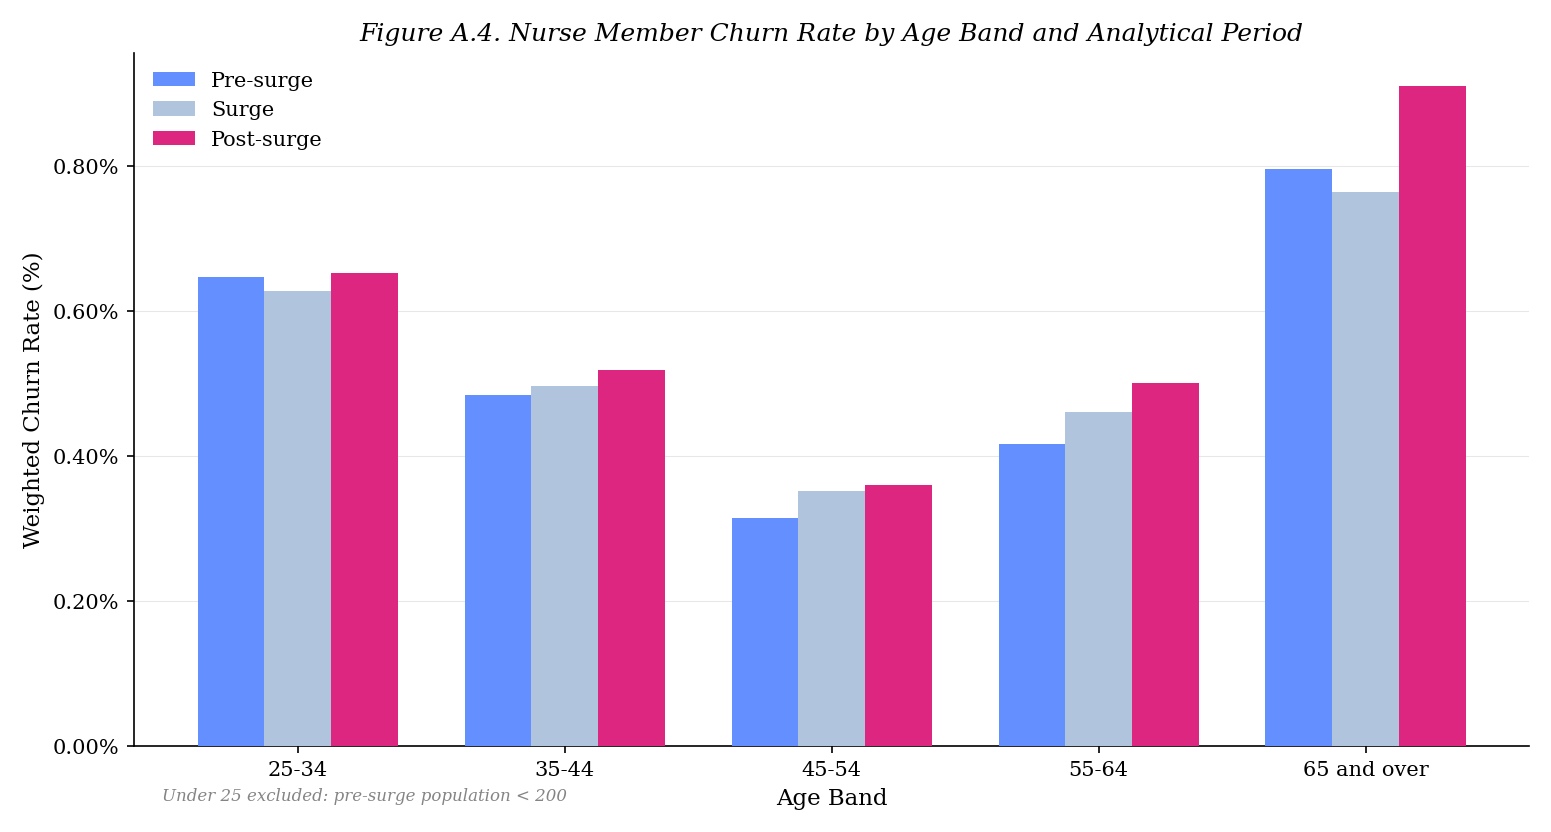

  ✓ App_A4_age_band_by_period.png (158 KB, 300 DPI)


'/tmp/presentation_figures/App_A4_age_band_by_period.png'

In [0]:
# ═══════════════════════════════════════════════════════════════
# 6.4 App A.4 | Appendix | Source: gold feature_engineered
# Mean Monthly Churn Rate by Age Band and Period
# ═══════════════════════════════════════════════════════════════

# ── Compute using NB07 method ──────────────────────────────────
df_age_monthly = (
    gold["feature_engineered"]
    .filter(
        (F.col("MemCategory") == "Nurse member") &
        (F.col("age_band").isin(AGE_ORDER))
    )
    .groupBy("CM_snapshot_date", "age_band")
    .agg(
        F.sum("q_leavers_t").alias("total_leavers"),
        F.sum("q_members_t").alias("total_members"),
    )
    .withColumn("churn_rate", F.col("total_leavers") / F.col("total_members"))
    .toPandas()
)

df_age_monthly["CM_snapshot_date"] = pd.to_datetime(df_age_monthly["CM_snapshot_date"])
df_age_monthly["period"] = df_age_monthly["CM_snapshot_date"].apply(
    lambda d: "Pre-surge" if d < pd.Timestamp(SURGE_START)
    else "Surge" if d <= pd.Timestamp(SURGE_END)
    else "Post-surge"
)

# ── Mean of monthly rates per age band per period ──────────────
df_age_period = (
    df_age_monthly
    .groupby(["age_band", "period"])["churn_rate"]
    .mean()
    .reset_index()
)

# ── Clean labels ───────────────────────────────────────────────
display_labels = {b: b.split(". ", 1)[1] if ". " in b else b for b in AGE_ORDER}
df_age_period["age_label"] = df_age_period["age_band"].map(display_labels)

# ── Print cross-check ──────────────────────────────────────────
pivot_check = df_age_period.pivot(
    index="age_band", columns="period", values="churn_rate"
).reindex(AGE_ORDER)[["Pre-surge", "Surge", "Post-surge"]]

print("Nurse Member Churn Rate by Age Band and Period")
print("-" * 60)
for band in AGE_ORDER:
    label = display_labels[band]
    pre = pivot_check.loc[band, "Pre-surge"]
    surge = pivot_check.loc[band, "Surge"]
    post = pivot_check.loc[band, "Post-surge"]
    print(f"  {label:<15} Pre: {pre*100:.4f}%  Surge: {surge*100:.4f}%  Post: {post*100:.4f}%")

# ── Plot: grouped bar ──────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(AGE_ORDER))
width = 0.25
period_order = ["Pre-surge", "Surge", "Post-surge"]
period_colours = [IBM_BLUE, "#B0C4DE", IBM_PINK]

for i, (period, colour) in enumerate(zip(period_order, period_colours)):
    rates = [
        df_age_period[
            (df_age_period["age_band"] == band) &
            (df_age_period["period"] == period)
        ]["churn_rate"].values[0]
        for band in AGE_ORDER
    ]
    bars = ax.bar(x + (i - 1) * width, rates, width,
                  color=colour, edgecolor="none", label=period, zorder=3)

format_pct_axis(ax, axis="y", decimals=2)
ax.set_xticks(x)
ax.set_xticklabels([display_labels[b] for b in AGE_ORDER])
ax.set_xlabel("Age Band")
ax.set_ylabel("Weighted Churn Rate (%)")
ax.set_title(
    "Figure A.4. Nurse Member Churn Rate by Age Band and Analytical Period",
    fontsize=12, style="italic"
)
ax.legend(loc="upper left")

# ── Under 25 exclusion note ────────────────────────────────────
ax.annotate(
    "Under 25 excluded: pre-surge population < 200",
    xy=(0.02, -0.08), xycoords="axes fraction",
    fontsize=8, color=IBM_BLACK, alpha=0.6, style="italic"
)

plt.show()
save_fig(fig, "App_A4_age_band_by_period.png")

### 6.5 App A.5

Segments: 8
  Age 25-34                                     36mo: 72.3%
  Age 45-54                                     36mo: 84.9%
  Age 55-64                                     36mo: 83.0%
  Age 65+                                       36mo: 72.8%
  Non-surge joiner                              36mo: 81.8%
  North region                                  36mo: 77.8%
  South region                                  36mo: 80.5%
  Surge joiner                                  36mo: 65.5%


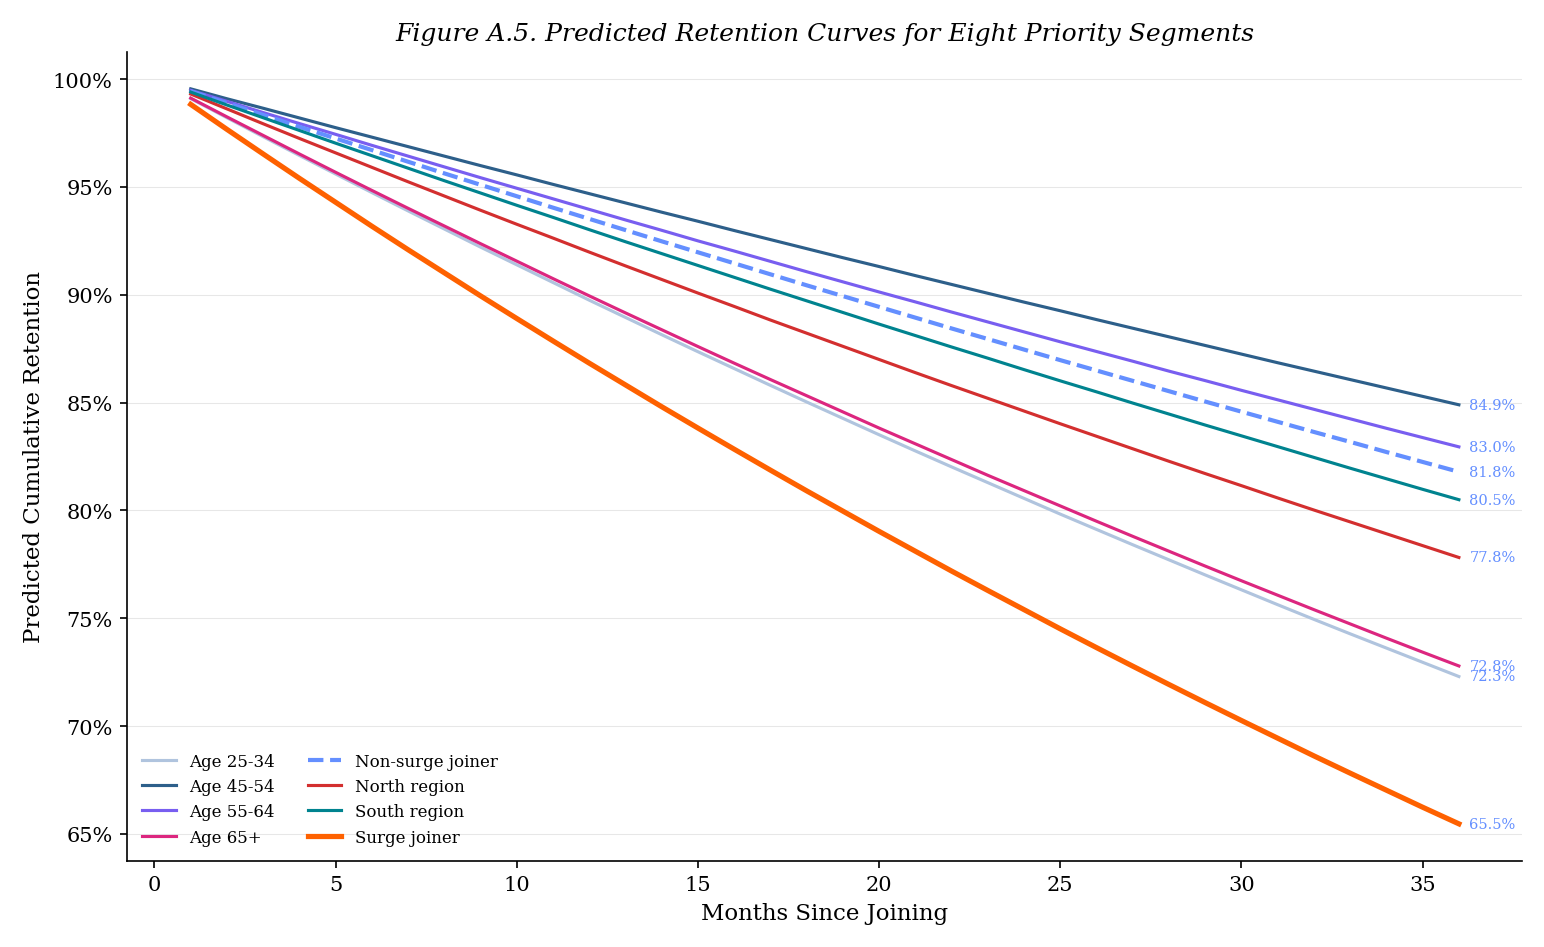

  ✓ App_A5_predicted_retention.png (429 KB, 300 DPI)


'/tmp/presentation_figures/App_A5_predicted_retention.png'

In [0]:
# ═══════════════════════════════════════════════════════════════
# 6.5 App A.5 | Appendix | Source: gold predicted_retention
# Predicted Retention Curves for 8 Priority Segments
# ═══════════════════════════════════════════════════════════════

# ── Load predicted retention ───────────────────────────────────
df_ret = gold["predicted_retention"].toPandas()

segments = sorted(df_ret["Segment"].unique())
print(f"Segments: {len(segments)}")
for s in segments:
    final = df_ret[df_ret["Segment"] == s].sort_values("Month").iloc[-1]
    print(f"  {s:<45} {final['Month']}mo: {final['Cumulative_Retention']*100:.1f}%")

# ── Distinct colours and styles per segment ────────────────────
seg_styles = {}
blues = ["#1a3a5c", "#2d5f8a", "#648FFF", "#89a8d0", "#b0c4de"]
pinks = [IBM_PINK]
oranges = [IBM_ORANGE]

for i, s in enumerate(segments):
    if "Surge" in s:
        seg_styles[s] = {"color": IBM_ORANGE, "linestyle": "-", "linewidth": 2.5}
    elif "Non-surge" in s:
        seg_styles[s] = {"color": IBM_BLUE, "linestyle": "--", "linewidth": 2}
    elif "North" in s:
        seg_styles[s] = {"color": RISK_RED, "linestyle": "-", "linewidth": 1.5}
    elif "South" in s:
        seg_styles[s] = {"color": RISK_CYAN, "linestyle": "-", "linewidth": 1.5}
    elif "65" in s:
        seg_styles[s] = {"color": IBM_PINK, "linestyle": "-", "linewidth": 1.5}
    elif "55" in s:
        seg_styles[s] = {"color": RISK_PURPLE, "linestyle": "-", "linewidth": 1.5}
    elif "45" in s:
        seg_styles[s] = {"color": "#2d5f8a", "linestyle": "-", "linewidth": 1.5}
    elif "25" in s:
        seg_styles[s] = {"color": "#b0c4de", "linestyle": "-", "linewidth": 1.5}
    else:
        seg_styles[s] = {"color": IBM_GREY, "linestyle": "-", "linewidth": 1}

# ── Plot ───────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 7))

for s in segments:
    subset = df_ret[df_ret["Segment"] == s].sort_values("Month")
    short = (s.replace("Nurse member", "Nurse")
              .replace("Nurse Support Worker", "NSW"))
    style = seg_styles[s]
    ax.plot(
        subset["Month"], subset["Cumulative_Retention"],
        color=style["color"], linestyle=style["linestyle"],
        linewidth=style["linewidth"], label=short, zorder=3
    )

    # ── Annotate endpoint ──────────────────────────────────────
    last = subset.iloc[-1]
    ax.annotate(
        f"{last['Cumulative_Retention']*100:.1f}%",
        xy=(last["Month"], last["Cumulative_Retention"]),
        fontsize=7, ha="left", va="center", color=seg_colours[s],
        xytext=(5, 0), textcoords="offset points"
    )

format_pct_axis(ax, axis="y", decimals=0)
ax.set_xlabel("Months Since Joining")
ax.set_ylabel("Predicted Cumulative Retention")
ax.set_title(
    "Figure A.5. Predicted Retention Curves for Eight Priority Segments",
    fontsize=12, style="italic"
)
ax.legend(loc="lower left", fontsize=8, ncol=2)

plt.show()
save_fig(fig, "App_A5_predicted_retention.png")

### 6.6 App A.6

Segments per Category per Tier
--------------------------------------------------
  Nurse member              Low: 63   Med: 14   High: 0
  Nurse Support Worker      Low: 0    Med: 37   High: 23
  Student                   Low: 0    Med: 11   High: 40


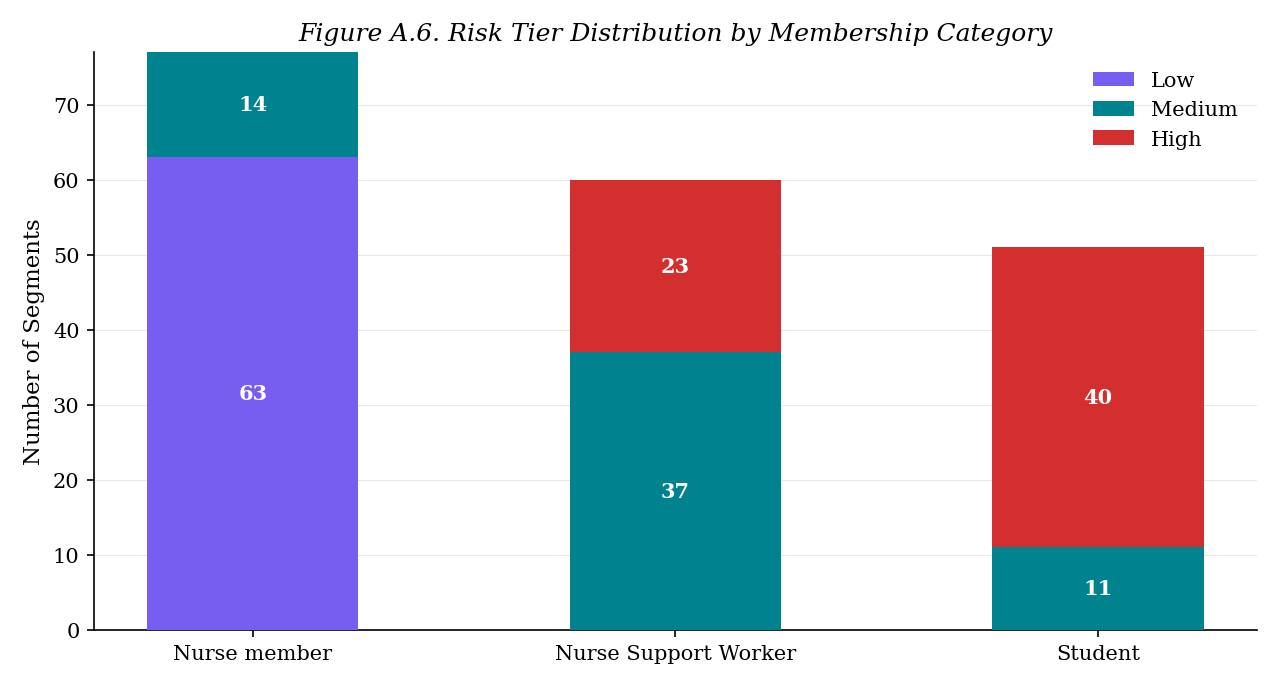

  ✓ App_A6_risk_tier_distribution.png (112 KB, 300 DPI)


'/tmp/presentation_figures/App_A6_risk_tier_distribution.png'

In [0]:
# ═══════════════════════════════════════════════════════════════
# 6.6 App A.6 | Appendix | Source: gold risk_segmentation
# Risk Tier Distribution by Membership Category
# ═══════════════════════════════════════════════════════════════

# ── Count segments per category per tier ───────────────────────
df_tier = gold["risk_segmentation"].toPandas()

tier_cat = (
    df_tier.groupby(["MemCategory", "risk_tier"])
    .size()
    .reset_index(name="count")
)

# ── Print summary ──────────────────────────────────────────────
print("Segments per Category per Tier")
print("-" * 50)
pivot_tc = tier_cat.pivot(index="MemCategory", columns="risk_tier", values="count").fillna(0).astype(int)
pivot_tc = pivot_tc.reindex(CATEGORY_ORDER)[["Low", "Medium", "High"]]
for cat in CATEGORY_ORDER:
    row = pivot_tc.loc[cat]
    print(f"  {cat:<25} Low: {row['Low']:<4} Med: {row['Medium']:<4} High: {row['High']}")

# ── Plot: stacked bar ──────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))

x = np.arange(len(CATEGORY_ORDER))
width = 0.5
tier_order = ["Low", "Medium", "High"]
tier_colours_list = [RISK_PURPLE, RISK_CYAN, RISK_RED]

bottom = np.zeros(len(CATEGORY_ORDER))
for tier, colour in zip(tier_order, tier_colours_list):
    values = [pivot_tc.loc[cat, tier] for cat in CATEGORY_ORDER]
    bars = ax.bar(x, values, width, bottom=bottom,
                  color=colour, edgecolor="none", label=tier, zorder=3)

    # ── Annotate count inside bar ──────────────────────────────
    for i, val in enumerate(values):
        if val > 0:
            ax.text(i, bottom[i] + val / 2, str(int(val)),
                    ha="center", va="center", fontsize=10,
                    color="white", fontweight="bold")

    bottom += values

ax.set_xticks(x)
ax.set_xticklabels(CATEGORY_ORDER)
ax.set_ylabel("Number of Segments")
ax.set_title(
    "Figure A.6. Risk Tier Distribution by Membership Category",
    fontsize=12, style="italic"
)
ax.legend(loc="upper right")

plt.show()
save_fig(fig, "App_A6_risk_tier_distribution.png")

### 6.7 App A.7

Manual risk summary (NB06):
  Rows: 31
  Columns: ['Dimension', 'Segment', 'Overall_Churn_Pct', 'PreSurge_Churn_Pct', 'PostSurge_Churn_Pct', 'PostSurge_Uplift_Pct', 'Risk_Type', 'Intervention_Priority']

Model risk segmentation (NB08):
  Rows: 188

Manual classifications:
------------------------------------------------------------
Dimension       Segment                        Risk Type       Priority
------------------------------------------------------------
Cross-Segment   NSW x 65 and over              Deterioration   High
Cross-Segment   Nurse member x NHS             Deterioration   High
Cross-Segment   Student x January              Structural      Low
Cross-Segment   Surge cohorts at 24mo          Deterioration   Medium
Sector          Independent                    Structural      Low
Sector          Other Public Sector            Structural      Low
Sector          NHS                            Deterioration   High
Cross-Segment   Nurse member x 55-64           Deteriorati

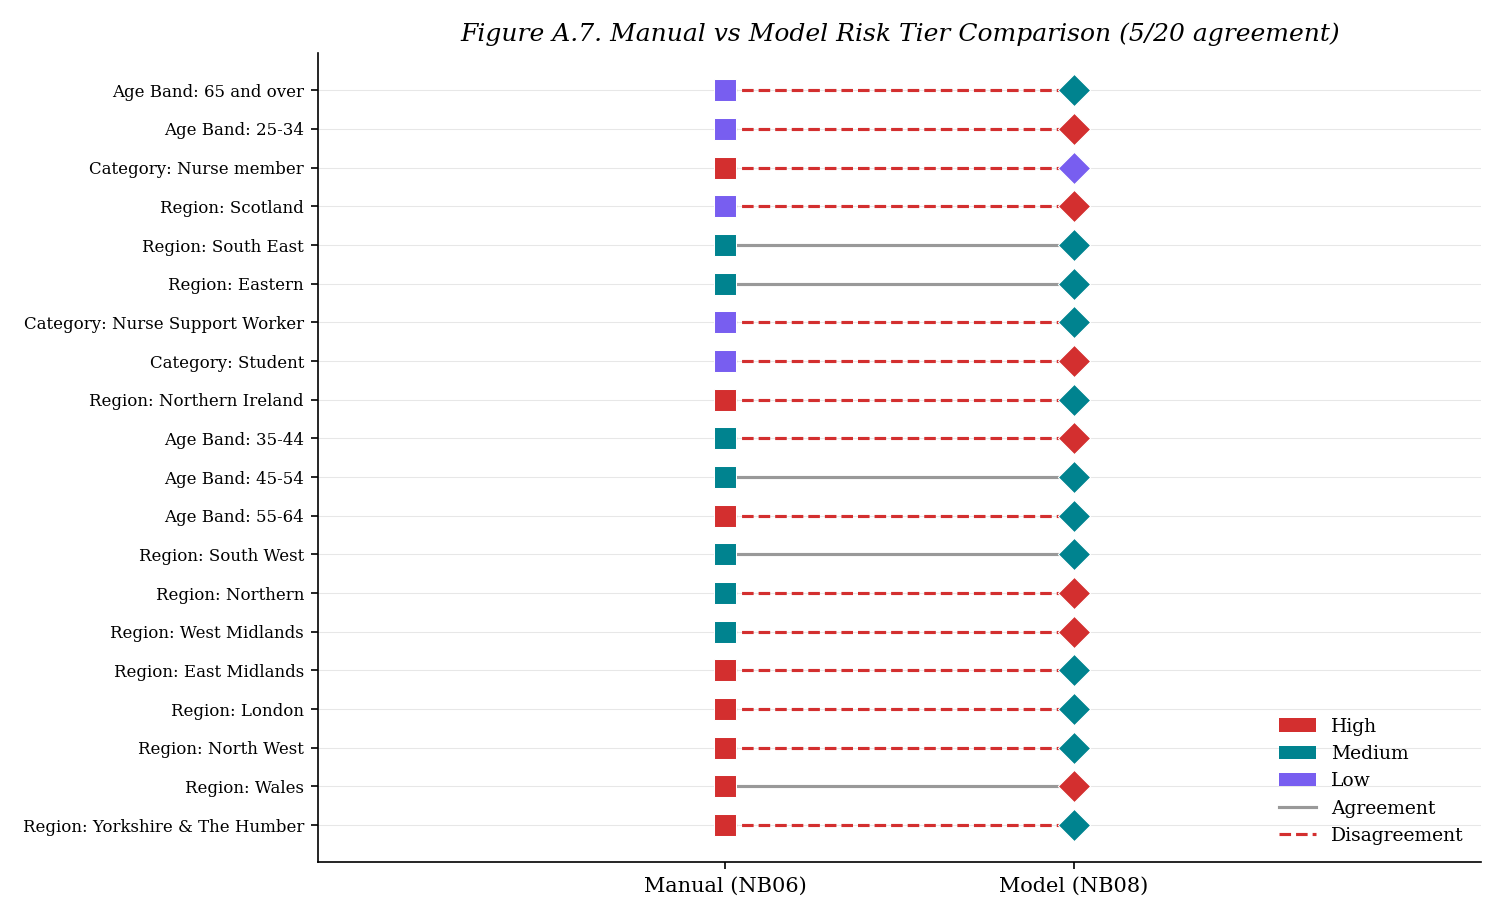

  ✓ App_A7_model_vs_manual.png (283 KB, 300 DPI)


'/tmp/presentation_figures/App_A7_model_vs_manual.png'

In [0]:
# ═══════════════════════════════════════════════════════════════
# 6.7 App A.7 | Appendix | Source: gold churn_risk_summary
#                                   + gold risk_segmentation
# Model vs Manual Risk Tier Comparison
# ═══════════════════════════════════════════════════════════════

# ── Load both tables ───────────────────────────────────────────
df_manual = gold["churn_risk_summary"].toPandas()
df_model = gold["risk_segmentation"].toPandas()

print("Manual risk summary (NB06):")
print(f"  Rows: {len(df_manual)}")
print(f"  Columns: {list(df_manual.columns)}")
print(f"\nModel risk segmentation (NB08):")
print(f"  Rows: {len(df_model)}")

# ── Print manual classifications ───────────────────────────────
print("\nManual classifications:")
print("-" * 60)
print(f"{'Dimension':<15} {'Segment':<30} {'Risk Type':<15} {'Priority'}")
print("-" * 60)
for _, row in df_manual.iterrows():
    print(f"{row['Dimension']:<15} {row['Segment']:<30} "
          f"{row['Risk_Type']:<15} {row['Intervention_Priority']}")

# ── Compare where possible ─────────────────────────────────────
# Manual is by dimension (Region, Category, Age Band)
# Model is by segment (Region x Category x Age Band)
# Direct join isn't possible — compare at the dimension level

print("\nModel tier distribution by dimension:")
for dim, col in [("Category", "MemCategory"), ("Region", "Region")]:
    print(f"\n  {dim}:")
    tier_counts = (
        df_model.groupby([col, "risk_tier"])
        .size()
        .unstack(fill_value=0)
    )
    if "High" not in tier_counts.columns:
        tier_counts["High"] = 0
    tier_counts = tier_counts[["Low", "Medium", "High"]]
    for idx in tier_counts.index:
        row = tier_counts.loc[idx]
        dominant = row.idxmax()
        print(f"    {idx:<30} L:{row['Low']:<3} M:{row['Medium']:<3} "
              f"H:{row['High']:<3} (dominant: {dominant})")

# ── Visualise: manual vs model agreement ───────────────────────
# Map manual Risk_Type to comparable tiers
manual_map = {"High Churn": "High", "Escalating": "High",
              "Stable High": "High", "Moderate": "Medium",
              "Stable Low": "Low", "Low Churn": "Low",
              "Improving": "Low"}

df_manual["mapped_tier"] = df_manual["Intervention_Priority"]

# ── Build comparison for categories and priority regions ───────
comparison = []
for _, row in df_manual.iterrows():
    dim = row["Dimension"]
    seg = row["Segment"]
    manual_tier = row["mapped_tier"]

    if dim == "Category":
        model_sub = df_model[df_model["MemCategory"] == seg]
    elif dim == "Region":
        model_sub = df_model[df_model["Region"] == seg]
    elif dim == "Age Band":
        model_sub = df_model[df_model["age_band"].str.contains(seg, na=False)]
    else:
        continue

    if len(model_sub) > 0:
        model_dominant = model_sub["risk_tier"].value_counts().idxmax()
        agreement = "Agree" if manual_tier == model_dominant else "Disagree"
        comparison.append({
            "Dimension": dim, "Segment": seg,
            "Manual": manual_tier, "Model": model_dominant,
            "Agreement": agreement
        })

df_comp = pd.DataFrame(comparison)

agree_count = (df_comp["Agreement"] == "Agree").sum()
total = len(df_comp)
print(f"\n\nAgreement: {agree_count}/{total} ({agree_count/total*100:.0f}%)")

# ── Plot comparison ────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 7))

y = np.arange(len(df_comp))

tier_to_colour = {"High": RISK_RED, "Medium": RISK_CYAN, "Low": RISK_PURPLE}

for i, (_, row) in enumerate(df_comp.iterrows()):
    # ── Manual (left dot) ──────────────────────────────────────
    ax.scatter(-0.15, i, color=tier_to_colour.get(row["Manual"], IBM_GREY),
               s=120, marker="s", zorder=4, edgecolors="white", linewidth=0.5)

    # ── Model (right dot) ──────────────────────────────────────
    ax.scatter(0.15, i, color=tier_to_colour.get(row["Model"], IBM_GREY),
               s=120, marker="D", zorder=4, edgecolors="white", linewidth=0.5)

    # ── Connecting line ────────────────────────────────────────
    line_colour = IBM_GREY if row["Agreement"] == "Agree" else RISK_RED
    line_style = "-" if row["Agreement"] == "Agree" else "--"
    ax.plot([-0.15, 0.15], [i, i], color=line_colour,
            linewidth=1.5, linestyle=line_style, zorder=2)

ax.set_yticks(y)
ax.set_yticklabels([f"{row['Dimension']}: {row['Segment']}" 
                     for _, row in df_comp.iterrows()], fontsize=8)
ax.set_xticks([-0.15, 0.15])
ax.set_xticklabels(["Manual (NB06)", "Model (NB08)"], fontsize=10)
ax.set_xlim(-0.5, 0.5)

# ── Legend ──────────────────────────────────────────────────────
legend_elements = [
    Patch(facecolor=RISK_RED, label="High"),
    Patch(facecolor=RISK_CYAN, label="Medium"),
    Patch(facecolor=RISK_PURPLE, label="Low"),
    Line2D([0], [0], color=IBM_GREY, linewidth=1.5, label="Agreement"),
    Line2D([0], [0], color=RISK_RED, linewidth=1.5, linestyle="--", label="Disagreement"),
]
ax.legend(handles=legend_elements, loc="lower right", fontsize=9)

ax.set_title(
    f"Figure A.7. Manual vs Model Risk Tier Comparison "
    f"({agree_count}/{total} agreement)",
    fontsize=12, style="italic"
)

plt.show()
save_fig(fig, "App_A7_model_vs_manual.png")

### 6.8 Table B.1

In [0]:
# ═══════════════════════════════════════════════════════════════
# 6.8 Table B.1 | Appendix | Source: gold risk_segmentation
# Complete 188-Segment Risk Register
# ═══════════════════════════════════════════════════════════════

# ── Load and sort ──────────────────────────────────────────────
df_register = gold["risk_segmentation"].toPandas()
df_register["age_band"] = df_register["age_band"].apply(
    lambda x: x.split(". ", 1)[1] if ". " in str(x) else x
)
df_register = df_register.sort_values("churn_rate", ascending=False).reset_index(drop=True)
df_register.index = df_register.index + 1
df_register.index.name = "Rank"

# ── View 1: Tier summary ───────────────────────────────────────
print("Risk Tier Summary")
print("-" * 60)
for tier in ["High", "Medium", "Low"]:
    subset = df_register[df_register["risk_tier"] == tier]
    cats = subset["MemCategory"].value_counts()
    rate_range = f"{subset['churn_rate'].min()*100:.3f}% – {subset['churn_rate'].max()*100:.3f}%"
    print(f"\n  {tier} ({len(subset)} segments, rate range: {rate_range})")
    for cat, count in cats.items():
        print(f"    {cat:<25} {count} segments")

# ── View 2: Top 5 per tier ─────────────────────────────────────
print("\n\nTop 5 Segments per Risk Tier")
print("-" * 80)
for tier in ["High", "Medium", "Low"]:
    subset = df_register[df_register["risk_tier"] == tier].head(5)
    print(f"\n  {tier} Tier:")
    print(f"  {'Segment':<45} {'Rate':>8} {'Impact':>8}")
    for _, row in subset.iterrows():
        label = f"{row['Region']} {row['MemCategory']} {row['age_band']}"
        print(f"  {label:<45} {row['churn_rate']*100:.3f}% {row['impact_score']:>7.2f}")

# ── View 3: Full interactive table in Databricks ───────────────
display(
    spark.createDataFrame(
        df_register[["Region", "MemCategory", "age_band", "churn_rate",
                      "avg_monthly_members", "impact_score", "risk_tier",
                      "rate_rank", "impact_rank", "rank_shift"]].reset_index()
    ).orderBy("Rank")
)

# ── Export CSV ─────────────────────────────────────────────────
csv_path = TABLE_DIR + "Table_B1_risk_register.csv"
df_register.to_csv(csv_path)
print(f"\nExported: {csv_path} ({len(df_register)} rows)")

Risk Tier Summary
------------------------------------------------------------

  High (63 segments, rate range: 1.525% – 2.339%)
    Student                   40 segments
    Nurse Support Worker      23 segments

  Medium (62 segments, rate range: 0.666% – 1.519%)
    Nurse Support Worker      37 segments
    Nurse member              14 segments
    Student                   11 segments

  Low (63 segments, rate range: 0.000% – 0.656%)
    Nurse member              63 segments


Top 5 Segments per Risk Tier
--------------------------------------------------------------------------------

  High Tier:
  Segment                                           Rate   Impact
  South West Student Unknown                    2.339%    0.35
  London Student 25-34                          2.325%    8.31
  Eastern Student 25-34                         2.304%    6.05
  Northern Student 25-34                        2.167%    6.23
  London Student 65 and over                    2.155%    0.32

  Mediu

Rank,Region,MemCategory,age_band,churn_rate,avg_monthly_members,impact_score,risk_tier,rate_rank,impact_rank,rank_shift
1,South West,Student,Unknown,0.023391812865497075,15.088235294117647,0.3529411764705882,High,1,179,-178
2,London,Student,25-34,0.02325226992296764,357.506151142355,8.312829525483304,High,2,14,-12
3,Eastern,Student,25-34,0.023037016157907167,262.534,6.048,High,3,33,-30
4,Northern,Student,25-34,0.02166661495019704,287.74107142857144,6.234375,High,4,32,-28
5,London,Student,65 and over,0.021549031855090568,14.824074074074074,0.3194444444444444,High,5,180,-175
6,Northern Ireland,Nurse Support Worker,25-34,0.021390011204291584,55.25891181988743,1.1819887429643527,High,6,137,-131
7,West Midlands,Student,25-34,0.021061039179418196,455.5148936170213,9.593617021276597,High,7,8,-1
8,Northern,Student,55-64,0.02100238663484487,23.627819548872182,0.4962406015037594,High,8,176,-168
9,Northern,Student,35-44,0.02022336607480166,154.00727272727272,3.1145454545454543,High,9,83,-74
10,East Midlands,Student,25-34,0.01994266207569197,262.2829457364341,5.230620155038759,High,10,47,-37



Exported: /tmp/presentation_figures/tables/Table_B1_risk_register.csv (188 rows)


### 6.9 Stage Figures for Download

In [0]:
# ═══════════════════════════════════════════════════════════════
# 6.9 Stage Figures for Download
# ═══════════════════════════════════════════════════════════════

import glob
import shutil

FIGURES_EXPORT = "/Volumes/workspace/rcn_churn/gold/presentation_figures/"
os.makedirs(FIGURES_EXPORT, exist_ok=True)

fig_files = glob.glob(FIG_DIR + "*.png")
table_files = glob.glob(TABLE_DIR + "*.csv")
all_files = fig_files + table_files

print(f"Staging {len(fig_files)} figures and {len(table_files)} CSVs")
print("-" * 60)

for filepath in sorted(all_files):
    filename = os.path.basename(filepath)
    dest = FIGURES_EXPORT + filename
    shutil.copy2(filepath, dest)
    print(f"  {filename}")

print("-" * 60)
print(f"Staged to: {FIGURES_EXPORT}")
print(f"Total files: {len(all_files)}")

Staging 21 figures and 7 CSVs
------------------------------------------------------------
  App_A1_missingness_pattern.png
  App_A2_shap_segment_heatmap.png
  App_A3_prophet_vs_sarimax.png
  App_A4_age_band_by_period.png
  App_A5_predicted_retention.png
  App_A6_risk_tier_distribution.png
  App_A7_model_vs_manual.png
  Fig_4_2_monthly_member_volume.png
  Fig_4_3_monthly_net_volume_change.png
  Fig_4_4_cohort_trajectories.png
  Fig_5_1_monthly_churn_timeseries.png
  Fig_5_2_churn_by_category.png
  Fig_5_3_churn_by_month.png
  Fig_5_4_regional_uplift.png
  Fig_5_5_age_band_deterioration.png
  Fig_6_1_model_comparison.png
  Fig_6_2_hazard_forest_plot.png
  Fig_6_3_shap_importance.png
  Fig_6_4_forecast_panels.png
  Fig_6_5_revenue_at_risk.png
  Fig_6_6_impact_vs_rate.png
  Table_5_1_period_rates.csv
  Table_5_3_regional_uplift.csv
  Table_6_1_hazard_ratios.csv
  Table_6_2_shap_importance.csv
  Table_6_3_forecast_summary.csv
  Table_6_5_revenue_at_risk.csv
  Table_B1_risk_register.csv
---

## 7.0 Table CSV Exports
Export underlying data for presentation tables that require Gold layer values. These CSVs support copy-paste into Word document tables.

In [0]:
# ═══════════════════════════════════════════════════════════════
# 7.1 Table CSV Exports
# ═══════════════════════════════════════════════════════════════

export_log = []

# ── Table 5.1: Period churn rates ──────────────────────────────
df_period = (
    gold["churn_rates"]
    .withColumn(
        "period",
        F.when(F.col("CM_snapshot_date") < SURGE_START, "Pre-surge")
         .when(F.col("CM_snapshot_date") <= SURGE_END, "Surge")
         .otherwise("Post-surge")
    )
    .groupBy("period")
    .agg(
        F.sum("q_leavers_t").alias("total_leavers"),
        F.sum("q_members_t").alias("total_members"),
    )
    .withColumn("churn_rate", F.col("total_leavers") / F.col("total_members"))
    .toPandas()
)
path = TABLE_DIR + "Table_5_1_period_rates.csv"
df_period.to_csv(path, index=False)
export_log.append(("Table 5.1", "Period churn rates", len(df_period), path))

# ── Table 5.3: Regional uplift (NB07 method) ──────────────────
df_reg_export = (
    gold["churn_rates"]
    .filter(
        (F.col("MemCategory") == "Nurse member") &
        (~F.col("Region").isin(["Non Members", "Unknown", "H Q (Overseas)"]))
    )
    .groupBy("CM_snapshot_date", "Region")
    .agg(
        F.sum("q_leavers_t").alias("total_leavers"),
        F.sum("q_members_t").alias("total_members"),
    )
    .withColumn("churn_rate", F.col("total_leavers") / F.col("total_members"))
    .toPandas()
)
df_reg_export["CM_snapshot_date"] = pd.to_datetime(df_reg_export["CM_snapshot_date"])
df_reg_export["period"] = df_reg_export["CM_snapshot_date"].apply(
    lambda d: "Pre-surge" if d < pd.Timestamp(SURGE_START)
    else "Surge" if d <= pd.Timestamp(SURGE_END)
    else "Post-surge"
)
reg_summary = (
    df_reg_export[df_reg_export["period"].isin(["Pre-surge", "Post-surge"])]
    .groupby(["Region", "period"])["churn_rate"]
    .mean()
    .unstack()
)
reg_summary["uplift_pct"] = (
    (reg_summary["Post-surge"] - reg_summary["Pre-surge"])
    / reg_summary["Pre-surge"] * 100
)
reg_summary = reg_summary.sort_values("uplift_pct", ascending=False)
path = TABLE_DIR + "Table_5_3_regional_uplift.csv"
reg_summary.to_csv(path)
export_log.append(("Table 5.3", "Regional uplift", len(reg_summary), path))

# ── Table 6.1: Hazard ratios ──────────────────────────────────
df_hr_export = gold["hazard_ratios"].toPandas()
path = TABLE_DIR + "Table_6_1_hazard_ratios.csv"
df_hr_export.to_csv(path, index=False)
export_log.append(("Table 6.1", "Hazard ratios", len(df_hr_export), path))

# ── Table 6.2: SHAP importance ─────────────────────────────────
df_shap_export = gold["shap_importance"].toPandas()
path = TABLE_DIR + "Table_6_2_shap_importance.csv"
df_shap_export.to_csv(path, index=False)
export_log.append(("Table 6.2", "SHAP importance", len(df_shap_export), path))

# ── Table 6.3: Forecast summary ────────────────────────────────
df_fcast_export = gold["forecast_outputs"].toPandas()
path = TABLE_DIR + "Table_6_3_forecast_summary.csv"
df_fcast_export.to_csv(path, index=False)
export_log.append(("Table 6.3", "Forecast outputs", len(df_fcast_export), path))

# ── Table 6.5: Revenue at risk ─────────────────────────────────
df_rev_export = gold["revenue_at_risk"].toPandas()
df_rev_export["age_band"] = df_rev_export["age_band"].apply(
    lambda x: x.split(". ", 1)[1] if ". " in str(x) else x
)
path = TABLE_DIR + "Table_6_5_revenue_at_risk.csv"
df_rev_export.to_csv(path, index=False)
export_log.append(("Table 6.5", "Revenue at risk", len(df_rev_export), path))

# ── Summary ────────────────────────────────────────────────────
print("Table CSV Export Summary")
print("-" * 60)
print(f"{'Table':<12} {'Description':<25} {'Rows':>6} Path")
print("-" * 60)
for table, desc, rows, path in export_log:
    print(f"{table:<12} {desc:<25} {rows:>6} {os.path.basename(path)}")
print("-" * 60)
print(f"Total: {len(export_log)} tables exported to {TABLE_DIR}")

# ── Stage to Volume for download ───────────────────────────────
for filepath in glob.glob(TABLE_DIR + "*.csv"):
    shutil.copy2(filepath, FIGURES_EXPORT + os.path.basename(filepath))
print(f"Table CSVs staged to {FIGURES_EXPORT}")

Table CSV Export Summary
------------------------------------------------------------
Table        Description                 Rows Path
------------------------------------------------------------
Table 5.1    Period churn rates             3 Table_5_1_period_rates.csv
Table 5.3    Regional uplift               12 Table_5_3_regional_uplift.csv
Table 6.1    Hazard ratios                  8 Table_6_1_hazard_ratios.csv
Table 6.2    SHAP importance                8 Table_6_2_shap_importance.csv
Table 6.3    Forecast outputs              96 Table_6_3_forecast_summary.csv
Table 6.5    Revenue at risk              188 Table_6_5_revenue_at_risk.csv
------------------------------------------------------------
Total: 6 tables exported to /tmp/presentation_figures/tables/
Table CSVs staged to /Volumes/workspace/rcn_churn/gold/presentation_figures/


## 8.0 Power BI Parquet Staging
Copy all Gold layer tables to the Power BI export directory for downstream dashboard consumption.

In [0]:
# ═══════════════════════════════════════════════════════════════
# 8.1 Power BI Parquet Staging
# ═══════════════════════════════════════════════════════════════

# ── All Gold tables (12 required + 4 metadata) ─────────────────
all_gold_tables = [f.name.rstrip("/") for f in dbutils.fs.ls(GOLD_PATH)
                   if f.name.rstrip("/") != "presentation_figures"]

print(f"Staging {len(all_gold_tables)} Gold tables to Power BI export")
print("-" * 60)

staged = []
for table in sorted(all_gold_tables):
    source = GOLD_PATH + table + "/"
    dest = EXPORT_DIR + table + "/"

    try:
        # ── Read from Gold ─────────────────────────────────────
        if table in ["churn_rates", "region_churn_clean", "feature_engineered"]:
            df = spark.read.format("delta").load(source)
        else:
            df = spark.read.parquet(source)

        rows = df.count()
        cols = len(df.columns)

        # ── Write as Parquet to export directory ───────────────
        df.write.mode("overwrite").parquet(dest)

        # ── Verify reload ──────────────────────────────────────
        reload_count = spark.read.parquet(dest).count()
        match = "OK" if reload_count == rows else "MISMATCH"

        print(f"  {table:<30} {rows:>12,} rows  {cols:>3} cols  {match}")
        staged.append({"table": table, "rows": rows, "cols": cols, "status": match})

    except Exception as e:
        print(f"  {table:<30} FAIL: {str(e)[:50]}")
        staged.append({"table": table, "rows": 0, "cols": 0, "status": "FAIL"})

print("-" * 60)
ok = sum(1 for s in staged if s["status"] == "OK")
print(f"Staged: {ok}/{len(staged)} tables to {EXPORT_DIR}")

Staging 16 Gold tables to Power BI export
------------------------------------------------------------
  churn_rates                      17,842,006 rows   18 cols  OK
  churn_risk_summary                       31 rows    8 cols  OK
  feature_engineered               17,648,606 rows   27 cols  OK
  forecast_outputs                         96 rows    6 cols  OK
  hazard_ratios                             8 rows   11 cols  OK
  model_metadata                            9 rows    9 cols  OK
  monthly_churn_trends                    464 rows    6 cols  OK
  nb06_comparison                          20 rows    7 cols  OK
  predicted_retention                     288 rows    4 cols  OK
  region_churn_clean                      754 rows    7 cols  OK
  revenue_at_risk                         188 rows   10 cols  OK
  risk_segmentation                       188 rows   15 cols  OK
  sensitivity_analysis                      9 rows    5 cols  OK
  shap_importance                           8 rows  

## 9.0 Run Manifest & Metadata
Final inventory of all outputs produced by this notebook, environment metadata, and confirmation of completeness.

In [0]:
# ═══════════════════════════════════════════════════════════════
# 9.1 Run Manifest & Metadata
# ═══════════════════════════════════════════════════════════════

import glob

# ── Figure inventory ───────────────────────────────────────────
fig_files = sorted(glob.glob(FIGURES_EXPORT + "*.png"))
csv_files = sorted(glob.glob(FIGURES_EXPORT + "*.csv"))

print("NB09 Run Manifest")
print("=" * 70)

print(f"\nMain Body Figures ({sum(1 for f in fig_files if 'Fig_' in f)}):")
print("-" * 70)
for f in fig_files:
    name = os.path.basename(f)
    if "Fig_" in name:
        size_kb = os.path.getsize(f) / 1024
        print(f"  {name:<50} {size_kb:>6.0f} KB")

print(f"\nAppendix Figures ({sum(1 for f in fig_files if 'App_' in f)}):")
print("-" * 70)
for f in fig_files:
    name = os.path.basename(f)
    if "App_" in name:
        size_kb = os.path.getsize(f) / 1024
        print(f"  {name:<50} {size_kb:>6.0f} KB")

print(f"\nTable CSV Exports ({len(csv_files)}):")
print("-" * 70)
for f in csv_files:
    name = os.path.basename(f)
    size_kb = os.path.getsize(f) / 1024
    print(f"  {name:<50} {size_kb:>6.0f} KB")

# ── Power BI staging ───────────────────────────────────────────
pbi_tables = [f.name.rstrip("/") for f in dbutils.fs.ls(EXPORT_DIR)]
print(f"\nPower BI Parquet Tables ({len(pbi_tables)}):")
print("-" * 70)
for t in sorted(pbi_tables):
    print(f"  {t}")

# ── Environment metadata ───────────────────────────────────────
print(f"\nEnvironment")
print("-" * 70)
print(f"  Notebook       : 09_Visualisation_Portfolio_and_Dashboard_Exports")
print(f"  Completed      : {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print(f"  Spark          : {spark.version}")
print(f"  Python         : {sys.version.split()[0]}")
print(f"  Pandas         : {pd.__version__}")
print(f"  NumPy          : {np.__version__}")
print(f"  Matplotlib     : {matplotlib.__version__}")
print(f"  Plotly         : {plotly.__version__}")

# ── Summary counts ─────────────────────────────────────────────
main_figs = sum(1 for f in fig_files if "Fig_" in f)
app_figs = sum(1 for f in fig_files if "App_" in f)

print(f"\nSummary")
print("-" * 70)
print(f"  Main body figures  : {main_figs}")
print(f"  Appendix figures   : {app_figs}")
print(f"  Table CSVs         : {len(csv_files)}")
print(f"  Power BI tables    : {len(pbi_tables)}")
print(f"  Total outputs      : {main_figs + app_figs + len(csv_files) + len(pbi_tables)}")

# ── Gold layer confirmation for NB10 ───────────────────────────
print(f"\nGold Layer Status for NB10 Handover")
print("-" * 70)
gold_tables = [f.name.rstrip("/") for f in dbutils.fs.ls(GOLD_PATH)]
for t in sorted(gold_tables):
    if t == "presentation_figures":
        continue
    print(f"  {t}")
print(f"\n  Total Gold tables: {len([t for t in gold_tables if t != 'presentation_figures'])}")

print("=" * 70)
print("NB09 COMPLETE")
print("=" * 70)

NB09 Run Manifest

Main Body Figures (14):
----------------------------------------------------------------------
  Fig_4_2_monthly_member_volume.png                     223 KB
  Fig_4_3_monthly_net_volume_change.png                 208 KB
  Fig_4_4_cohort_trajectories.png                       281 KB
  Fig_5_1_monthly_churn_timeseries.png                  341 KB
  Fig_5_2_churn_by_category.png                         475 KB
  Fig_5_3_churn_by_month.png                            143 KB
  Fig_5_4_regional_uplift.png                           238 KB
  Fig_5_5_age_band_deterioration.png                    169 KB
  Fig_6_1_model_comparison.png                          180 KB
  Fig_6_2_hazard_forest_plot.png                        211 KB
  Fig_6_3_shap_importance.png                           180 KB
  Fig_6_4_forecast_panels.png                          1228 KB
  Fig_6_5_revenue_at_risk.png                           194 KB
  Fig_6_6_impact_vs_rate.png                            315 KB

App